# Reading Between the Lines
## How Much Information Remains After Fitting a Stellar Spectrum?

Author: Sven Buder (ANU), David Hogg (NYU)  
GitHub repository: https://github.com/svenbuder/residual_cannon  
arXiv: YYMM.NNNNN

In [1]:
# Setting a new & isolated conda environment for this project in terminal (note specific numpy version):
# conda create -n py_cannon python=3.12
# conda activate py_cannon
# pip install matplotlib astropy
# pip install "numpy==2.2.*"
# pip install git+https://github.com/ANU-RSAA/AnniesLasso.git

In [2]:
# Importing packages and software version reporting
try:
    %matplotlib inline
    %config InlineBackend.figure_format='retina'
except:
    pass

import sys, warnings; print("python version:", sys.version)

import numpy as np; print('numpy version: ',np.__version__)

import scipy; print('scipy version: ',scipy.__version__)
from scipy.signal import find_peaks

import IPython; print('IPython version: ',IPython.__version__)

import matplotlib; print('matplotlib version: ',matplotlib.__version__)
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator

import astropy; print('astropy version: ',astropy.__version__)
from astropy.table import Table, join
from astropy.io import fits
import astropy.units as u
from astropy.units import UnitsWarning

import sklearn; print('sklearn version: ',sklearn.__version__)
from sklearn.model_selection import KFold

import thecannon as tc; print('thecannon version: ',tc.__version__)

# Reporting software versions to a .tex file for inclusion in the paper
np.savetxt('tex_text/software_info.tex',
              [f"\\textsc{{python}} (version {sys.version.split()[0]}) and included its packages",
                f"\\textsc{{astropy}} \\citep[v. {astropy.__version__};]{{Robitaille2013,PriceWhelan2018}},",
                f"\\textsc{{IPython}} \\citep[v. {IPython.__version__};]{{ipython}},",
                f"\\textsc{{matplotlib}} \\citep[v. {matplotlib.__version__};]{{matplotlib}},",
                f"\\textsc{{NumPy}} \\citep[v. {np.__version__};]{{numpy}},",
                f"\\textsc{{scipy}} \\citep[v. {scipy.__version__};]{{Scipy}};",
                f"\\textsc{{sklearn}} \\citep[v. {sklearn.__version__};]{{scikit-learn}};",
                f"\\textsc{{topcat}} \\citep[v. 4.7;]{{Taylor2005}};",
                f"\\textsc{{thecannon}} \\citep[v. {tc.__version__} from \\url{{https://github.com/ANU-RSAA/AnniesLasso}} maintained by Marc White from ANU RSAA/AITC's Software Group]{{Ness2015, Casey2016}}."],
              fmt="%s"
)
print('Saved software versions to tex_text/software_info.tex')

python version: 3.12.11 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 08:06:15) [Clang 14.0.6 ]
numpy version:  2.2.6
scipy version:  1.17.1
IPython version:  8.37.0
matplotlib version:  3.10.9
astropy version:  7.2.0
sklearn version:  1.9.0
thecannon version:  0.9.00
Saved software versions to tex_text/software_info.tex


In [3]:
# rerun_everything = True
rerun_everything = False

# 2 Data
## 2.1 GALAH DR4 spectra and labels

In [4]:
# Define common wavelength grid for Cannon training and testing
common_wavelength = np.concatenate((
    np.arange(4719.0299,4893.8808,0.0460),
    np.arange(5655.5298,5863.0182,0.0547),
    np.arange(6486.0104,6726.4572,0.0631),
    np.arange(7689.1261,7874.3127,0.0735)
))

In [5]:
example_spectrum = Table.read('spectra/170710/170710003201361/170710003201361_allstar_fit_spectrum.fits')

# Transfer mask from example spectrum onto common wavelength grid (most consistently with float interpolation and cut at 0.8)
mask_common_wavelength = np.interp(common_wavelength, example_spectrum['wave'], np.array(example_spectrum['mob'], dtype=float))
mask_common_wavelength[mask_common_wavelength < 0.8] = 0.0
mask_common_wavelength[mask_common_wavelength >= 0.8] = 1.0
mask_common_wavelength = mask_common_wavelength.astype(bool)
print(f"Number of pixels in common wavelength grid: {len(common_wavelength)}")
print(f"Number of pixels in common wavelength grid that are masked: {len(np.where(mask_common_wavelength==False)[0])}")
print(f"Number of pixels in common wavelength grid that are unmasked: {len(np.where(mask_common_wavelength==True)[0])}")
print(f"Percentage of pixels in common wavelength grid that are masked: {100*len(np.where(mask_common_wavelength==False)[0])/len(common_wavelength):.1f}")

Number of pixels in common wavelength grid: 13927
Number of pixels in common wavelength grid that are masked: 793
Number of pixels in common wavelength grid that are unmasked: 13134
Percentage of pixels in common wavelength grid that are masked: 5.7


In [6]:
# Extract skylines and telluric lines used by reduction pipeline for this object
reduction_pipeline_wave = []
reduction_pipeline_sob = []
reduction_pipeline_uob = []
reduction_pipeline_sky = []
reduction_pipeline_telluric = []

# loop over the 4 FITS files of the reduction
for ccd in [1,2,3,4]:
    fits_file = fits.open('data/galah_dr4_iraf_6p1_170710003201361'+str(ccd)+'.fits')
    # wavelength
    reduction_pipeline_wave.append(fits_file[3].header['CRVAL1'] + np.arange(fits_file[3].header['NAXIS1'])*fits_file[3].header['CDELT1'])
    # 1 == stellar normalised
    reduction_pipeline_sob.append(fits_file[1].data)
    # 2 == stellar normalised uncertainty
    reduction_pipeline_uob.append(fits_file[1].data * fits_file[2].data)
    # 3 == sky
    reduction_pipeline_sky.append(fits_file[3].data)
    # 4 == telluric
    reduction_pipeline_telluric.append(fits_file[4].data)

wave_sky_telluric = np.concatenate(reduction_pipeline_wave) * (1 - fits_file[3].header['BARYEFF']/299792.458)
reduction_pipeline_sob = np.concatenate(reduction_pipeline_sob)
reduction_pipeline_uob = np.concatenate(reduction_pipeline_uob)
reduction_pipeline_sky = np.concatenate(reduction_pipeline_sky)
reduction_pipeline_sky /= np.median(reduction_pipeline_sky) # normalise sky to median of 1 across the full CCD
reduction_pipeline_telluric = np.concatenate(reduction_pipeline_telluric)

reduction_sky_tellurics = Table()
reduction_sky_tellurics['wave'] = common_wavelength
reduction_sky_tellurics['wave_sky'] = common_wavelength
reduction_sky_tellurics['sob'] = np.interp(common_wavelength, wave_sky_telluric, reduction_pipeline_sob)
reduction_sky_tellurics['uob'] = np.interp(common_wavelength, wave_sky_telluric, reduction_pipeline_uob)
reduction_sky_tellurics['sky'] = np.interp(common_wavelength, wave_sky_telluric, reduction_pipeline_sky)
reduction_sky_tellurics['telluric'] = np.interp(common_wavelength, wave_sky_telluric, reduction_pipeline_telluric)
reduction_sky_tellurics.write('data/reduction_sky_tellurics.fits', overwrite=True)
print('Saved reduction sky and telluric information of 170710003201361 on original wavelength (1-BARYEFF/299792.458) grid to data/reduction_sky_tellurics.fits')

Saved reduction sky and telluric information of 170710003201361 on original wavelength (1-BARYEFF/299792.458) grid to data/reduction_sky_tellurics.fits


In [7]:
# Read in example spectrum and calculate sigma-clipped residuals as well as chi2 mask
if rerun_everything:

    # minimum cut
    bad_flux = example_spectrum['sob'] > 1.05
    example_spectrum['sob'][bad_flux] = example_spectrum['smod'][bad_flux]

    # significance
    sigma_1_pos = (example_spectrum['sob'] - example_spectrum['smod'])/example_spectrum['uob'] > 1
    sigma_1_neg = (example_spectrum['sob'] - example_spectrum['smod'])/example_spectrum['uob'] < -1
    sigma_3_pos = (example_spectrum['sob'] - example_spectrum['smod'])/example_spectrum['uob'] > 3
    sigma_3_neg = (example_spectrum['sob'] - example_spectrum['smod'])/example_spectrum['uob'] < -3

    # clipped residuals
    residuals_1 = example_spectrum['sob'] - example_spectrum['smod']
    residuals_1[sigma_1_pos] = example_spectrum['uob'][sigma_1_pos]
    residuals_1[sigma_1_neg] = -example_spectrum['uob'][sigma_1_neg]
    residuals_3 = example_spectrum['sob'] - example_spectrum['smod']
    residuals_3[sigma_3_pos] = 3*example_spectrum['uob'][sigma_3_pos]
    residuals_3[sigma_3_neg] = -3*example_spectrum['uob'][sigma_3_neg]

    mask_start_end = []

    found_start = False
    found_end = False

    for index in range(len(example_spectrum['wave'])-1):
        if found_start == False:
            if example_spectrum['mob'][index] == False:
                start = index
                found_start = True
        if found_start == True and found_end == False:
            if example_spectrum['mob'][index] == True:
                end = index
                found_end = True
        if found_start == True and found_end == True:
            mask_start_end.append((example_spectrum['wave'][start], example_spectrum['wave'][end]))
            found_start = False
            found_end = False

In [8]:
# Example Spectrum Plot

if rerun_everything:
    f, gs = plt.subplots(4,1,figsize=(5,7),sharey=True)

    mask_used = False
    for ccd in [1, 2, 3, 4]:

        ax = gs[ccd-1]
        in_ccd = ((example_spectrum["wave"] > (3 + ccd) * 1000) & (example_spectrum["wave"] < (4 + ccd) * 1000))

        ax.plot(example_spectrum['wave'][in_ccd], example_spectrum['sob'][in_ccd], 'k', label='Data', lw = 0.75)
        ax.plot(example_spectrum['wave'][in_ccd], example_spectrum['smod'][in_ccd], 'C0', label='Model', lw = 0.5)

        colors = ['navajowhite', 'orange', 'darkred']

        ax.fill_between(example_spectrum['wave'][in_ccd], 
            np.zeros(np.shape(example_spectrum['sob'][in_ccd])[0]), 
            (example_spectrum['sob'][in_ccd] - example_spectrum['smod'][in_ccd]),
            color = colors[2],label=r'$\Delta f > 3\sigma$',lw=0.75
        )
        ax.fill_between(example_spectrum['wave'][in_ccd], 
            np.zeros(np.shape(example_spectrum['sob'][in_ccd])[0]), 
            residuals_3[in_ccd],
            color = colors[1],label=r'$\Delta f > 2\sigma$',lw=0.75
        )
        ax.fill_between(example_spectrum['wave'][in_ccd], 
            np.zeros(np.shape(example_spectrum['sob'][in_ccd])[0]), 
            residuals_1[in_ccd],
            color = colors[0],label=r'$\Delta f \leq 1\sigma$',lw=0.75
        )
        
        for mask in mask_start_end:
            if (mask[0] > (3 + ccd) * 1000) & (mask[1] < (4 + ccd) * 1000):
                
                if mask_used:
                    legend = '_nolegend_'
                else:
                    mask_used = True
                    legend = 'DR4 Masked'
                ax.axvspan(mask[0], mask[1], ymin = 0.0, ymax=0.1, color='lightgrey', lw = 0.75, label = legend)#, color='lightgrey', alpha=0.5, label='masked region')
        
        if ccd == 1:
            ax.legend(ncol=3,fontsize=12, loc='upper right', bbox_to_anchor=(1.02, 1.55), frameon=False)
        if ccd == 4:
            ax.set_xlabel(r'Wavelength $\lambda_\mathrm{air}~/~\mathrm{\AA}$', fontsize=12)
        ax.set_ylabel(r'Flux $f_\lambda~/~\mathrm{norm.}$', fontsize=12)

    plt.tight_layout(w_pad=0.0, h_pad=0.0)
    plt.savefig('figures/example_spectrum_170710003201361.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

## 2.2 Sample Selection

In [9]:
# Read in GALAH DR4 and down-size to 170710 - 170712

if rerun_everything:
    dr4 = Table.read('data/galah_dr4_allstar_240705.fits')
    dr4_tmass_ids = (dr4[['tmass_id']]).copy()
    dr4['date'] = np.array([str(dr4['sobject_id'][x])[:6] for x in range(len(dr4['sobject_id']))])
    dr4 = dr4[(dr4['date'] >= '170710') & (dr4['date'] <= '170712')]
    print(len(dr4), 'stars in 170710 - 170712')

### 2.2.1 Baseline Sample

In [10]:
# Load or select&save baseline sample for Cannon training and testing

if rerun_everything:
    baseline_sample = (
        (dr4['flag_sp'] < 2**14) &
        (dr4['chi2_sp'] < 2) &
        (dr4['snr_px_ccd1'] > 10) & (dr4['snr_px_ccd2'] > 10) & (dr4['snr_px_ccd3'] > 10) & (dr4['snr_px_ccd4'] > 10) &
        np.isfinite(dr4['ebv']) & np.isfinite(dr4['a_ks'])
    )
    print(len(dr4[baseline_sample]), 'stars in baseline sample')

    # plot and print SNR distribution of baseline sample
    f, ax = plt.subplots(1,1)
    ccd_colors = ['C0','C2','C3','k']
    for ccd in [1,2,3,4]:
        ax.hist(dr4['snr_px_ccd'+str(ccd)][baseline_sample], bins=np.linspace(0,200,21), histtype='step', label='CCD '+str(ccd), color=ccd_colors[ccd-1])
        # print SNR percentiles
        print(f"Median SNR for CCD {ccd}: {np.percentile(dr4['snr_px_ccd'+str(ccd)][baseline_sample], 50):.0f}")
    ax.set_xlabel('SNR per pixel')
    ax.set_ylabel('Number of stars')
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

    # fast rotators and hot stars (to show as excluded in abundance sample)
    fast_rotators_and_hot_stars = dr4[(
        baseline_sample &
        (
            (dr4['vsini'] > 15) | (dr4['teff'] > 6500)
        )
    )]

    baseline_residual_flux = []
    baseline_residual_ivar = []
    baseline_flux = []

    # Interpolate onto same wavelength
    for sobject_id in dr4['sobject_id'][baseline_sample]:

        spectrum = Table.read('spectra/'+str(sobject_id)[:6]+'/'+str(sobject_id)+'/'+str(sobject_id)+'_allstar_fit_spectrum.fits')

        baseline_residual_flux.append(np.interp(common_wavelength,spectrum['wave'],spectrum['sob']-spectrum['smod']))
        baseline_residual_ivar.append(1./(np.interp(common_wavelength,spectrum['wave'],spectrum['uob']))**2)
        baseline_flux.append(np.interp(common_wavelength,spectrum['wave'],spectrum['sob']))

    baseline_residual_flux = np.array(baseline_residual_flux)
    baseline_residual_ivar = np.array(baseline_residual_ivar)
    baseline_flux = np.array(baseline_flux)

    np.savez('data/flux_ivar_labels_model1.npz', flux=baseline_residual_flux, ivar=baseline_residual_ivar, labels=dr4[['sobject_id','teff','logg','fe_h']][baseline_sample])
    np.savez('data/flux_ivar_labels_model3.npz', flux=baseline_residual_flux, ivar=baseline_residual_ivar, labels=dr4[['sobject_id','teff','logg','fe_h','a_ks']][baseline_sample])

    np.savez('data/flux_percentiles_baseline.npz', flux_percentiles=np.percentile(baseline_flux, [5,16,50,84,95], axis=0))

flux_percentiles = np.load('data/flux_percentiles_baseline.npz')['flux_percentiles']

model1_data = np.load('data/flux_ivar_labels_model1.npz')
print('Loaded (residual) flux, ivar, and labels for model 1 with '+str(np.shape(model1_data['flux']))+' spectra and labels '+str(list(model1_data['labels'].dtype.names)))

model3_data = np.load('data/flux_ivar_labels_model3.npz')
print('Loaded (residual) flux, ivar, and labels for model 3 with '+str(np.shape(model3_data['flux']))+' spectra and labels '+str(list(model3_data['labels'].dtype.names)))

Loaded (residual) flux, ivar, and labels for model 1 with (7087, 13927) spectra and labels ['sobject_id', 'teff', 'logg', 'fe_h']
Loaded (residual) flux, ivar, and labels for model 3 with (7087, 13927) spectra and labels ['sobject_id', 'teff', 'logg', 'fe_h', 'a_ks']


In [11]:
# Give minimum and maximum as well as median and 16-84th percentile ranges of the labels in the baseline sample
print('Label ranges in baseline sample:')
for label in model3_data['labels'].dtype.names[1:]:
    print(f"{label}: {np.min(model3_data['labels'][label]):.2f} - {np.max(model3_data['labels'][label]):.2f} (median: {np.median(model3_data['labels'][label]):.2f}, 16-84th percentile: {np.percentile(model3_data['labels'][label], 16):.2f} - {np.percentile(model3_data['labels'][label], 84):.2f})")

Label ranges in baseline sample:
teff: 3558.85 - 8000.00 (median: 5536.32, 16-84th percentile: 4745.14 - 6055.40)
logg: 0.50 - 5.00 (median: 4.01, 16-84th percentile: 2.50 - 4.38)
fe_h: -2.98 - 0.59 (median: -0.14, 16-84th percentile: -0.48 - 0.09)
a_ks: 0.00 - 0.37 (median: 0.02, 16-84th percentile: 0.00 - 0.07)


In [12]:
# Show Teff-logg diagram of the baseline sample

if rerun_everything:
    f, ax = plt.subplots(figsize=(6,4))
    s = ax.scatter(
        model1_data['labels']['teff'],
        model1_data['labels']['logg'],
        c = model1_data['labels']['fe_h'],
        cmap = 'RdYlBu',
        s = 4,
        vmin = -1.5, vmax = 0.5
    )
    ax.set_xlabel(r'$T_\mathrm{eff}~/~\mathrm{K}$',fontsize=15)
    ax.set_ylabel(r'$\log (g~/~\mathrm{cm\,s^{-2}})$',fontsize=15)
    ax.set_xlim(ax.get_xlim()[::-1])
    ax.set_ylim(ax.get_ylim()[::-1])
    ax.text(0.05,0.95,'Models 1 & 3: ' + str(len(model1_data['labels']['sobject_id'])) + ' Stars',va='top',ha='left',transform=ax.transAxes,fontsize=15)
    cbar = plt.colorbar(s,ax=ax)
    cbar.set_label('[Fe/H]',fontsize=15)

    ax.set_xlim(8250, 3500)
    ax.set_ylim(5.1,0.4)

    plt.tight_layout()
    plt.savefig('figures/labels_m1_teff_logg_feh.png',dpi=200,bbox_inches='tight')
    plt.show()
    plt.close()

### 2.2.2 Abundance Sample

In [13]:
# Load or select&save abundance sample for Cannon training and testing

if rerun_everything:
    abundance_sample = (
        baseline_sample &
        (dr4['snr_px_ccd1'] > 25) & (dr4['snr_px_ccd2'] > 25) & (dr4['snr_px_ccd3'] > 25) & (dr4['snr_px_ccd4'] > 25) &
        (dr4['vsini'] < 15) &
        (dr4['teff'] < 6500) &
        (dr4['flag_mg_fe'] == 0) & # alpha-proces
        (dr4['flag_na_fe'] == 0) & # odd-Z; more measurements than Al
        (dr4['flag_mn_fe'] == 0) & # iron-peak
        (dr4['flag_ba_fe'] == 0) # s-process; more measurements than Y
    )
    print(len(dr4[abundance_sample]), 'stars in abundance sample')

    # print the median uncertainty of the labels for GALAH DR4:
    abundance_sample_and_elogg = abundance_sample & np.isfinite(dr4['e_logg'])
    for key in ['teff','logg','fe_h','na_fe','mg_fe','mn_fe','ba_fe']:
        print(f"Median DR4 uncertainty for {key}: {np.median(dr4['e_'+key][abundance_sample_and_elogg]):.3f}")

    abundance_residual_flux = []
    abundance_residual_ivar = []

    # Interpolate onto same wavelength
    for sobject_id in dr4['sobject_id'][abundance_sample]:
        
        spectrum = Table.read('spectra/'+str(sobject_id)[:6]+'/'+str(sobject_id)+'/'+str(sobject_id)+'_allstar_fit_spectrum.fits')

        abundance_residual_flux.append(np.interp(common_wavelength,spectrum['wave'],spectrum['sob']-spectrum['smod']))
        abundance_residual_ivar.append(1./(np.interp(common_wavelength,spectrum['wave'],spectrum['uob']))**2)

    abundance_residual_flux = np.array(abundance_residual_flux)
    abundance_residual_ivar = np.array(abundance_residual_ivar)

    np.savez('data/flux_ivar_labels_model2.npz', flux=abundance_residual_flux, ivar=abundance_residual_ivar, labels=dr4[['sobject_id','teff','logg','fe_h','na_fe','mg_fe','mn_fe','ba_fe']][abundance_sample])

model2_data = np.load('data/flux_ivar_labels_model2.npz')
print('Loaded flux, ivar, and labels for model 2 with '+str(np.shape(model2_data['flux']))+' spectra and labels '+str(list(model2_data['labels'].dtype.names)))

Loaded flux, ivar, and labels for model 2 with (3826, 13927) spectra and labels ['sobject_id', 'teff', 'logg', 'fe_h', 'na_fe', 'mg_fe', 'mn_fe', 'ba_fe']


In [14]:
# Show Teff-logg diagram of the abundance sample

if rerun_everything:
    f, ax = plt.subplots(figsize=(6,4))

    # plot neglected fast rotators and hot stars
    s = ax.scatter(
        fast_rotators_and_hot_stars['teff'],
        fast_rotators_and_hot_stars['logg'],
        marker='x',
        s=3,
        linewidths=0.5,
        alpha = 0.5,
        color = 'grey',
        zorder = 1
    )
    s = ax.scatter(
        model2_data['labels']['teff'],
        model2_data['labels']['logg'],
        c = model2_data['labels']['fe_h'],
        cmap = 'RdYlBu',
        s = 4,
        vmin = -1.5, vmax = 0.5,
        zorder = 2
    )
    ax.set_xlabel(r'$T_\mathrm{eff}~/~\mathrm{K}$',fontsize=15)
    ax.set_ylabel(r'$\log (g~/~\mathrm{cm\,s^{-2}})$',fontsize=15)
    ax.set_xlim(ax.get_xlim()[::-1])
    ax.set_ylim(ax.get_ylim()[::-1])
    ax.text(0.05,0.95,'Model 2: ' + str(len(model2_data['labels']['sobject_id'])) + ' Stars',va='top',ha='left',transform=ax.transAxes,fontsize=15)
    cbar = plt.colorbar(s,ax=ax)
    cbar.set_label('[Fe/H]',fontsize=15)

    ax.text(8000,4.4,'Excluded\nHot Stars and Fast Rotators',ha='left',va='top',fontsize=8,color='grey')

    ax.set_xlim(8250, 3500)
    ax.set_ylim(5.1,0.4)

    # inset with cumulative distribution oftypical absolute residuals
    axins = ax.inset_axes([0.175, 0.5, 0.35, 0.35])
    axins.set_xlabel('[Fe/H]',fontsize=10)
    axins.set_ylabel('[Mg/Fe]',fontsize=10)

    feh_lim = (-2.35,0.65)
    xfe_lim = (-0.2,0.65)
    axins.set_xlim(feh_lim)
    axins.set_ylim(xfe_lim)

    axins.scatter(
        model2_data['labels']['fe_h'],
        model2_data['labels']['mg_fe'],
        c = 'k',
        s = 2,
        lw = 0.
    )
    axins.hist2d(
        model2_data['labels']['fe_h'],
        model2_data['labels']['mg_fe'],
        bins = (np.linspace(feh_lim[0], feh_lim[1], 50), np.linspace(xfe_lim[0], xfe_lim[1], 50)),
        cmap = 'Greys_r',
        cmin = 5,
        norm = LogNorm()
    )
    axins.tick_params(axis='both', labelsize=9)
    axins.set_xticks([-2, -1, 0])
    axins.set_yticks([0, 0.25, 0.5])

    plt.tight_layout()
    plt.savefig('figures/labels_m2_teff_logg_feh_xfe.png',dpi=200,bbox_inches='tight')
    plt.show()
    plt.close()

### 2.2.3 Activity Sample

In [15]:
# Crossmatch with activity studies by Boro Saikia+ 2018, Brown+ 2022, Gomes da Silva+ 2021, Lorenzo Oliveira+ 2018, and Zhang+ 2024

if rerun_everything:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UnitsWarning)

        # We have x-matched the following catalogues with 2MASS via 5" RA/DEC:
        rhk_literature = dict()
        rhk_literature['BoroSaikia2018_AandA_616_108'] = Table.read('data/BoroSaikia2018_AandA_616_108_2MASS.fits')
        rhk_literature['Brown2022_MNRAS_514_4300'] = Table.read('data/Brown2022_MNRAS_514_4300_2MASS.fits')
        rhk_literature['GomesDaSilva_2021_AandA_646_77'] = Table.read('data/GomesDaSilva_2021_AandA_646_77_2MASS.fits')
        rhk_literature['LorenzoOliveira_2018_AandA_619_73'] = Table.read('data/LorenzoOliveira_2018_AandA_619_73_2MASS.fits')
        rhk_literature['Zhang_2024_AandA_688_23'] = Table.read('data/Zhang_2024_AandA_688_23_GALAH_DR4.fits')

        # Now let's crossmatch with GALAH DR4 via 2MASS IDs
        for rhk_source in rhk_literature.keys():
            try:
                rhk_literature[rhk_source].rename_column('2MASS','tmass_id')
            except:
                pass

            dr4_rhk = join(rhk_literature[rhk_source], dr4_tmass_ids, keys='tmass_id',metadata_conflicts='silent')
            print('Overlap with stellar activity study by '+rhk_source+':',len(dr4_rhk))


In [16]:
# Load or select&save activity sample (baseline sample x Zhang+ 2024) for Cannon training and testing

if rerun_everything:

    Zhang_2024_AandA_688_23 = Table.read('data/Zhang_2024_AandA_688_23_GALAH_DR4.fits')
    Zhang_2024_AandA_688_23.rename_column('logRHKcl', 'logRHK')

    activity_sample = join(dr4[baseline_sample], Zhang_2024_AandA_688_23, keys = 'sobject_id', metadata_conflicts='silent')

    # Get rid of the 1 star with significantly lower logg = 3.4
    activity_sample = activity_sample[activity_sample['logg'] > 3.8]

    print(len(activity_sample), 'stars in activity sample')

    activity_flux = []
    activity_residual_flux = []
    activity_residual_ivar = []

    # Interpolate onto same wavelength
    for sobject_id in activity_sample['sobject_id']:
        
        spectrum = Table.read('spectra/'+str(sobject_id)[:6]+'/'+str(sobject_id)+'/'+str(sobject_id)+'_allstar_fit_spectrum.fits')

        bad_regions = spectrum['sob'] > 1.2
        spectrum['uob'][bad_regions] = spectrum['sob'][bad_regions]

        activity_flux.append(np.interp(common_wavelength,spectrum['wave'],spectrum['sob'].clip(max=1.2)))
        activity_residual_flux.append(np.interp(common_wavelength,spectrum['wave'],spectrum['sob'].clip(max=1.2)-spectrum['smod']))
        activity_residual_ivar.append(1./(np.interp(common_wavelength,spectrum['wave'],spectrum['uob']))**2)

    activity_residual_flux = np.array(activity_residual_flux)
    activity_residual_ivar = np.array(activity_residual_ivar)

    np.savez('data/flux_ivar_labels_model4.npz', flux=activity_residual_flux, ivar=activity_residual_ivar, sob=activity_flux, labels=activity_sample[['sobject_id','teff','logg','fe_h','logRHK']])

model4_data = np.load('data/flux_ivar_labels_model4.npz')
print('Loaded flux, ivar, and labels for model 4 with '+str(np.shape(model4_data['flux']))+' spectra and labels '+str(list(model4_data['labels'].dtype.names)))

Loaded flux, ivar, and labels for model 4 with (226, 13927) spectra and labels ['sobject_id', 'teff', 'logg', 'fe_h', 'logRHK']


In [17]:
# Show Teff-logg diagram of the activity sample

if rerun_everything:
    f, ax = plt.subplots(figsize=(6,4))
    s = ax.scatter(
        model4_data['labels']['teff'],
        model4_data['labels']['logg'],
        c = model4_data['labels']['logRHK'],
        cmap = 'RdYlBu',
        s = 4
    )
    ax.set_xlabel(r'$T_\mathrm{eff}~/~\mathrm{K}$',fontsize=15)
    ax.set_ylabel(r'$\log (g~/~\mathrm{cm\,s^{-2}})$',fontsize=15)
    ax.set_xlim(ax.get_xlim()[::-1])
    ax.set_ylim(ax.get_ylim()[::-1])
    ax.text(0.05,0.95,'Model 4: ' + str(len(model4_data['labels']['sobject_id'])) + ' Stars',va='top',ha='left',transform=ax.transAxes,fontsize=15)
    cbar = plt.colorbar(s,ax=ax)
    cbar.set_label(r"$\log R'_\mathrm{HK}$",fontsize=15)

    axins = ax.inset_axes([0.66, 0.66, 0.33, 0.33])
    axins.hist(activity_sample['logRHK'], bins=np.linspace(-5.,-3.9,16), histtype="step")
    axins.set_xlabel(r"$\log R'_\mathrm{HK}$", fontsize=12)
    axins.set_ylabel("Nr", fontsize=12)

    ax.set_xlim(8250, 3500)
    ax.set_ylim(5.1,0.4)

    plt.tight_layout()
    plt.savefig('figures/labels_m4_teff_logg_logrhk.png',dpi=200,bbox_inches='tight')
    plt.show()
    plt.close()

# 3 Analysis

## 3.1 A systematic audit of spectrum residuals

### 3.1.1 How significant are the residuals and where?

In [18]:
# Calculate absolute residual flux percentiles & their significance for model 1 & how often residuals are above/below +/- a chosen sigma
residual_flux_percentiles = np.percentile(model1_data['flux'], q=[16,50,84], axis=0)
absolute_residual_flux_percentiles = np.percentile(np.abs(model1_data['flux']), q=[16,50,84], axis=0)
significance_residual_flux_percentiles = np.percentile(np.abs(model1_data['flux']) * np.sqrt(model1_data['ivar']), q=[16,50,84], axis=0)

In [19]:
residual_flux_significance = model1_data['flux'] * np.sqrt(model1_data['ivar'])

# We expect 68% to be within +/- 1 sigma and 99.7% to be within +/- 3 sigma for a normal distribution. Let's check
total_pixels = np.prod(model1_data['flux'].shape)
print('Total number of pixels across all spectra:', f"{total_pixels/1e6:.0f} million")

# And actual numbers?
within_1sigma = np.sum((residual_flux_significance > -1) & (residual_flux_significance < 1))
within_3sigma = np.sum((residual_flux_significance > -3) & (residual_flux_significance < 3))
print(f"Percentage of pixels with residual flux significance within +/- 1 sigma: {100*within_1sigma/total_pixels:.1f}%")
print(f"Percentage of pixels with residual flux significance within +/- 3 sigma: {100*within_3sigma/total_pixels:.1f}%")

# How many more outliers than expected do we have for 3 sigma?
expected_outliers_3sigma = total_pixels * (1 - 0.997) # 0.3% expected to be outside of +/- 3 sigma
actual_outliers_3sigma = total_pixels - within_3sigma
print(f"Expected number of pixels with residual flux significance outside of +/- 3 sigma: {expected_outliers_3sigma/1e6:.1f} million")
print(f"Actual number of pixels with residual flux significance outside of +/- 3 sigma: {actual_outliers_3sigma/1e6:.1f} million")

Total number of pixels across all spectra: 99 million
Percentage of pixels with residual flux significance within +/- 1 sigma: 63.4%
Percentage of pixels with residual flux significance within +/- 3 sigma: 95.3%
Expected number of pixels with residual flux significance outside of +/- 3 sigma: 0.3 million
Actual number of pixels with residual flux significance outside of +/- 3 sigma: 4.6 million


In [20]:
# Some of them are neighbouring, so how many are there if we group neighbouring pixels together?
residuals_below_minus_0_1_grouped = find_peaks(np.round(-residual_flux_percentiles[1],2), height=0.1)[0]
print(f"Number of groups of neighbouring pixels with median residual flux below -0.1: {len(residuals_below_minus_0_1_grouped)}")

# And what wavelengths are these peaks at?
print("Wavelengths of pixels with median residual flux below -0.1:")
for index in residuals_below_minus_0_1_grouped:
    print(f"{common_wavelength[index]:.2f} Å")

# Some of them are neighbouring, so how many are there if we group neighbouring pixels together?
residuals_below_0_1_grouped = find_peaks(np.round(residual_flux_percentiles[1],2), height=0.1)[0]
print(f"Number of groups of neighbouring pixels with median residual flux above 0.1: {len(residuals_below_0_1_grouped)}")

# And what wavelengths are these peaks at?
print("Wavelengths of pixels with median residual flux above 0.1:")
for index in residuals_below_0_1_grouped:
    print(f"{common_wavelength[index]:.2f} Å")

Number of groups of neighbouring pixels with median residual flux below -0.1: 15
Wavelengths of pixels with median residual flux below -0.1:
4730.99 Å
4740.47 Å
4740.93 Å
4748.15 Å
4755.74 Å
4765.31 Å
4771.47 Å
4783.98 Å
4804.96 Å
4808.64 Å
4861.45 Å
5693.66 Å
6562.49 Å
6563.12 Å
7799.96 Å
Number of groups of neighbouring pixels with median residual flux above 0.1: 8
Wavelengths of pixels with median residual flux above 0.1:
4744.61 Å
4792.26 Å
4887.76 Å
4891.16 Å
5667.67 Å
5754.21 Å
5831.06 Å
7826.72 Å


In [21]:
# Plot absolute residual flux percentiles & their significance for model 1

if rerun_everything:
    f, gs = plt.subplots(1,4,figsize=(15,3), sharey=True)
    for ccd in [1, 2, 3, 4]:
        
        ax = gs[ccd-1]

        in_ccd = ((common_wavelength > (3 + ccd) * 1000) & (common_wavelength < (4 + ccd) * 1000))

        ax.plot(common_wavelength[in_ccd],residual_flux_percentiles[1][in_ccd], 'k', label='Median Residual', lw = 0.75)
        ax.fill_between(common_wavelength[in_ccd], residual_flux_percentiles[0][in_ccd], residual_flux_percentiles[2][in_ccd], color = 'navajowhite', label=r'16th-84th Percentile', lw=0.75)

        ax.set_xlim(common_wavelength[in_ccd][0]-5, common_wavelength[in_ccd][-1]+5)
        ax.set_xlabel(r'Wavelength $\lambda_\mathrm{air}~/~\mathrm{\AA}$', fontsize=12)
        if ccd == 1:
            ax.set_ylabel(r'Residuals $\Delta f_\lambda$', fontsize=12)
            ax.legend(fontsize=12, loc='upper right', frameon=False)

    plt.tight_layout(w_pad=0, h_pad=0)
    plt.savefig('figures/residual_flux_percentiles_m1.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    f, gs = plt.subplots(1,4,figsize=(15,3), sharey=True)
    for ccd in [1, 2, 3, 4]:
        
        ax = gs[ccd-1]

        in_ccd = ((common_wavelength > (3 + ccd) * 1000) & (common_wavelength < (4 + ccd) * 1000))

        ax.plot(common_wavelength[in_ccd],absolute_residual_flux_percentiles[1][in_ccd], 'k', label='Median Residual', lw = 0.75)
        ax.fill_between(common_wavelength[in_ccd], absolute_residual_flux_percentiles[0][in_ccd], absolute_residual_flux_percentiles[2][in_ccd], color = 'navajowhite', label=r'16th-84th Percentile', lw=0.75)

        ax.set_xlim(common_wavelength[in_ccd][0]-5, common_wavelength[in_ccd][-1]+5)
        ax.set_xlabel(r'Wavelength $\lambda_\mathrm{air}~/~\mathrm{\AA}$', fontsize=12)
        if ccd == 1:
            ax.set_ylabel(r'Residuals $\vert \Delta f_\lambda \vert$', fontsize=12)
            ax.legend(fontsize=12, loc='upper right', frameon=False)

    plt.tight_layout(w_pad=0, h_pad=0)
    plt.savefig('figures/absolute_residual_flux_percentiles_m1.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # Previous plot; replaced with version that includes significant and identified peaks below
    # f, gs = plt.subplots(1,4,figsize=(15,3), sharey=True)
    # for ccd in [1, 2, 3, 4]:
        
    #     ax = gs[ccd-1]

    #     in_ccd = ((common_wavelength > (3 + ccd) * 1000) & (common_wavelength < (4 + ccd) * 1000))

    #     ax.plot(common_wavelength[in_ccd],significance_residual_flux_percentiles[1][in_ccd], 'k', label='Median Residual', lw = 0.75)
    #     ax.fill_between(common_wavelength[in_ccd], significance_residual_flux_percentiles[0][in_ccd], significance_residual_flux_percentiles[2][in_ccd], color = 'navajowhite', label=r'16th-84th Percentile', lw=0.75)

    #     ax.set_xlim(common_wavelength[in_ccd][0]-5, common_wavelength[in_ccd][-1]+5)
    #     ax.set_xlabel(r'Wavelength $\lambda_\mathrm{air}~/~\mathrm{\AA}$', fontsize=12)
    #     if ccd == 1:
    #         ax.set_ylabel(r'Significance of $\vert \Delta f_\lambda \vert$', fontsize=12)
    #         ax.legend(fontsize=12, loc='upper right', frameon=False)

    #     ax.set_yscale('log')

    # plt.tight_layout(w_pad=0, h_pad=0)
    # plt.savefig('figures/significance_residual_flux_percentiles_m1.png', dpi=300, bbox_inches='tight')
    # plt.show()
    # plt.close()

In [22]:
# Calculate how often residuals are above/below +/- a 1/2/3 sigma for model 1?

significance_percentages = dict()

for significance in [1,2,3]:

    # How often is residual above +X sigma?
    residuals_above_significance = model1_data['flux'] * np.sqrt(model1_data['ivar']) > significance
    percentage_above_significance = 100 * np.mean(residuals_above_significance, axis=0)
    significance_percentages[str(significance)+'_above'] = percentage_above_significance

    # How often is residual below -X sigma?
    residuals_below_significance = model1_data['flux'] * np.sqrt(model1_data['ivar']) < -significance
    percentage_below_significance = 100 * np.mean(residuals_below_significance, axis=0)
    significance_percentages[str(significance)+'_below'] = percentage_below_significance

In [23]:
# More condensed visualisation of the significance of residuals for model 1 with identified peaks above tuned thresholds

if rerun_everything:

    tuned_parameters = dict()
    tuned_parameters['threshold'] = 75
    tuned_parameters['peak_width'] = 3
    tuned_parameters['peak_distance'] = 6

    np.savetxt('tex_text/tuned_threshold.tex', [str(tuned_parameters['threshold'])+'%'], fmt='%s')
    np.savetxt('tex_text/tuned_peak_width.tex', [str(tuned_parameters['peak_width'])+'%'], fmt='%s')
    np.savetxt('tex_text/tuned_peak_distance.tex', [str(tuned_parameters['peak_distance'])+'%'], fmt='%s')

    minimum = dict()

    input_for_peaks = significance_residual_flux_percentiles[1,:].copy()
    for ccd in [1, 2, 3, 4]:
        in_ccd = ((common_wavelength > (3 + ccd) * 1000) & (common_wavelength < (4 + ccd) * 1000))
        minimum[str(ccd)] = np.percentile(input_for_peaks[in_ccd], tuned_parameters['threshold'])
        input_for_peaks[in_ccd & (input_for_peaks < minimum[str(ccd)])] = 0.0
        
    significance_peaks = find_peaks(input_for_peaks, width = tuned_parameters['peak_width'], distance = tuned_parameters['peak_distance'])
    print(f"Number of peaks with median residual flux significance above {tuned_parameters['threshold']}th percentile: {len(significance_peaks[0])}")
    np.savetxt('tex_text/number_significant_peaks.tex', [str(len(significance_peaks[0]))+'%'], fmt='%s')

    # create table with wavelength and significance of peaks
    significant_peaks_table = Table()
    significant_peaks_table['wave'] = common_wavelength[significance_peaks[0]]
    significant_peaks_table['significance'] = significance_residual_flux_percentiles[1,:][significance_peaks[0]]
    for fit_output in ['prominences', 'widths', 'width_heights']:
        significant_peaks_table[fit_output] = significance_peaks[1][fit_output]
    significant_peaks_table['left_bases'] = common_wavelength[significance_peaks[1]['left_bases']]
    significant_peaks_table['right_bases'] = common_wavelength[significance_peaks[1]['right_bases']]
    significant_peaks_table.write('data/significant_peaks_baseline_sample.fits', overwrite=True)

    f, gs = plt.subplots(1, 4,figsize=(15,3), sharey=True)

    for ccd in [1, 2, 3, 4]:   
        ax = gs[ccd-1]

        in_ccd = ((common_wavelength > (3 + ccd) * 1000) & (common_wavelength < (4 + ccd) * 1000))

        handle1 = ax.fill_between(
            common_wavelength[in_ccd],
            np.zeros_like(input_for_peaks[in_ccd]),
            significance_residual_flux_percentiles[1,:][in_ccd],         color = 'navajowhite',
            label = 'Median Residual Significance', lw = 0.5)
        handle3 = ax.fill_between(
            common_wavelength[in_ccd],
            np.zeros_like(input_for_peaks[in_ccd]),
            input_for_peaks[in_ccd],
            lw = 0.5,
            color = 'C0', 
            label = 'Above Threshold'
            )
        ax.plot(common_wavelength[in_ccd],significance_residual_flux_percentiles[1,:][in_ccd], lw = 0.5, c = 'k')
        handle2 = ax.axhline(minimum[str(ccd)], color='k', lw=0.5, ls='--', label = 'Thresholds in CCDs: '+"/".join([f'{minimum[str(ccd)]:.2f}' for ccd in [1,2,3,4]]))
        first_line = True; peaks_in_ccd = 0
        for peak in significance_peaks[0]:
            if (peak >= np.where(in_ccd)[0][0]) & (peak <= np.where(in_ccd)[0][-1]):
                if first_line:
                    label = r'Significant Found Peaks'
                    first_line = False
                    handle4 = ax.axvline(common_wavelength[peak], color='red', lw=0.5, ls='--', label = label, ymin=0.6, ymax=0.8)
                else:
                    label = '_nolegend_'
                    ax.axvline(common_wavelength[peak], color='red', lw=0.5, ls='--', label = label, ymin=0.6, ymax=0.8)
                peaks_in_ccd += 1

        print(f"Number of peaks with median residual flux significance above {tuned_parameters['threshold']}th percentile in CCD {ccd}: {peaks_in_ccd}")
        np.savetxt(f'tex_text/number_significant_peaks_ccd{ccd}.tex', [str(peaks_in_ccd)+'%'], fmt='%s')

        ax.set_xlim(common_wavelength[in_ccd][0]-5, common_wavelength[in_ccd][-1]+5)
        if ccd == 1:
            ax.set_ylabel(r'Significance of $\vert \Delta f_\lambda \vert$', fontsize=12)
            ax.legend(handles = [handle1], fontsize=10, loc='upper center', handlelength=1)
        if ccd == 2:
            ax.legend(handles = [handle2], fontsize=10, loc='upper center', handlelength=1)
        if ccd == 3:
            ax.legend(handles = [handle3], fontsize=10, loc='upper right', handlelength=1)
        if ccd == 4:
            ax.legend(handles = [handle4], fontsize=10, loc='upper center', handlelength=1)
        ax.set_xlabel(r'Wavelength $\lambda_\mathrm{air}~/~\mathrm{\AA}$', fontsize=12)

    ax.set_yscale('log')
    plt.tight_layout(w_pad=-2, h_pad=0)
    plt.savefig('figures/significance_residual_flux_percentiles_m1.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [24]:
# Plot a larger version to inspect
if rerun_everything:

    f, gs = plt.subplots(4,1,figsize=(15,10), sharey=True)

    for ccd in [1, 2, 3, 4]:   
        ax = gs[ccd-1]

        in_ccd = ((common_wavelength > (3 + ccd) * 1000) & (common_wavelength < (4 + ccd) * 1000))

        ax.fill_between(
            common_wavelength[in_ccd],
            np.zeros_like(input_for_peaks[in_ccd]),
            significance_residual_flux_percentiles[1,:][in_ccd],         color = 'navajowhite',
            label = 'Median Significance of Residuals', lw = 0.5)
        ax.fill_between(
            common_wavelength[in_ccd],
            np.zeros_like(input_for_peaks[in_ccd]),
            input_for_peaks[in_ccd],
            lw = 0.5)
        ax.plot(common_wavelength[in_ccd],significance_residual_flux_percentiles[1,:][in_ccd], lw = 0.5, c = 'k')
        ax.axhline(minimum[str(ccd)], color='k', lw=0.5, ls='--', label = f'{tuned_parameters["threshold"]}th percentile of significances in CCDs 1/2/3/4: '+"/".join([f'{minimum[str(ccd)]:.2f}' for ccd in [1,2,3,4]]))
        first_line = True
        for peak in significance_peaks[0]:
            if (peak >= np.where(in_ccd)[0][0]) & (peak <= np.where(in_ccd)[0][-1]):
                if first_line:
                    label = 'Significant Found Peaks'
                    first_line = False
                else:
                    label = '_nolegend_'
                ax.axvline(common_wavelength[peak], color='red', lw=0.5, ls='--', label = label)
        ax.set_xlim(common_wavelength[in_ccd][0]-5, common_wavelength[in_ccd][-1]+5)
        if ccd == 4:
            ax.set_xlabel(r'Wavelength $\lambda_\mathrm{air}~/~\mathrm{\AA}$', fontsize=12)
        if ccd == 1:
            ax.legend(fontsize=12, loc='upper center', ncol=4)
        ax.set_ylabel(r'Significance of $\vert \Delta f_\lambda \vert$', fontsize=12)
            
    ax.set_yscale('log')
    plt.tight_layout(w_pad=0, h_pad=0)
    plt.savefig('figures/significant_residual_peaks_m1_enlarged.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [25]:
# Where is the observation more than 50% more shallower
peaks_more_than_50percent_shallower = find_peaks(percentage_above_significance, height=50)[0]
print(f"Wavelengths of {len(peaks_more_than_50percent_shallower)} pixels with residual flux significance above +1 sigma in more than 50% of spectra:")
for index in peaks_more_than_50percent_shallower:
    print(f"{common_wavelength[index]:.2f} Å")

# Where is the observation more than 50% more deeper
peaks_more_than_50percent_deeper = find_peaks(percentage_below_significance, height=50)[0]
print(f"Wavelengths of {len(peaks_more_than_50percent_deeper)} pixels with residual flux significance below -1 sigma in more than 50% of spectra:")
for index in peaks_more_than_50percent_deeper:
    print(f"{common_wavelength[index]:.2f} Å")

Wavelengths of 9 pixels with residual flux significance above +1 sigma in more than 50% of spectra:
4744.65 Å
4792.31 Å
4891.16 Å
5667.67 Å
5754.21 Å
5831.06 Å
6592.65 Å
6712.60 Å
7826.79 Å
Wavelengths of 19 pixels with residual flux significance below -1 sigma in more than 50% of spectra:
4730.99 Å
4740.47 Å
4740.93 Å
4748.15 Å
4755.74 Å
4765.35 Å
4771.47 Å
4783.98 Å
4805.00 Å
4808.64 Å
4861.45 Å
5693.66 Å
5753.66 Å
5756.78 Å
6501.66 Å
6562.42 Å
6563.24 Å
6717.52 Å
7800.04 Å


In [26]:
# Plot how often residuals are above/below +/- a 1/2/3 sigma for model 1
if rerun_everything:
    f, gs = plt.subplots(1,4,figsize=(15,3), sharey=True)

    for ccd in [1, 2, 3, 4]:
        
        ax = gs[ccd-1]

        in_ccd = ((common_wavelength > (3 + ccd) * 1000) & (common_wavelength < (4 + ccd) * 1000))

        ax.fill_between(
            common_wavelength[in_ccd],
            np.zeros(len(common_wavelength[in_ccd])),
            percentage_above_significance[in_ccd],
            color = 'lightblue'#, 'C0', label='Too high', lw = 0.75
        )
        ax.fill_between(
            common_wavelength[in_ccd],
            np.zeros(len(common_wavelength[in_ccd])),
            -percentage_below_significance[in_ccd],
            color = 'lightcoral'#, 'C3', label='Too low', lw = 0.75
        )
        line1, = ax.plot(common_wavelength[in_ccd],percentage_above_significance[in_ccd], 'C0', label='Observation $>' + str(significance) + r'\sigma$ shallower', lw = 0.75)
        line2, = ax.plot(common_wavelength[in_ccd],-percentage_below_significance[in_ccd], 'C3', label='Observation $>' + str(significance) + r'\sigma$ deeper', lw = 0.75)

        ax.set_xlim(common_wavelength[in_ccd][0]-5, common_wavelength[in_ccd][-1]+5)
        ax.set_xlabel(r'Wavelength $\lambda_\mathrm{air}~/~\mathrm{\AA}$', fontsize=12)
        if ccd == 1:
            ax.set_ylabel('Percentage of spectra\n above ' + r'$'+ str(significance) + r'\sigma$ or below ' + r'$-'+ str(significance) + r'\sigma$', fontsize=12)
        if ccd == 1:
            legend1 = ax.legend(handles=[line1], fontsize=12, loc='upper center', borderpad=0.25, edgecolor='none', framealpha=0.5)
            ax.add_artist(legend1)
            legend2 = ax.legend(handles=[line2], fontsize=12, loc='lower center', borderpad=0.25, edgecolor='none', framealpha=0.5)
            ax.add_artist(legend2)

    plt.tight_layout(w_pad=0, h_pad=0)
    plt.savefig(f'figures/percentage_{significance}sigma_residual_flux_percentiles_m1.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [27]:
# Plot cumulative distribution of significance of residual flux; with an inset of the typical residuals.

if rerun_everything:
    f, ax = plt.subplots(figsize=(6,4))

    ax.ecdf(significance_residual_flux_percentiles[1].clip(max=4), label='Median Residual', c = 'k')
    ax.ecdf(significance_residual_flux_percentiles[0].clip(max=4), label='16th Percentile', c = 'navajowhite')
    ax.ecdf(significance_residual_flux_percentiles[2].clip(max=4), label='84th Percentile', c = 'lightcoral')
    ax.text(4.0,0.95,r'clipped at 4$\sigma$',va='top',ha='right',fontsize=10)
    ax.set_xlabel(r'Significance of $\vert \Delta f_\lambda \vert$', fontsize=12)
    ax.set_ylabel('Cumulative Distribution', fontsize=12)
    ax.legend(fontsize=12, loc=(0.6,0.554), frameon=False)

    ax.set_xlim(0, 4.05)
    ax.set_ylim(0, 1.0)

    x = 0.878
    ax.axvline(1,color='grey', ls='--', lw=0.75, alpha=0.5)
    ax.axhline(x,color='grey', ls='--', lw=0.75, alpha=0.5)
    ax.text(1.01, x-0.01, '(1,0.878)', ha='left', va='top', fontsize=10)

    x = 0.9734
    ax.axvline(2,color='grey', ls='--', lw=0.75, alpha=0.5)
    ax.axhline(x,color='grey', ls='--', lw=0.75, alpha=0.5)
    ax.text(2.01, x-0.01, '(2,0.973)', ha='left', va='top', fontsize=10)

    ax.axvline(3,color='grey', ls='--', lw=0.75, alpha=0.5)
    ax.axvline(4,color='grey', ls='--', lw=0.75, alpha=0.5)

    # inset with cumulative distribution oftypical absolute residuals
    axins = ax.inset_axes([0.617, 0.15, 0.37, 0.37])
    axins.ecdf(absolute_residual_flux_percentiles[1].clip(max=0.1), label='Median Residual', c = 'k')
    axins.ecdf(absolute_residual_flux_percentiles[0].clip(max=0.1), label='16th Percentile', c = 'navajowhite')
    axins.ecdf(absolute_residual_flux_percentiles[2].clip(max=0.1), label='84th Percentile', c = 'lightcoral')
    axins.text(0.10,0.95,'clipped\nat 0.1',va='top',ha='right',fontsize=8)
    axins.set_xlabel(r'Absolute Residuals $\vert \Delta f_\lambda \vert$', fontsize=10)
    axins.set_ylabel(r'Cumulative Distribution', fontsize=10)
    axins.legend(fontsize=7, loc='lower right', frameon=False)
    axins.tick_params(axis='both', labelsize=9)    
    axins.set_xlim(0, 0.105)
    axins.set_yticks([0,0.5,1])
    axins.set_ylim(0, 1.0)
    axins.axhline(0.5, color='grey', ls='--', lw=0.75, alpha=0.5)

    plt.tight_layout()
    plt.savefig('figures/cdf_significance_residual_flux_percentiles_m1.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

### 3.1.2 Identifying possible causes of residuals

In [28]:
# Crossmatch significant peaks with line lists by Hinkle+ 2000

if rerun_everything:
    # Hinkle+2000 data atomic line data from their Appendix I
    with open('data/hinkle_2000vnia.book.....H_atlas_appi', 'r') as f:
        lines = f.readlines()

    hinkle_lines_species = []
    hinkle_lines_wavelength = []

    for i in range(1,len(lines)):
        line = lines[i]
        line = line.replace('\n','')
        line = line.replace(' ','')
        if len(line) > 0:
            try:
                line = float(line.split(',')[0])
                hinkle_lines_species.append(species)
                hinkle_lines_wavelength.append(line)
            except:
                species = line

    hinkle_lines_table = Table()
    hinkle_lines_table['species'] = hinkle_lines_species
    hinkle_lines_table['wave_air'] = hinkle_lines_wavelength
    hinkle_lines_table.write('data/hinkle_2000vnia.book.....H_atlas_appi.fits', overwrite=True)

In [119]:
# Load significant peaks and Hinkle+ 2000 line list and spectra for plotting
significant_peaks_table = Table.read('data/significant_peaks_baseline_sample.fits')
hinkle_lines_table = Table.read('data/hinkle_2000_atlas/hinkle_2000_APPI_lines.txt', format = 'ascii', names=['species', 'wave_air'])
hinkle_spectra = Table.read('data/hinkle_2000_atlas/hinkle_2000_solar_arcturus_telluric_atlas.fits')

# Read in 307002 lines from GALAH DR4 lineslist
galah_dr4_linelist = Table.read('data/galah_master_v5.2.fits')
# Let's only look at 2622 lines with log_gf_ref entries & DEPTH > 0.85
galah_dr4_linelist = galah_dr4_linelist[(
    # (~galah_dr4_linelist['LOG_GF_REF'].mask) &
    (galah_dr4_linelist['NAME'][:,1] != 'H ') & (galah_dr4_linelist['NAME'][:,1] != 'C ') & (galah_dr4_linelist['NAME'][:,1] != 'N ') & (galah_dr4_linelist['NAME'][:,1] != 'O ')
    # (galah_dr4_linelist['DEPTH'] > 0.85)
)]
galah_dr4_linelist['NAME'] = np.array(galah_dr4_linelist['NAME'], dtype='str')
galah_dr4_linelist.sort('DEPTH',reverse=True)

print('Loaded Peaks Table, Hinkle+2000 atlases and lines lines, and GALAH DR4 linelist ('+str(len(galah_dr4_linelist))+' lines')# with log_gf_ref entries and depth > 0.85)')

Loaded Peaks Table, Hinkle+2000 atlases and lines lines, and GALAH DR4 linelist (19208 lines


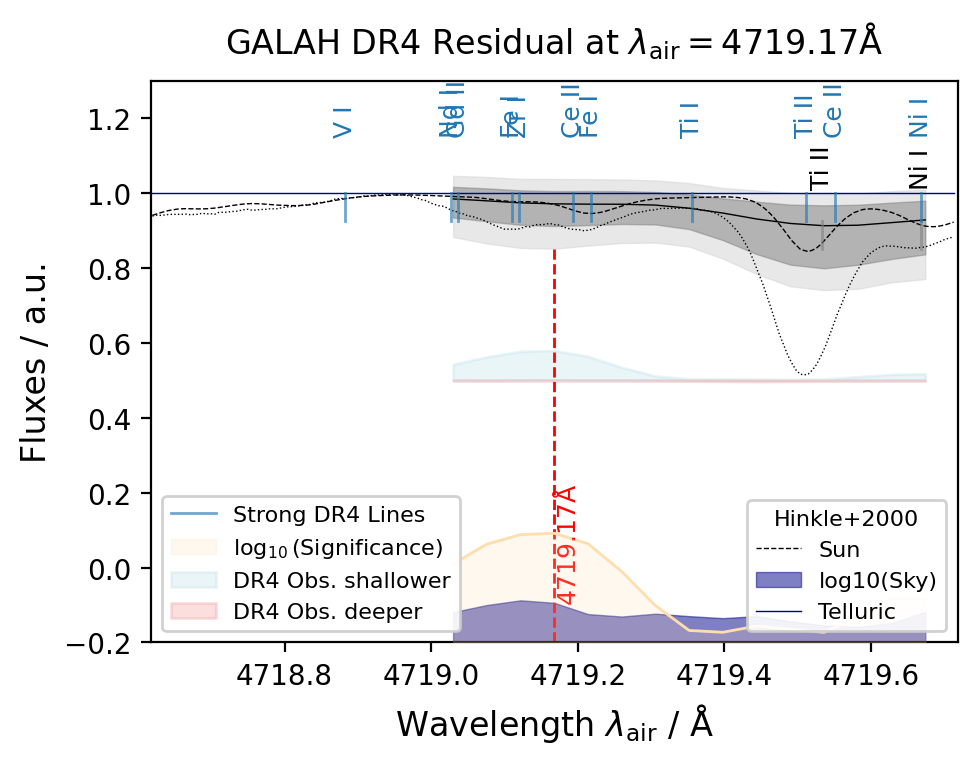

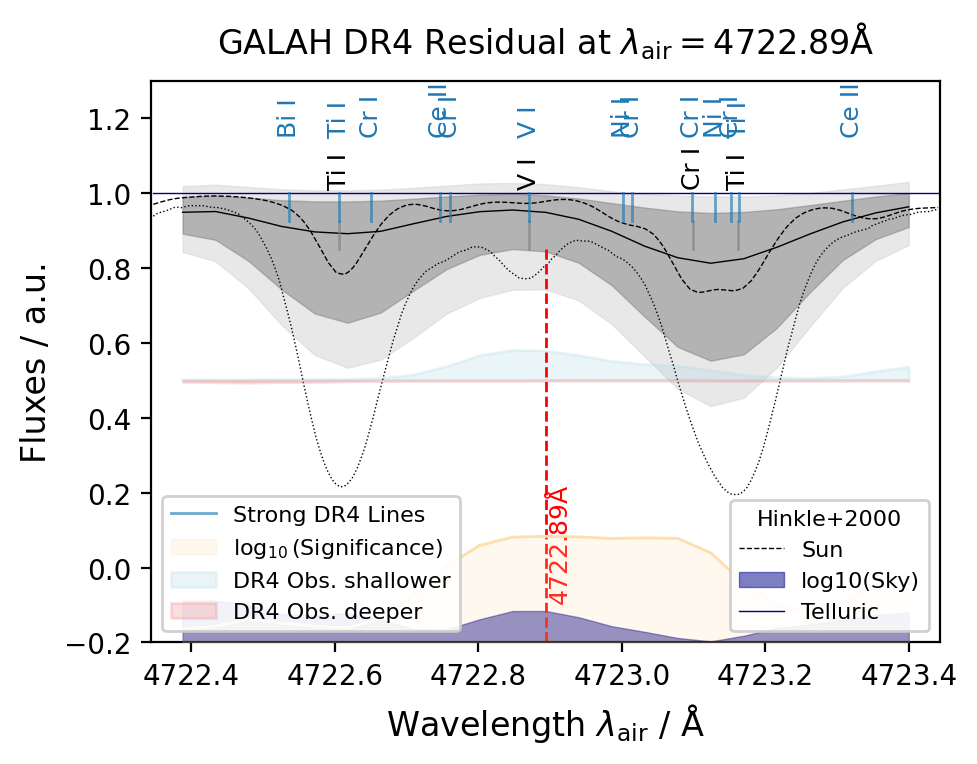

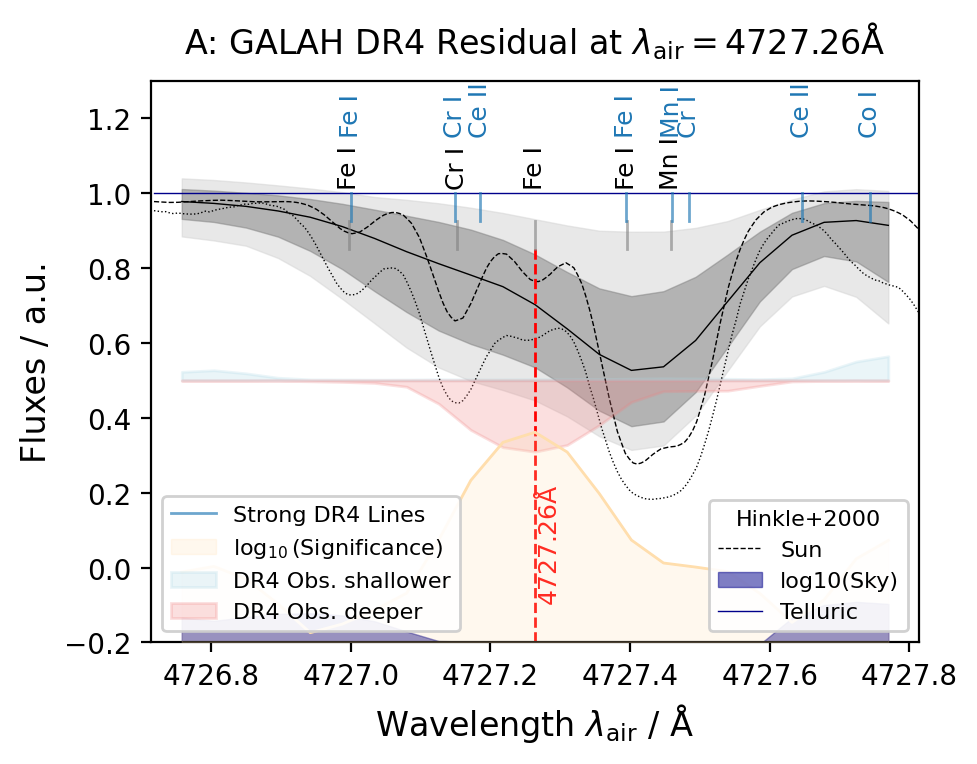

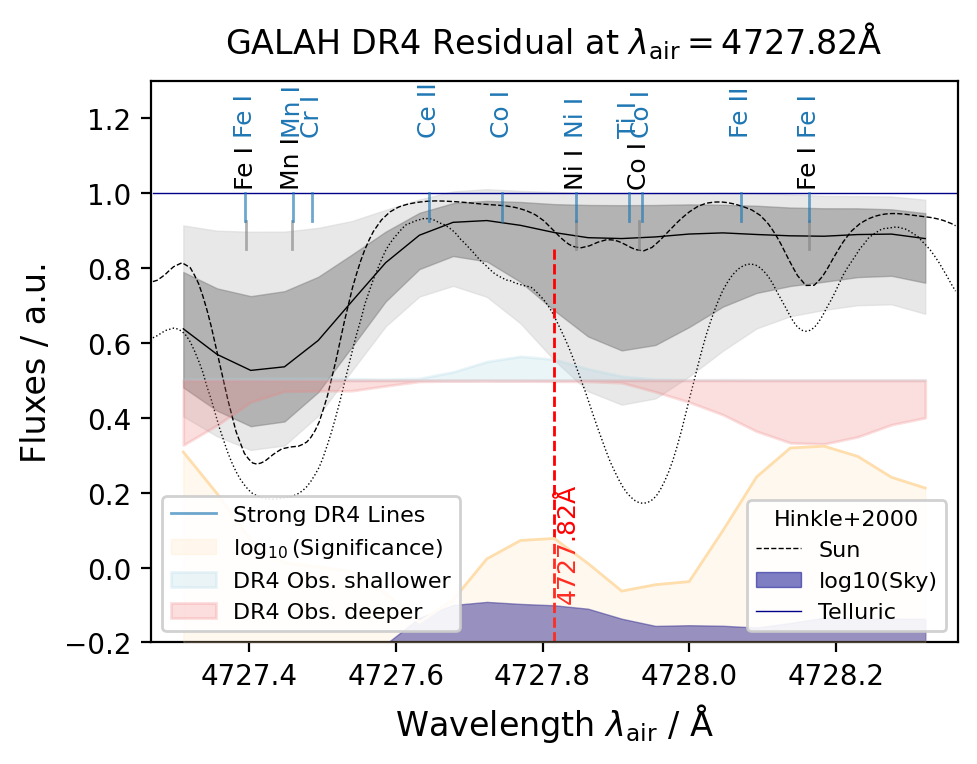

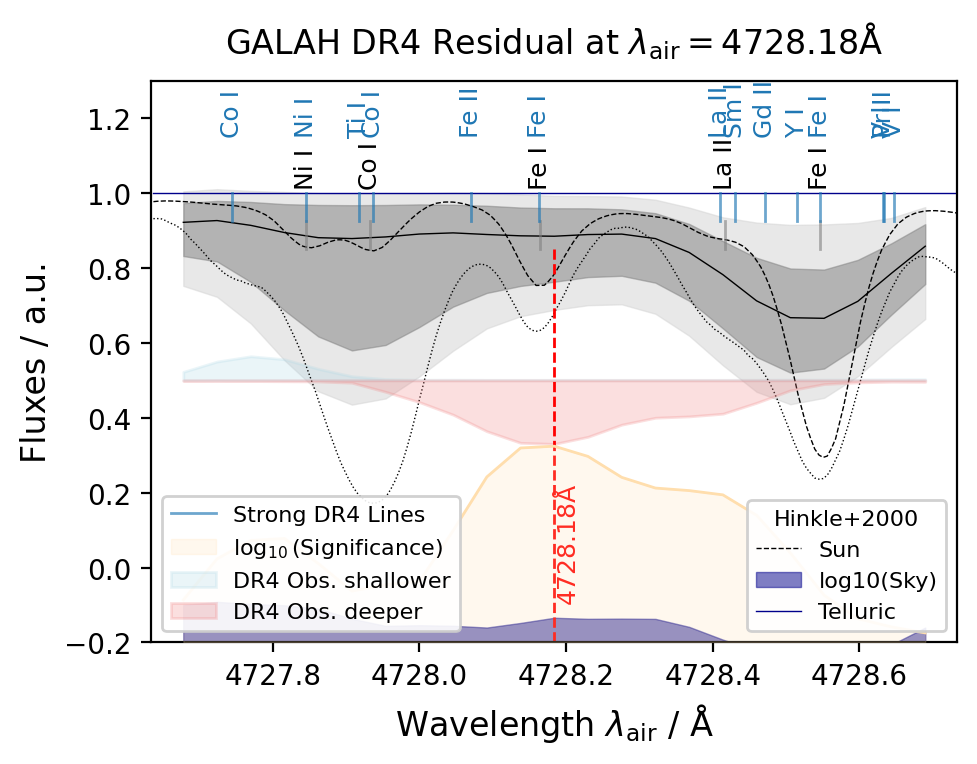

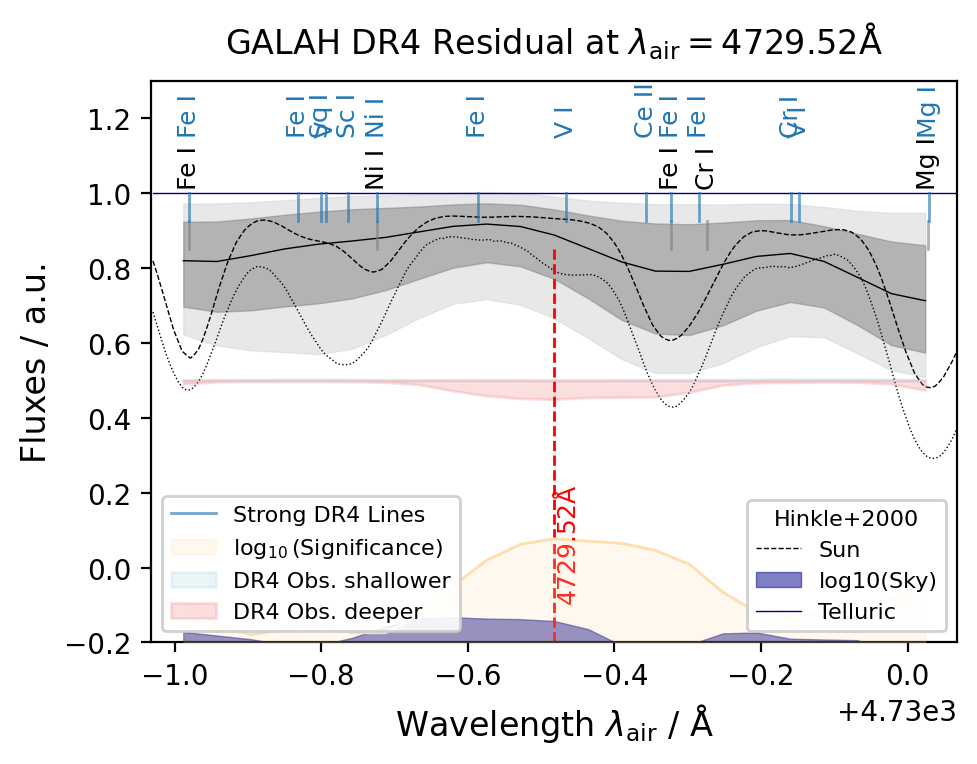

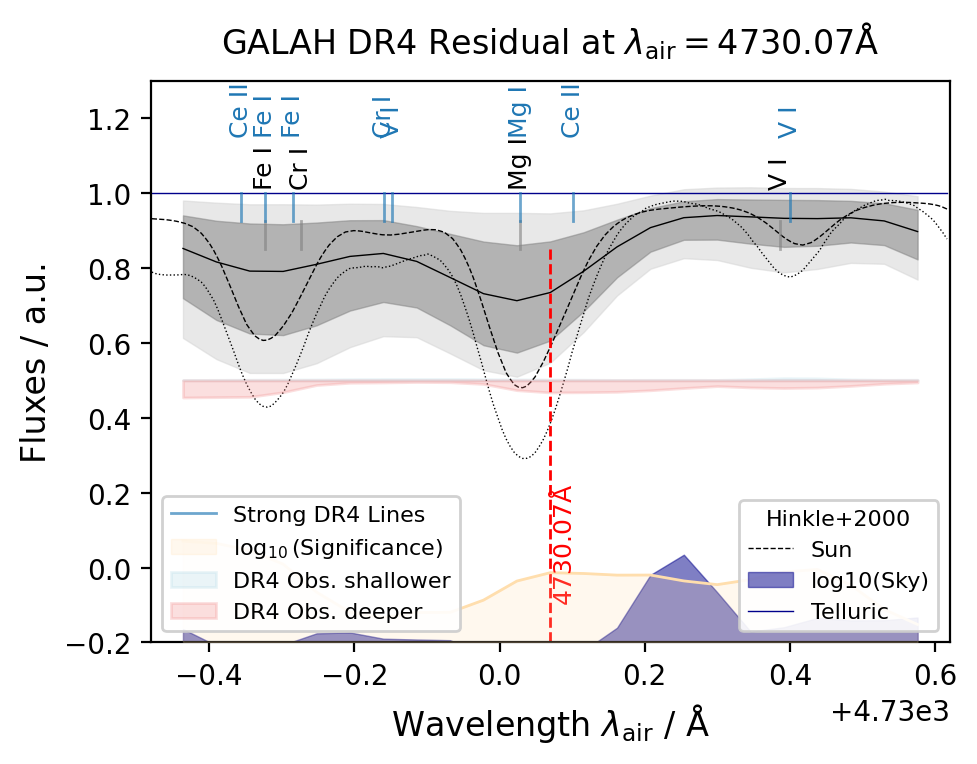

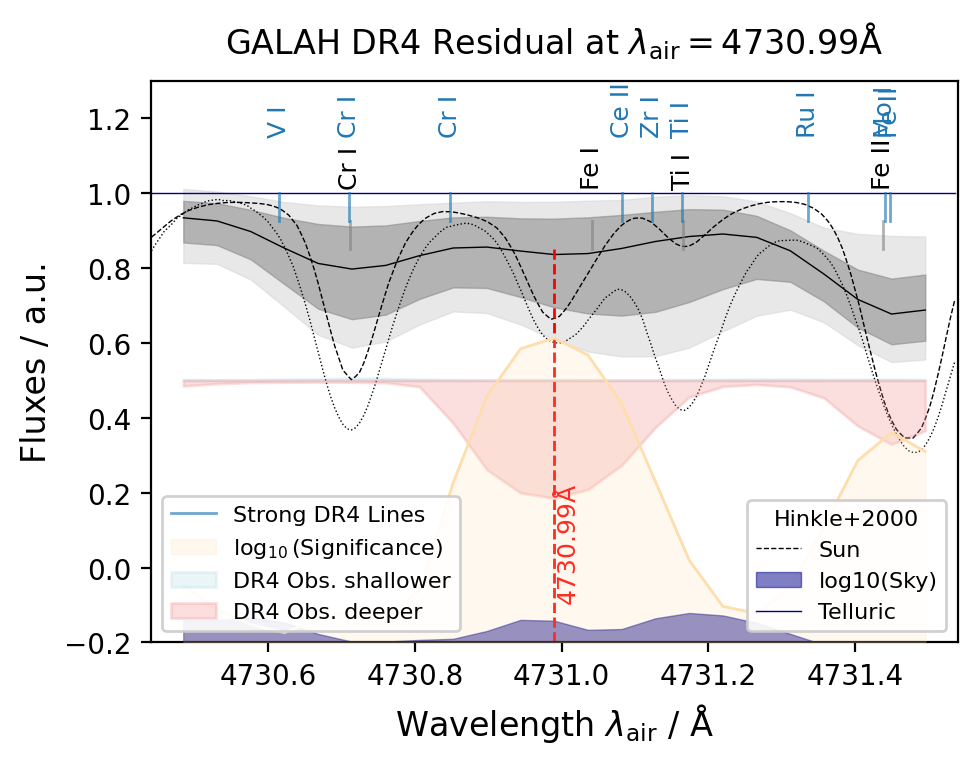

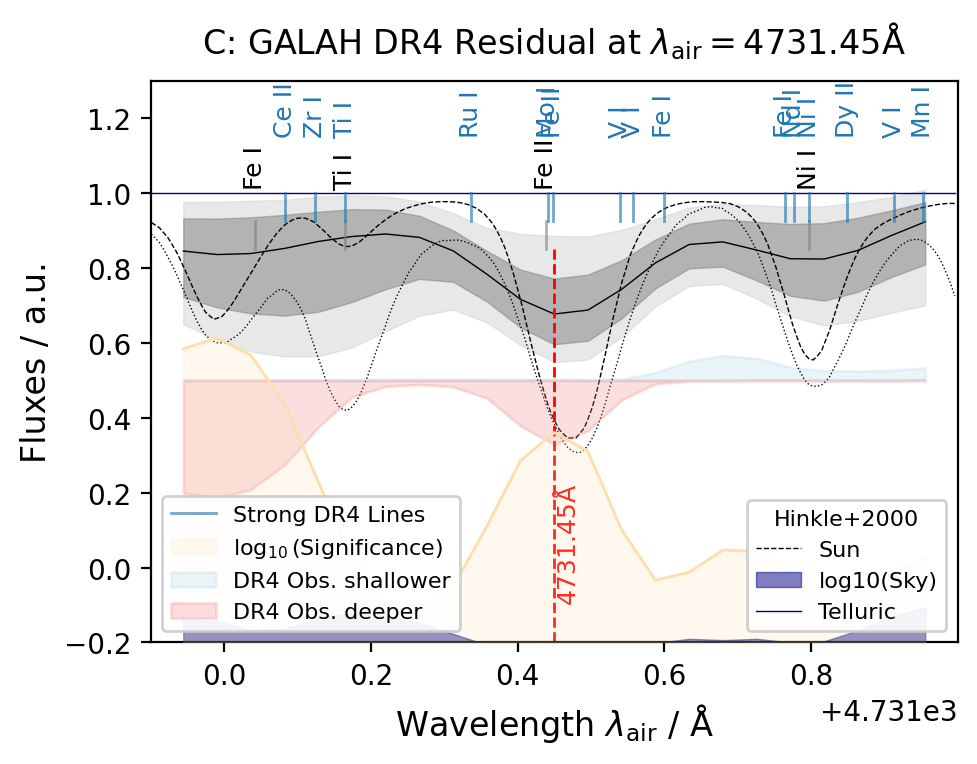

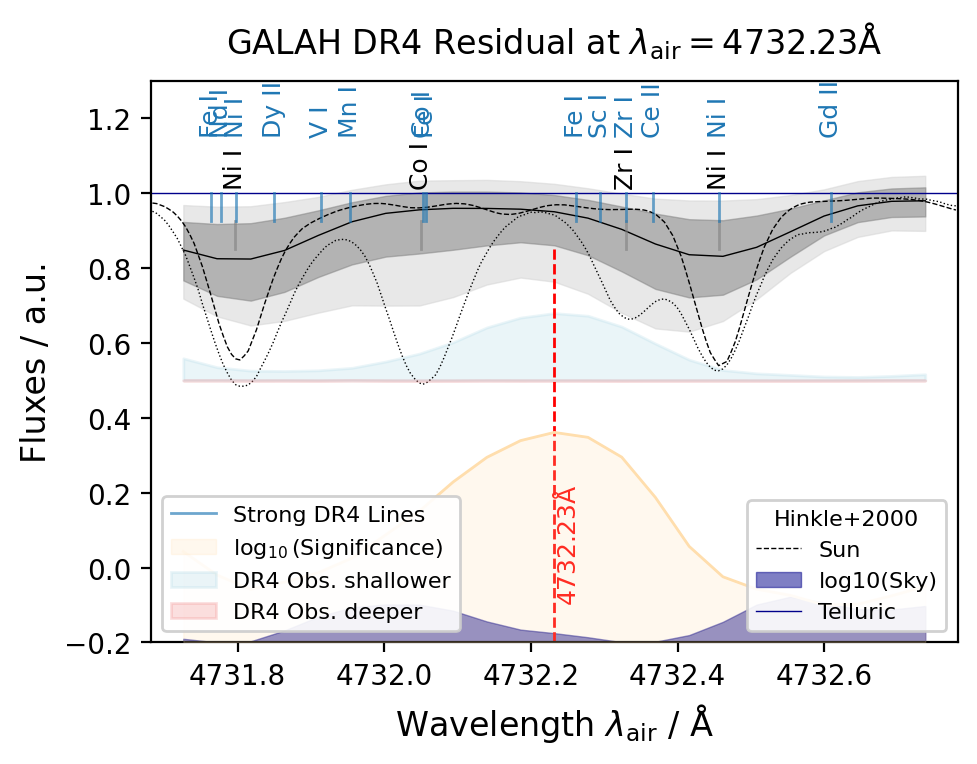

KeyboardInterrupt: 

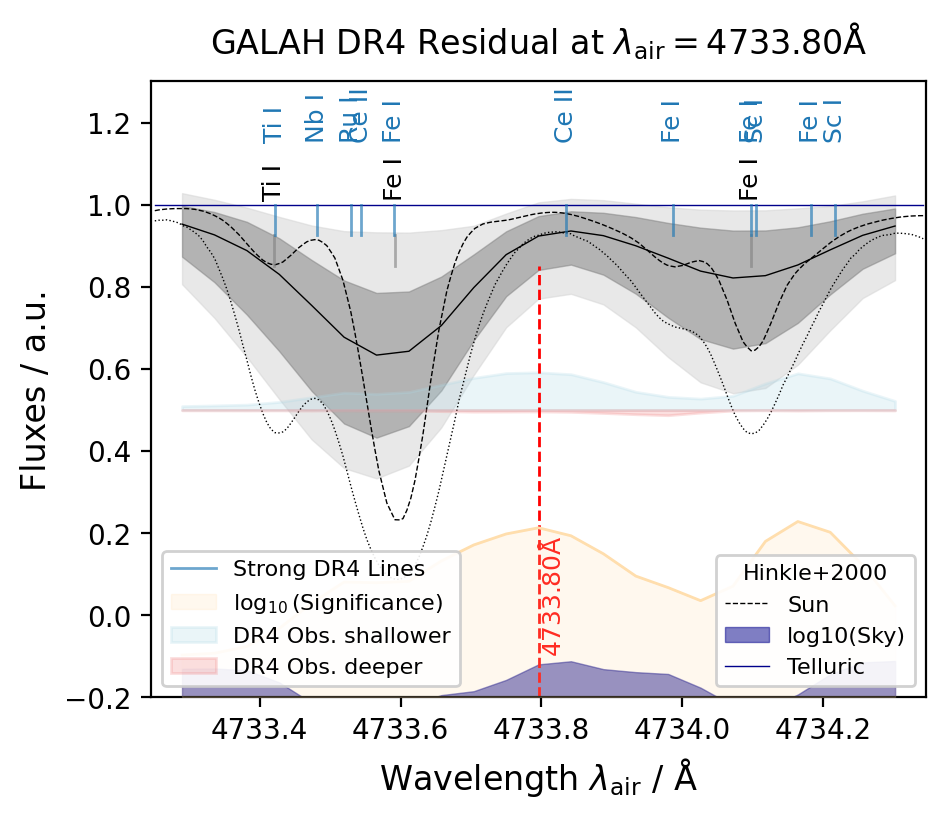

In [120]:
# Create figures for inspecting Hinkle+2000 atlases of Sun and Arcuturus + significant line.

def set_line_window_ticks(ax, lambda0):
    candidate_offsets = [
        np.array([-0.4, -0.2, 0.0, 0.2, 0.4]),
        np.array([-0.3, -0.1, 0.1, 0.3, 0.5]),
        np.array([-0.2, 0.0, 0.2, 0.4, 0.6]),
    ]

    xmin, xmax = ax.get_xlim()

    for offsets in candidate_offsets:
        ticks = lambda0 + offsets
        if np.all((ticks > xmin) & (ticks < xmax)):
            ax.set_xticks(ticks)
            return ticks

for peak_index, significant_peak in enumerate(significant_peaks_table):

    # if "{:.2f}".format(significant_peak['wave']) in ['4727.26','7799.96','4731.45','4861.49','5780.85','7853.25']:

    window = 1.1

    hinkle_region = (hinkle_spectra['WAVELENGTH'] > significant_peak['wave']-window/2.0) & (hinkle_spectra['WAVELENGTH'] < significant_peak['wave']+window/2.0)
    hinkle_lines_in_region = (hinkle_lines_table['wave_air'] > significant_peak['wave']-window/2.1) & (hinkle_lines_table['wave_air'] < significant_peak['wave']+window/2.1)
    residual_region = (common_wavelength > significant_peak['wave']-window/2.0) & (common_wavelength < significant_peak['wave']+window/2.0)
    dr4_linelist_in_region = (galah_dr4_linelist['LAMBDA'] > significant_peak['wave']-window/2.1) & (galah_dr4_linelist['LAMBDA'] < significant_peak['wave']+window/2.1) & (galah_dr4_linelist['DEPTH'] > 0.85)

    f, ax = plt.subplots(figsize=(5,4))

    dr4_5_95 = ax.fill_between(
        common_wavelength[residual_region],
        flux_percentiles[0][residual_region],
        flux_percentiles[4][residual_region],
        color = 'lightgrey',
        lw = 0.5,
        alpha = 0.5,
        label = 'DR4 Obs. 5th-95th Perc.'
    )
    dr4_16_84 = ax.fill_between(
        common_wavelength[residual_region],
        flux_percentiles[1][residual_region],
        flux_percentiles[3][residual_region],
        color = 'grey',
        lw = 0.5,
        alpha = 0.5,
        label = 'DR4 Obs. 16th-84th Perc.'
    )
    dr4_50, = ax.plot(
        common_wavelength[residual_region],
        flux_percentiles[2][residual_region],
        c = 'k',
        lw = 0.5,
        label = 'DR4 Obs. Median'
    )

    l3, = ax.plot(
        hinkle_spectra['WAVELENGTH'][hinkle_region],
        hinkle_spectra['SOLARFLUX'][hinkle_region],
        c = 'k',
        ls = 'dashed',
        lw = 0.5,
        label = 'Sun'
    )
    l4, = ax.plot(
        hinkle_spectra['WAVELENGTH'][hinkle_region],
        hinkle_spectra['ARCTURUS'][hinkle_region],
        c = 'k',
        ls = 'dotted',
        lw = 0.5,
        label = 'Arcturus'
    )
    l5, = ax.plot(
        hinkle_spectra['WAVELENGTH'][hinkle_region],
        hinkle_spectra['TELLURIC'][hinkle_region],
        c = 'darkblue',
        lw = 0.5,
        label = 'Telluric'
    )

    l1 = ax.fill_between(
        common_wavelength[residual_region],
        -0.2*np.ones(len(common_wavelength[residual_region])),
        np.log10(significance_residual_flux_percentiles[1][residual_region]),
        color = 'navajowhite',
        lw = 0.5,
        alpha = 0.2,
        label = r'$\log_{10}(\mathrm{Significance})$',
        zorder = 4
    )
    ax.plot(
        common_wavelength[residual_region],
        np.log10(significance_residual_flux_percentiles[1][residual_region]),
        c = 'navajowhite',
        lw = 1,
        label = '_nolegend_',
        zorder = 3
    )

    l21 = ax.fill_between(
        common_wavelength[residual_region],
        0.5 + np.zeros_like(common_wavelength[residual_region]),
        0.5 + percentage_above_significance[residual_region] / 200.,
        color = 'lightblue',
        lw = 1,
        alpha = 0.25,
        zorder = 1,
        label = 'DR4 Obs. shallower'
    )
    l22 = ax.fill_between(
        common_wavelength[residual_region],
        0.5 + np.zeros_like(common_wavelength[residual_region]),
        0.5 - percentage_below_significance[residual_region] / 200.,
        color = 'lightcoral',
        lw = 1,
        alpha = 0.25,
        zorder = 2,
        label = 'DR4 Obs. deeper'
    )

    l4 = ax.fill_between(
        common_wavelength[residual_region],
        -0.2 + np.zeros_like(common_wavelength[residual_region]),
        -0.2 + np.log10(reduction_sky_tellurics['sky'][residual_region]),
        color = 'darkblue',
        lw = 0.5,
        alpha = 0.5,
        label = 'log10(Sky)'
    )

    l2 = ax.axvline(significant_peak['wave'], color='red', lw=1, ls='--', ymin = 0.0, ymax=0.7, label = 'Significant Peak\nat '+r'$\lambda_\mathrm{air}=$'+"{:.2f}".format(significant_peak['wave'])+r'$\mathrm{\AA}$')
    ax.text(significant_peak['wave'], -0.1, "{:.2f}".format(significant_peak['wave'])+r'$\mathrm{\AA}$', rotation=90, va='bottom', ha='left', fontsize=9, color='red')

    for hinkle_line in hinkle_lines_table[hinkle_lines_in_region]:
        ax.axvline(hinkle_line['wave_air'], color='grey', lw=1, alpha=0.6, ymin=0.7, ymax=0.75)
        ax.text(hinkle_line['wave_air'], 1.01, hinkle_line['species'], rotation=90, va='bottom', ha='center', fontsize=9, color='k')

    first_line = True
    for galah_line in galah_dr4_linelist[dr4_linelist_in_region]:
        name = str(galah_line['NAME'][0]).replace(' ','')
        ion = galah_line['ION']
        if ion == 1:
            name += ' I'
        elif ion == 2:
            name += ' II'

        if first_line:
            label = 'Strong DR4 Lines'
            l0 = ax.axvline(galah_line['LAMBDA'], color='C0', lw=1, alpha=0.65, ymin=0.75, ymax=0.8, label = label)
            first_line = False
        else:
            label = '_nolegend_'
            ax.axvline(galah_line['LAMBDA'], color='C0', lw=1, alpha=0.65, ymin=0.75, ymax=0.8, label = label)
        
        ax.text(galah_line['LAMBDA'], 1.15, name, rotation=90, va='bottom', ha='center', fontsize=9, color='C0')

    leg1 = ax.legend(handles = [l0, l1, l21, l22], ncol=1, fontsize=8, loc='lower left', framealpha=0.9)
    ax.add_artist(leg1)
    leg2 = ax.legend(handles = [l3,l4, l5], ncol=1, fontsize=8, loc='lower right', framealpha=0.9)
    leg2.set_title('Hinkle+2000', prop={'size': 8})
    
    ax.set_xlabel(r'Wavelength $\lambda_\mathrm{air}~/~\mathrm{\AA}$', fontsize=12)
    ax.set_ylabel('Fluxes / a.u.', fontsize=12)
    ax.set_xlim(significant_peak['wave']-window/2.0, significant_peak['wave']+window/2.0)
    ax.set_ylim(-0.2,1.3)

    letter = ''
    if "{:.2f}".format(significant_peak['wave']) == '4727.26':
        letter = 'A: '
    if "{:.2f}".format(significant_peak['wave']) == '7799.96':
        letter = 'B: '
    if "{:.2f}".format(significant_peak['wave']) == '4731.45':
        letter = 'C: '
    if "{:.2f}".format(significant_peak['wave']) == '4861.49':
        letter = 'D: '
    if "{:.2f}".format(significant_peak['wave']) == '5780.85':
        letter = 'E: '
    if "{:.2f}".format(significant_peak['wave']) == '7853.25':
        letter = 'F: '

    ax.set_title(letter+'GALAH DR4 Residual at '+r'$\lambda_\mathrm{air}=$'+"{:.2f}".format(significant_peak['wave'])+r'$\mathrm{\AA}$', fontsize=12, pad=10)
    
    plt.tight_layout()
    plt.savefig('residual_inspection/residual_region_'+"{:.2f}".format(significant_peak['wave'])+'.pdf', dpi=300, bbox_inches='tight')
    # if peak_index < 2:  # Show the first few
    plt.show()
plt.close()

In [121]:
# Match residuals with sky lines from DR4 observation

reduction_sky_tellurics = Table.read('data/reduction_sky_tellurics.fits')

sky_line_peaks, sky_line_peaks_strength = find_peaks(reduction_sky_tellurics['sky'], height = 2)
sky_line_wave = reduction_sky_tellurics['wave'][sky_line_peaks]
sky_lines = Table()
sky_lines['wave'] = np.round(sky_line_wave, 3)
sky_lines['strength'] = np.round(sky_line_peaks_strength['peak_heights'],1)

In [122]:
# Interstellar features - based on Vogroncic et al. (2023,https://ui.adsabs.harvard.edu/abs/2023MNRAS.521.3727V)
# DIB catalogue with EW[@E(B-V)=0] >= 0.01AA or EW/E(B-V) > 0.025AA & including KI interstellar line at 7698.9643AA

vogroncic_dib_lines = np.array([
    4726.40, 4728.28,
    4762.57, # <- strong
    4848.77,4855.25,
    4859.89,4866.65,
    5705.21, # <- strong
    5735.22,5741.28,
    5747.62, # <- strong
    5753.17,
    5776.03,
    5780.59, # <- strong
    5784.78, # <- strong
    5797.19, # <- strong
    5809.42,
    5843.54,
    5849.91,
    6493.11, # <- strong
    6496.67, # <- strong
    6516.33,
    6526.11,
    6530.17, # <- strong
    6535.89,
    6570.83,
    6589.97, # <- strong
    6592.53,
    6613.66, # <- strong
    6699.33,
    7698.9643
    ])

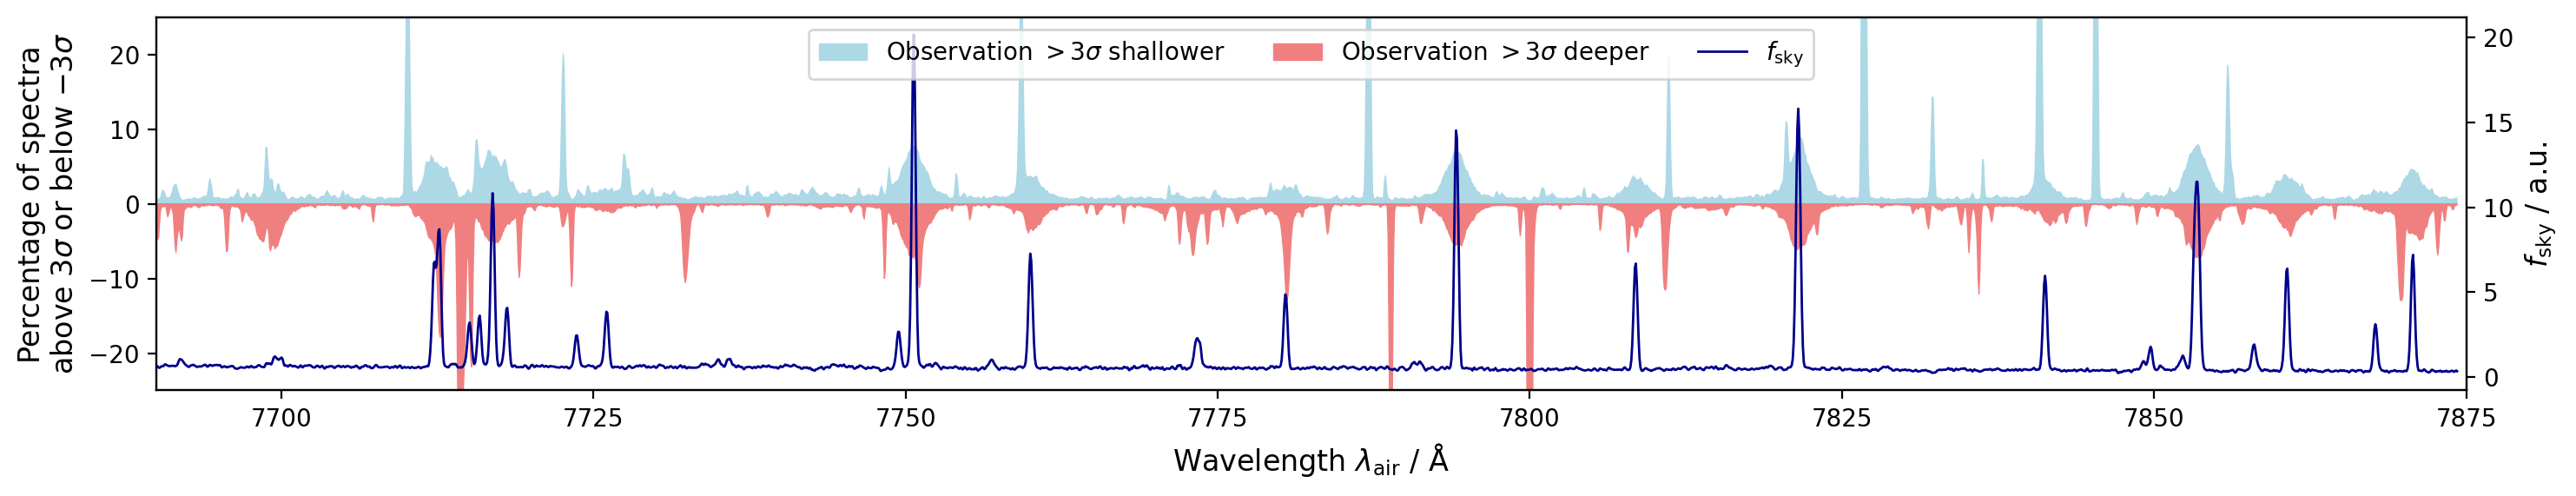

In [123]:
f, ax = plt.subplots(figsize=(15,3))
l1 = ax.fill_between(
    common_wavelength,
    percentage_above_significance,
    np.zeros_like(common_wavelength),
    color = 'lightblue',
    lw = 0.5, label = r'Observation $> 3\sigma$ shallower'
)
l2 = ax.fill_between(
    common_wavelength,
    np.zeros_like(common_wavelength),
    -percentage_below_significance,
    color = 'lightcoral',
    lw = 0.5, label = r'Observation $> 3\sigma$ deeper'
)

ax2 = ax.twinx()
l3, = ax2.plot(
    common_wavelength,
    reduction_sky_tellurics['sky'],
    #np.log10(reduction_sky_tellurics['sky']),
    c = 'darkblue',
    lw = 1,
    label = r'$f_\mathrm{sky}$'
)

ax2.legend(handles = [l1, l2, l3], ncol=3, fontsize=10, loc='upper center')
ax.set_xlim(7690,7875)
ax.set_ylim(-25,25)
ax.set_xlabel(r'Wavelength $\lambda_\mathrm{air}~/~\mathrm{\AA}$', fontsize=12)
ax.set_ylabel('Percentage of spectra\n'+r'above $3\sigma$ or below $-3\sigma$', fontsize=12)
ax2.set_ylabel(r'$f_\mathrm{sky}$ / a.u.', fontsize=12)
plt.tight_layout()
plt.savefig('figures/skyline_confirmation.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
peak_inspection = dict()

# Which peaks are Hbeta and Halpha?
hbeta_index = np.argmin(np.abs(np.array(significant_peaks_table['wave'], dtype=float) - 4861.3230))
halpha_index = np.argmin(np.abs(np.array(significant_peaks_table['wave'], dtype=float) - 6562.7970))

for peak_index, significant_peak in enumerate(significant_peaks_table):

    # within +-1 pixel, find the closest line in Hinkle+ 2000
    if (significant_peak['wave'] > 4719.0299) & (significant_peak['wave'] < 4893.8808):
        pixelscale = 0.0460
    elif (significant_peak['wave'] > 5655.5298) & (significant_peak['wave'] < 5863.0182):
        pixelscale = 0.0547
    elif (significant_peak['wave'] > 6486.0104) & (significant_peak['wave'] < 6726.4572):
        pixelscale = 0.0631
    elif (significant_peak['wave'] > 7689.1261) & (significant_peak['wave'] < 7874.3127):
        pixelscale = 0.0735
    allowed_pixel_distance = 1. * pixelscale

    # Column 1: Peak index
    peak_inspection.setdefault('peak_index', []).append(peak_index)

    # Column 2: Wavelength of the residual
    peak_inspection.setdefault('peak_wave_air', []).append("{:.2f}".format(significant_peak['wave']))

    # Column 3: Significance of the residual at that wavelength
    peak_inspection.setdefault('significance', []).append(np.round(significant_peak['significance'],1))

    # Column 4: Peak Classification (placeholder for later)
    peak_inspection.setdefault('classification', []).append('Not Yet Classified')

    # Column 5: Percentage of spectra with observation being more than 3 sigma shallower at that wavelength
    percentage_shallower = percentage_above_significance[np.where(common_wavelength == significant_peak['wave'])[0][0]]
    peak_inspection.setdefault('percent_shallower', []).append(int(np.round(percentage_shallower)))

    # Column 7: Percentage of spectra with observation being more than 3 sigma deeper at that wavelength
    percentage_deeper = percentage_below_significance[np.where(common_wavelength == significant_peak['wave'])[0][0]]
    peak_inspection.setdefault('percent_deeper', []).append(int(np.round(percentage_deeper)))

    # Columns 8-11: Is there a Hinkle+2000 line within allowed_pixel_distance of the peak?
    nearby_hinkle_lines = hinkle_lines_table[np.abs(hinkle_lines_table['wave_air'] - significant_peak['wave']) < allowed_pixel_distance]

    # Fix identification of Balmer lines in Hinkle+2000
    if peak_index == hbeta_index:
        nearby_hinkle_lines = hinkle_lines_table[[3]]
    if peak_index == halpha_index:
        nearby_hinkle_lines = hinkle_lines_table[[4]]

    if len(nearby_hinkle_lines) > 0:
        closest_hinkle_line = nearby_hinkle_lines[np.argmin(np.abs(nearby_hinkle_lines['wave_air'] - significant_peak['wave']))]
        peak_inspection.setdefault('hinkle_species', []).append(closest_hinkle_line['species'])
        peak_inspection.setdefault('hinkle_wave_air', []).append(closest_hinkle_line['wave_air'])
        peak_inspection.setdefault('hinkle_distance', []).append(np.round(np.abs(closest_hinkle_line['wave_air'] - significant_peak['wave']),2))
    else:
        peak_inspection.setdefault('hinkle_species', []).append('None')
        peak_inspection.setdefault('hinkle_wave_air', []).append(np.nan)
        peak_inspection.setdefault('hinkle_distance', []).append(np.nan)

    # Columns 12-16: Is there a GALAH DR4 line within allowed_pixel_distance of the peak, and if so: what is the loggf?
    nearby_dr4_lines = galah_dr4_linelist[(np.abs(galah_dr4_linelist['LAMBDA'] - significant_peak['wave']) < allowed_pixel_distance) & (galah_dr4_linelist['DEPTH'] > 0.1)]
    # Fix identification of Balmer lines in DR4 linelist
    if peak_index == hbeta_index:
        nearby_dr4_lines = galah_dr4_linelist[(galah_dr4_linelist['NAME'][:,0] == 'H ') & (np.abs(galah_dr4_linelist['LAMBDA'] - 4861.3230) < allowed_pixel_distance)]
    if peak_index == halpha_index:
        nearby_dr4_lines = galah_dr4_linelist[(galah_dr4_linelist['NAME'][:,0] == 'H ') & (np.abs(galah_dr4_linelist['LAMBDA'] - 6562.7970) < allowed_pixel_distance)]

    if len(nearby_dr4_lines) > 0:
        closest_dr4_line = nearby_dr4_lines[np.argmin(np.abs(nearby_dr4_lines['LAMBDA'] - significant_peak['wave']))]
        peak_inspection.setdefault('dr4_line_name', []).append(closest_dr4_line['NAME'][0].replace(' ','')+(' I' if closest_dr4_line['ION'] == 1 else ' II' if closest_dr4_line['ION'] == 2 else ''))
        peak_inspection.setdefault('dr4_wave_air', []).append(closest_dr4_line['LAMBDA'])
        peak_inspection.setdefault('dr4_distance', []).append(np.round(np.abs(closest_dr4_line['LAMBDA'] - significant_peak['wave']),2))
        peak_inspection.setdefault('dr4_log_gf_ref', []).append(closest_dr4_line['LOG_GF_REF'].replace(' ',''))
        peak_inspection.setdefault('dr4_log_gf', []).append(closest_dr4_line['LOG_GF'])
        peak_inspection.setdefault('dr4_depth', []).append(closest_dr4_line['DEPTH'])
    else:
        peak_inspection.setdefault('dr4_line_name', []).append('None')
        peak_inspection.setdefault('dr4_wave_air', []).append(np.nan)
        peak_inspection.setdefault('dr4_distance', []).append(np.nan)
        peak_inspection.setdefault('dr4_log_gf_ref', []).append('--')
        peak_inspection.setdefault('dr4_log_gf', []).append(np.nan)
        peak_inspection.setdefault('dr4_depth', []).append(np.nan)

    # Column 18: Width
    peak_inspection.setdefault('width', []).append(np.round(significant_peak['widths'],1))

    # Column 19-20: Skyline within 1Å?
    nearby_skyline = sky_lines[np.abs(sky_lines['wave'] - significant_peak['wave']) < 1.0]
    if len(nearby_skyline) > 0:
        closest_skyline = nearby_skyline[np.argmin(np.abs(nearby_skyline['wave'] - significant_peak['wave']))]
        peak_inspection.setdefault('skyline_wave', []).append(closest_skyline['wave'])
        peak_inspection.setdefault('skyline_strength', []).append(closest_skyline['strength'])
        peak_inspection.setdefault('skyline_distance', []).append(np.round(np.abs(closest_skyline['wave'] - significant_peak['wave']),2))
    else:
        peak_inspection.setdefault('skyline_wave', []).append(np.nan)
        peak_inspection.setdefault('skyline_strength', []).append(np.nan)
        peak_inspection.setdefault('skyline_distance', []).append(np.nan)

peak_inspection = Table(peak_inspection)
# Column 21: Classification comments?
peak_inspection['comments'] = np.full(len(peak_inspection), '', dtype='U200')

"""
THIS IS WHERE WE CLASSIFY AUTOMATICALLY
"""
automatically_classified_peaks = 0

for peak_index, row in enumerate(peak_inspection):

    # Classification 1: Interstellar features - based on Vogroncic+2023 DIB catalogue with EW[@E(B-V)=0] >= 0.01AA or EW/E(B-V) > 0.025AA with Q+ & including KI interstellar line at 7698.9643AA
    # if  :
    check_nearby_ism = np.where(np.abs(vogroncic_dib_lines - float(row['peak_wave_air'])) < 0.5)[0]
    if (len(check_nearby_ism) > 0) & (row['width'] > 6):
        if peak_inspection['classification'][peak_index] == 'Not Yet Classified':
            automatically_classified_peaks += 1
        peak_inspection['classification'][peak_index] = 'Interstellar'
            # print('#',row['peak_wave_air'],', with width ', row['width'], 'Deeper ', row['percent_deeper'], 'Shallower', row['percent_shallower'], ' ISM feature at ', vogroncic_dib_lines[check_nearby_ism[0]], ' (Vogroncic+2023 DIB catalogue or KI interstellar line)')
        # else:
        #     print('# NO',row['peak_wave_air'],', with width ', row['width'], 'Deeper ', row['percent_deeper'], 'Shallower', row['percent_shallower'], ' ISM feature at ', vogroncic_dib_lines[check_nearby_ism[0]], ' (Vogroncic+2023 DIB catalogue or KI interstellar line)')
        # peak_inspection['comments'][peak_index] += 'ISM feature ('+str(vogroncic_dib_lines[check_nearby_ism[0]])+' with width ' + "{:.0f}".format(row['width']) + 'px) within 0.05 AA.'

    # Classification 2: Overwrite skylines
    elif (
        ((abs(row['skyline_distance']) < 0.5) | (row['peak_wave_air'] in ['7711.76','7712.72'])) & 
        (row['peak_wave_air'] not in ['6498.95','6522.10','6533.40','6577.63','6596.50','7723.23','7751.09','7780.56','7840.83'])
        ):
        if peak_inspection['classification'][peak_index] == 'Not Yet Classified':
            automatically_classified_peaks += 1
        peak_inspection['classification'][peak_index] = 'Skyline'

    # Classification 3: Ensure that the residuals are actually significant often enough:
    elif (row['percent_shallower'] + row['percent_deeper'] < 5) | (row['peak_wave_air'] in ['5709.46']):
        peak_inspection['classification'][peak_index] = 'Insignificant'
        automatically_classified_peaks += 1
        peak_inspection['comments'][peak_index] = 'Shallower in '+str(row['percent_shallower'])+'%; Deeper in '+str(row['percent_deeper'])+'%. Finetuning closest '+str(row['dr4_line_name'])+' ('+str(row['dr4_wave_air'])+'AA, loggf '+"{:.2f}".format(row['dr4_log_gf'])+', depth '+"{:.2f}".format(row['dr4_depth'])+')?'
        # print('#', row['peak_wave_air'], ', # Insignificant, ',row['percent_deeper'], row['percent_shallower'], row['hinkle_wave_air'], row['hinkle_species'], row['dr4_line_name'], row['dr4_wave_air'], np.round(row['dr4_depth'], 2), np.round(row['dr4_log_gf'], 2), row['dr4_log_gf_ref'])

    # Classification 4&5: "too low loggf" and "too high loggf" - based on consistently identified lines in Hinkle+2000 and GALAH DR4
    elif row['hinkle_species'] == row['dr4_line_name'] != 'None':

        # print(row['peak_index'], row['peak_wave_air'], row['percent_deeper'], row['percent_shallower'], row['hinkle_wave_air'], row['hinkle_species'], row['dr4_line_name'], row['dr4_wave_air'], np.round(row['dr4_depth'], 2), np.round(row['dr4_log_gf'], 2), row['dr4_log_gf_ref'])
        if row['peak_wave_air'] == '4761.12':
            print('HERE!')

        # Assess if the residuals are overwhelmingly shallower (loggf too high) or deeper (logff too low) than the model
        if row['percent_shallower'] > row['percent_deeper']:
            peak_inspection['classification'][peak_index] = 'loggf too high'
            automatically_classified_peaks += 1
            # print('#',row['peak_wave_air'],', loggf too high for ', row['hinkle_species'], row['percent_shallower'], 'vs.', row['percent_deeper'], '->', row['percent_shallower'] - row['percent_deeper'])
        elif row['percent_deeper'] >= row['percent_shallower']:
            peak_inspection['classification'][peak_index] = 'loggf too low'
            automatically_classified_peaks += 1
            # print('#',row['peak_wave_air'],', loggf too low for ', row['hinkle_species'], row['percent_deeper'], 'vs.', row['percent_shallower'], '->', row['percent_deeper'] - row['percent_shallower'])
        else:
            peak_inspection['comments'][peak_index] += 'Both deeper and shallower'
            # print(row['peak_index'], row['peak_wave_air'], row['percent_deeper'], row['percent_shallower'], row['hinkle_wave_air'], row['hinkle_species'], row['dr4_line_name'], row['dr4_wave_air'], np.round(row['dr4_depth'], 2), np.round(row['dr4_log_gf'], 2), row['dr4_log_gf_ref'])

    # Classification 6: "known missing" - lines in Hinkle+2000 but not in GALAH DR4
    elif row['dr4_line_name'] == 'None' and row['hinkle_species'] != 'None':
        peak_inspection['classification'][peak_index] = 'Known missing'
        automatically_classified_peaks += 1
        peak_inspection['comments'][peak_index] += row['hinkle_species']+' in Hinkle+2000, but not DR4.'
        # print('#',row['peak_wave_air'],', loggf too low for ', row['hinkle_species'], row['percent_deeper'], 'vs.', row['percent_shallower'], '->', row['percent_deeper'] - row['percent_shallower'])
    
    # Classification 7: "Unknown line" - no line in either Hinkle+2000 or GALAH DR4 within 0.05 Å
    elif row['dr4_line_name'] == 'None' and row['hinkle_species'] == 'None':
        peak_inspection['classification'][peak_index] = 'Unknown line'
        automatically_classified_peaks += 1
        peak_inspection['comments'][peak_index] += 'No line in Hinkle+2000 or DR4 within 0.05 AA.'
        
        nearby_lines_list = []
        nearby_dr4_lines = galah_dr4_linelist[np.abs(galah_dr4_linelist['LAMBDA'] - float(row['peak_wave_air'])) < 4*pixelscale]
        for galah_line in nearby_dr4_lines:
            name = str(galah_line['NAME'][0]).replace(' ','')
            ion = galah_line['ION']
            if ion == 1:
                name += ' I'
            elif ion == 2:
                name += ' II'
            nearby_lines_list.append(name + ' at ' + str(galah_line['LAMBDA']) + ' (DEPTH ' + "{:.1f}".format(galah_line['DEPTH']) + ', loggf ' + "{:.1f}".format(galah_line['LOG_GF']) + ', ' + galah_line['LOG_GF_REF'].replace(' ','') + ')')

        # print('#',row['peak_wave_air'],', # Unknown line, Perc. '+"{:.0f}".format(row['percent_deeper'] - row['percent_shallower'])+' '+', '.join(nearby_lines_list))

    # Classification 8: "Mismatch" - different lines in Hinkle+2000 and GALAH DR4 within 0.05 Å
    elif row['dr4_line_name'] != 'None' and row['hinkle_species'] != 'None' and row['dr4_line_name'] != row['hinkle_species']:
        peak_inspection['classification'][peak_index] = 'Mismatch'
        automatically_classified_peaks += 1
        # print("['"+str(row['peak_wave_air'])+"','',''],")
        # print('#',row['peak_wave_air'],', Mismatch: ', row['hinkle_wave_air'], row['hinkle_species'], ' in Hinkle+2000, but '+row['dr4_line_name'], row['dr4_wave_air'], ' with '+"{:.1f}".format(row['dr4_depth'])+' in DR4. Perc. '+"{:.0f}".format(row['percent_deeper'] - row['percent_shallower']))

        if row['percent_deeper'] > row['percent_shallower']:
            # print(row['peak_wave_air'], ': Mismatch, but residuals are deeper -> loggf too low for '+row['hinkle_species']+' in Hinkle+2000? DR4 line '+row['dr4_line_name']+' at '+str(row['dr4_wave_air'])+' with depth '+"{:.1f}".format(row['dr4_depth'])+' and loggf '+"{:.1f}".format(row['dr4_log_gf'])+'.')
            peak_inspection['classification'][peak_index] = 'loggf too low'
            peak_inspection['comments'][peak_index] += str(row['hinkle_wave_air'])+' '+row['hinkle_species']+' too low loggf'
        elif row['percent_shallower'] > row['percent_deeper']:
            # print(row['peak_wave_air'], ': Mismatch, but residuals are shallower -> loggf too high for '+row['hinkle_species']+' in Hinkle+2000?')
            peak_inspection['classification'][peak_index] = 'loggf too high'
            peak_inspection['comments'][peak_index] += str(row['hinkle_wave_air'])+' '+row['hinkle_species']+' in Hinkle+2000, '+str(row['dr4_wave_air'])+' '+row['dr4_line_name']+' in DR4.'
        else:
            pass
            print(row['peak_wave_air'], ': Mismatch, but residuals are equally deeper and shallower -> Unclear if loggf too high or too low for '+row['hinkle_species']+' in Hinkle+2000?') 

        # Clarify mismatch by hand: These could be either missing lines in DR4 linelist or the other way around.
        mismatch_solution = np.array([
            ['5731.73','5731.762 Fe I or Ti I 5731.6928','Insignificant'],
            ['5735.67','Neither 5735.708 Fe I nor 5735.7 Zr I clearly wrong','Unclear'],
            ['5759.51','5759.541 Fe I or Sm II 5759.511','Insignificant'],
            ['5779.64','already DIB 5780, but also 5779.688 Fe I too low loggf','Interstellar'],
            ['6593.91','Off centre from 6593.87 Fe I. Ti I 6593.8791 too weak?','Unclear'],
            ['6643.57','Off centre from 6643.63 Ni I. Sr I 6643.533 too weak?','Unclear'],
        ])
        mismatch_position = np.where(mismatch_solution[:,0] == row['peak_wave_air'])[0]
        if len(mismatch_position) > 0:

            if peak_inspection['classification'][peak_index] != mismatch_solution[mismatch_position[0], 2]:
                # print('Automatic classification overvwritten for '+row['peak_wave_air']+' based on manual inspection: from '+peak_inspection['classification'][peak_index]+' to '+mismatch_solution[mismatch_position[0], 2])
                peak_inspection['classification'][peak_index] = mismatch_solution[mismatch_position[0], 2]
                peak_inspection['comments'][peak_index] = mismatch_solution[mismatch_position[0], 1]
            else:
                pass
                # print('Automatic classification confirmed.')
                # print('Current  comments: '+peak_inspection['comments'][peak_index])
                # print('Expected comments: '+mismatch_solution[mismatch_position[0], 1])

    # Classification 9: lines in GALAH DR4 but not in Hinkle+2000
    elif row['dr4_line_name'] != 'None' and row['hinkle_species'] == 'None':
        peak_inspection['classification'][peak_index] = 'DR4 only'
        automatically_classified_peaks += 1

        # peak_inspection['comments'][peak_index] += row['dr4_line_name']+' in DR4, but not Hinkle+2000.'
        # print('#',row['peak_wave_air'],', # only DR4 line: ', row['dr4_line_name'], row['dr4_wave_air'], ' with '+"{:.1f}".format(row['dr4_depth'])+'. Perc. '+"{:.0f}".format(row['percent_deeper'])+' vs. '+"{:.0f}".format(row['percent_shallower']))
        # print("['"+str(row['peak_wave_air'])+"','"+str(row['dr4_line_name'])+" ("+"{:.2f}".format(row['dr4_wave_air'])+", DEPTH "+("{:.1f}".format(row['dr4_depth']))+") not in Hinkle+2000','loggf too high'],")

        if row['percent_shallower'] > row['percent_deeper']:
            peak_inspection['classification'][peak_index] = 'loggf too high'
            peak_inspection['comments'][peak_index] += str(row['dr4_line_name'])+" ("+"{:.2f}".format(row['dr4_wave_air'])+", DEPTH "+("{:.1f}".format(row['dr4_depth']))+") not in Hinkle+2000"

            # print("['"+str(row['peak_wave_air'])+"','"+str(row['dr4_line_name'])+" ("+"{:.2f}".format(row['dr4_wave_air'])+", DEPTH "+("{:.1f}".format(row['dr4_depth']))+") not in Hinkle+2000','loggf too high'],")

            # print('Reclassified as follows:')
            # print(peak_inspection['peak_wave_air'][peak_index], peak_inspection['comments'][peak_index], peak_inspection['classification'][peak_index])

        elif row['percent_deeper'] >= row['percent_shallower']:
            peak_inspection['classification'][peak_index] = 'loggf too low'
            peak_inspection['comments'][peak_index] += str(row['dr4_line_name'])+" ("+"{:.2f}".format(row['dr4_wave_air'])+", DEPTH "+("{:.1f}".format(row['dr4_depth']))+") not in Hinkle+2000"

            # print("['"+str(row['peak_wave_air'])+"','"+str(row['dr4_line_name'])+" ("+"{:.2f}".format(row['dr4_wave_air'])+", DEPTH "+("{:.1f}".format(row['dr4_depth']))+") not in Hinkle+2000','loggf too low'],")

        dr4_only_lines_to_overwrite = np.array([
            # 4740.47 , # only DR4 line:  Ni I 4740.5008  with 0.4. Perc. 54 vs. 0
            ['4740.47','Ni I (4740.50, DEPTH 0.4) not in Hinkle+2000','Unknown line'],
            # 4740.93 , # only DR4 line:  Co II 4740.918  with 0.1. Perc. 55 vs. 0
            ['4740.93','Co II (4740.92, DEPTH 0.1) not in Hinkle+2000','Unknown line'],
            # 4748.15 , # only DR4 line:  Mn I 4748.176  with 0.5. Perc. 89 vs. 0
            ['4748.15','Mn I (4748.18, DEPTH 0.5), but also blended Cr I not in Hinkle+2000','Unclear'],
            # 4752.20 , # only DR4 line:  W I 4752.203  with 0.4. Perc. 7 vs. 0
            ['4752.20','Ce II (4752.20, DEPTH 0.4) not in Hinkle+2000','loggf too low'],
            # 4754.59 , # only DR4 line:  V I 4754.569  with 0.2. Perc. 18 vs. 0
            ['4754.59','V I (4754.57, DEPTH 0.2) not in Hinkle+2000','loggf too high'],
            # # 4755.74 , # only DR4 line:  U II 4755.735  with 0.3. Perc. 59 vs. 0
            ['4755.74','Two unidentifiable lines in Hinkle+2000, possibly Nd I 4755.843','Unclear'],
            # 4761.12 , # only DR4 line:  Th II 4761.11  with 0.2. Perc. 41 vs. 0
            ['4761.12','Th II (4761.11, DEPTH 0.2) not in Hinkle+2000','Unknown line'],
            # 4762.32 , # only DR4 line:  C I 4762.3027  with 0.2. Perc. 0 vs. 11
            ['4762.32','Ce II (4762.2983, DEPTH 0.9) not in Hinkle+2000','loggf too high'],
            # 4769.91 , # only DR4 line:  Fe I 4769.9056  with 0.2. Perc. 11 vs. 0
            ['4769.91','Fe I (4769.91, DEPTH 0.2) possible.','Unknown line'],
            # 4771.47 , # only DR4 line:  Sc I 4771.4503  with 0.1. Perc. 90 vs. 0
            ['4771.47','Sc I (4771.45, DEPTH 0.1) not in Hinkle+2000, but also blended Cr I','loggf too low'],
            # 4775.84 , # only DR4 line:  Ce II 4775.8208  with 0.9. Perc. 14 vs. 0
            ['4775.84','Ce II (4775.82, DEPTH 0.9) not in Hinkle+2000','Unknown line'],
            # 4789.59 , # only DR4 line:  Fe I 4789.5761  with 0.8. Perc. 0 vs. 36
            ['4789.59','Fe I (4789.58, DEPTH 0.8) and Ni I not in Hinkle+2000','loggf too high'],
            # 4791.16 , # only DR4 line:  Gd II 4791.148  with 0.8. Perc. 46 vs. 0
            ['4791.16','Gd II (4791.15, DEPTH 0.8) or Sc I not in Hinkle+2000','loggf too low'],
            # 4799.85 , # only DR4 line:  Ti I 4799.8549  with 0.9. Perc. 46 vs. 0
            ['4799.85','Ti I (4799.85, DEPTH 0.9) or Cd I or W I not in Hinkle+2000','loggf too low'],
            # 4803.03 , # only DR4 line:  Fe I 4803.0294  with 0.2. Perc. 0 vs. 14
            ['4803.03','V I (4803.3629, DEPTH 0.5) not in Hinkle+2000','loggf too high'],
            # 4831.87 , # only DR4 line:  Ce II 4831.8519  with 0.3. Perc. 8 vs. 0
            ['4831.87','V I (4831.6457, DEPTH 0.3) too the left too shallow','loggf too low'],
            # 4833.89 , # only DR4 line:  Fe II 4833.8574  with 0.7. Perc. 28 vs. 0
            ['4833.89','Mo I (4833.896, DEPTH 0.7) not in Hinkle+2000','Unclear'],
            # 4844.52 , # only DR4 line:  Ce II 4844.5184  with 0.5. Perc. 0 vs. 20
            ['4844.52','Fe I (4844.5078, DEPTH 0.9) not in Hinkle+2000','loggf too high'],
            # 4853.90 , # only DR4 line:  Ce II 4853.9106  with 0.3. Perc. 14 vs. 0
            ['4853.90','Ce II (4853.91, DEPTH 0.3) or Cr I (4853.9168, DEPTH 0.4) not in Hinkle+2000','loggf too low'],
            # 4855.19 , # only DR4 line:  Co I 4855.2235  with 1.0. Perc. 23 vs. 0
            ['4855.19','Cr I (4855.152, DEPTH 0.7) not in Hinkle+2000','loggf too low'],
            # 4858.13 , # only DR4 line:  U II 4858.09  with 0.2. Perc. 21 vs. 0
            ['4858.13','U II (4858.09, DEPTH 0.2) unlikely','Unknown line'],
            # 4859.84 , # only DR4 line:  Y I 4859.8408  with 1.0. Perc. 0 vs. 5
            ['4859.84','Y I (4859.84, DEPTH 1.0) not in Hinkle+2000','Insignificant'],
            # 4873.08 , # only DR4 line:  Ce II 4873.111  with 0.9. Perc. 0 vs. 27
            ['4873.08','Ce II (4873.11, DEPTH 0.9) or Fe I (4873.1202, DEPTH 0.9)','loggf too high'],
            # 4877.87 , # only DR4 line:  Ti I 4877.8479  with 0.4. Perc. 16 vs. 1
            ['4877.87','Pr II (4877.844, DEPTH 0.9) and Fe I (4877.7893, DEPTH 0.9)','loggf too low'],
            # 4890.66 , # only DR4 line:  C I 4890.6534  with 0.4. Perc. 0 vs. 31
            ['4890.66','Nd II (4890.69, DEPTH 1.0) not in Hinkle+2000','loggf too high'],
            # 5671.94 , # only DR4 line:  Cr I 5671.9193  with 0.1. Perc. 0 vs. 13
            ['5671.94','Sc I Hyper-Fine Structure or Fe I (5671.8285, DEPTH 0.9)','Line formation'],
            # 5686.93 , # only DR4 line:  Sc I 5686.8792  with 0.6. Perc. 0 vs. 8
            ['5686.93','Sc I Hyper-Fine Structure or Co I (5686.9846, DEPTH 0.7)','Line formation'],
            # 5702.41 , # only DR4 line:  Ce I 5702.387  with 0.5. Perc. 0 vs. 32
            ['5702.41','Fe I (5702.43, DEPTH 0.5) not in Hinkle+2000','loggf too high'],
            # 5715.21 , # only DR4 line:  Cr I 5715.2508  with 0.7. Perc. 0 vs. 5
            ['5715.21','Likely loggf too high for Ni I (5715.0668), Fe I (5715.0913) or Ti I (5715.1162)','loggf too high'],
            # 5743.38 , # only DR4 line:  Sm II 5743.35  with 0.7. Perc. 13 vs. 0
            ['5743.38','V I (5743.4466, DEPTH 0.9) wavelength off wrt Hinkle+2000','Line formation'],
            # 5760.12 , # only DR4 line:  Ce II 5760.168  with 0.6. Perc. 0 vs. 8
            ['5760.12','C I (5760.1205, DEPTH 0.0) not in Hinkle+2000','loggf too high'],
            # 5785.22 , # only DR4 line:  Tb II 5785.195  with 0.6. Perc. 41 vs. 0
            ['5785.22','Unlikely to be Tb II (5785.19, DEPTH 0.6)','Unknown line'],
            # 5797.91 , # only DR4 line:  Cr I 5797.8673  with 0.8. Perc. 11 vs. 0
            ['5797.91','Si I (5797.8559, DEPTH 0.8) and Cr I (5797.87, DEPTH 0.8)','loggf too low'],
            # 6553.28 , # only DR4 line:  Si I 6553.2885  with 0.3. Perc. 1 vs. 7
            ['6553.28','Si I (6553.29, DEPTH 0.3) not in Hinkle+2000','Unclear'],
            # 6555.80 , # only DR4 line:  Cr I 6555.7831  with 0.6. Perc. 0 vs. 21
            ['6555.80','Cr I (6555.78, DEPTH 0.6) and Ni I (6555.827, DEPTH 0.6) not in Hinkle+2000','loggf too high'],
            # 6558.07 , # only DR4 line:  Ti I 6558.1089  with 0.3. Perc. 3 vs. 2
            ['6558.07','Ti I (6558.11, DEPTH 0.3) not in Hinkle+2000','Insignificant'],
            # 6564.63 , # only DR4 line:  Cr I 6564.6136  with 0.6. Perc. 2 vs. 8
            ['6564.63','Still part of Halpha wing','Insignificant'],
            # 6566.34 , # only DR4 line:  V I 6566.3306  with 0.8. Perc. 0 vs. 6
            ['6566.34','Still part of Halpha wing','Insignificant'],
            # 6568.99 , # only DR4 line:  Cr I 6568.9327  with 0.3. Perc. 0 vs. 5
            ['6568.99','Cr I (6568.93, DEPTH 0.3) not in Hinkle+2000','Insignificant'],
            # 6574.79 , # only DR4 line:  Ta I 6574.834  with 0.3. Perc. 0 vs. 8
            ['6574.79','Telluric feature? Ta I (6574.83, DEPTH 0.3) not likely.','Insignificant'],
            # 6579.97 , # only DR4 line:  Si I 6579.9556  with 0.7. Perc. 0 vs. 33
            ['6579.97','Si I (6579.96, DEPTH 0.7) not in Hinkle+2000','loggf too high'],
            # 6584.45 , # only DR4 line:  Ti I 6584.4202  with 0.8. Perc. 0 vs. 8
            ['6584.45','Ti I (6584.42, DEPTH 0.8) not in Hinkle+2000','loggf too high'],
            # 6595.74 , # only DR4 line:  Cr I 6595.7071  with 0.5. Perc. 0 vs. 12
            ['6595.74','Cr I (6595.71, DEPTH 0.5) not in Hinkle+2000','loggf too high'],
            # 6596.50 , # only DR4 line:  Ti I 6596.5336  with 0.8. Perc. 0 vs. 11
            ['6596.50','Ti I (6596.53, DEPTH 0.8) not in Hinkle+2000','loggf too high'],
            # 6602.49 , # only DR4 line:  V I 6602.5157  with 0.5. Perc. 0 vs. 12
            ['6602.49','V I (6602.52, DEPTH 0.5) not in Hinkle+2000','loggf too high'],
            # 6609.75 , # only DR4 line:  Ce II 6609.726  with 0.5. Perc. 0 vs. 22
            ['6609.75','Ce II (6609.73, DEPTH 0.5) not in Hinkle+2000','loggf too high'],
            # 6618.52 , # only DR4 line:  Ca I 6618.5727  with 0.8. Perc. 0 vs. 20
            ['6618.52','Ca I (6618.57, DEPTH 0.8) not in Hinkle+2000','loggf too high'],
            # 6624.39 , # only DR4 line:  Ce II 6624.4223  with 0.8. Perc. 15 vs. 0
            ['6624.39','Ce II (6624.42, DEPTH 0.8) not in Hinkle+2000','loggf too high'],
            # 6625.52 , # only DR4 line:  Si I 6625.4926  with 0.5. Perc. 0 vs. 6
            ['6625.52','Si I (6625.49, DEPTH 0.5) not in Hinkle+2000','loggf too high'],
            # 6631.96 , # only DR4 line:  Pr II 6631.9448  with 0.2. Perc. 0 vs. 32
            ['6631.96','Pr II (6631.94, DEPTH 0.2) not in Hinkle+2000','loggf too high'],
            # 6635.05 , # only DR4 line:  Co I 6635.0946  with 0.7. Perc. 6 vs. 0
            ['6635.05','Co I (6635.09, DEPTH 0.7) not in Hinkle+2000','Insignificant'],
            # 6642.56 , # only DR4 line:  Ti I 6642.5695  with 0.2. Perc. 7 vs. 0
            ['6642.56','Wavy pattern of CCD3; Ti I (6642.57, DEPTH 0.2) not in Hinkle+2000','Insignificant'],
            # 6645.21 , # only DR4 line:  Co I 6645.2479  with 0.1. Perc. 15 vs. 0
            ['6645.21','Wavy pattern of CCD3; Co I (6645.25, DEPTH 0.1) and Fe I (6645.3649, DEPTH = 0.5) blending into Eu II','Insignificant'],
            # 6656.89 , # only DR4 line:  Pr II 6656.8336  with 0.7. Perc. 10 vs. 0
            ['6656.89','Wavy pattern of CCD3; Pr II (6656.83, DEPTH 0.7) not in Hinkle+2000','Insignificant'],
            # 6659.79 , # only DR4 line:  Ce II 6659.7657  with 0.5. Perc. 11 vs. 0
            ['6659.79','Wavy pattern of CCD3; Ce II (6659.77, DEPTH 0.5) and V I (6659.9068, DEPTH 0.8)','Insignificant'],
            # 6660.55 , # only DR4 line:  Ni I 6660.5768  with 0.7. Perc. 6 vs. 0
            ['6660.55','Ni I (6660.58, DEPTH 0.7) not in Hinkle+2000','Insignificant'],
            # 6704.59 , # only DR4 line:  Ti I 6704.6117  with 0.1. Perc. 0 vs. 7
            ['6704.59','Line formation of FeI (6703.566, DEPTH 0.9) or Ti I (6704.61, DEPTH 0.1)?','Unclear'],
            # 6707.81 , # only DR4 line:  Li I 6707.7635  with 0.9. Perc. 3 vs. 34
            ['6707.81','Li I (6707.76, DEPTH 0.9) not in Hinkle+2000','Line formation'],
            # 6709.07 , # only DR4 line:  Fe I 6709.058  with 0.6. Perc. 0 vs. 10
            ['6709.07','Fe I (6709.06, DEPTH 0.6) not in Hinkle+2000','loggf too high'],
            # 6712.60 , # only DR4 line:  Sm II 6712.598  with 0.3. Perc. 0 vs. 55
            ['6712.60','Sm II (6712.60, DEPTH 0.3) and Fe I (6712.6741, DEPTH 0.9)','loggf too high'],
            # 6724.09 , # only DR4 line:  Fe I 6724.0915  with 0.8. Perc. 0 vs. 50
            ['6724.09','Fe I (6724.09, DEPTH 0.8) not in Hinkle+2000','loggf too high'],
            # 7690.08 , # only DR4 line:  Mg I 7690.123  with 0.1. Perc. 5 vs. 1
            ['7690.08','Mg I (7690.12, DEPTH 0.1) not in Hinkle+2000','Insignificant'],
            # 7710.15 , # only DR4 line:  Ni I 7710.1889  with 0.2. Perc. 0 vs. 34
            ['7710.15','Fe I (7710.0962, DEPTH 0.7) not in Hinkle+2000','loggf too high'],
            # 7732.34 , # only DR4 line:  Ce I 7732.336  with 0.1. Perc. 11 vs. 1
            ['7732.34','Ce I (7732.34, DEPTH 0.1) and Fe I (7732.269, DEPTH 0.2)','loggf too low'],
            # 7807.83 , # only DR4 line:  Fe I 7807.7743  with 0.3. Perc. 6 vs. 2
            ['7807.83','Fe I (7807.77, DEPTH 0.3) not in Hinkle+2000','loggf too low'],
        ])
        match_position = np.where(dr4_only_lines_to_overwrite[:,0] == row['peak_wave_air'])[0]
        if len(match_position) > 0:

            if peak_inspection['classification'][peak_index] == dr4_only_lines_to_overwrite[match_position[0],2]:
                # print('Already classified correctly: ', row['peak_wave_air'], ' with classification: ', peak_inspection['classification'][peak_index])
                if peak_inspection['classification'][peak_index] == 'loggf too low':
                    comment_expecation = dr4_only_lines_to_overwrite[match_position[0],1]
                    comment_actual = peak_inspection['comments'][peak_index]
                    if comment_expecation != comment_actual:
                        pass
                        # print('WARNING: For peak at ', row['peak_wave_air'], ' expected comment: ', comment_expecation, ' but got: ', comment_actual)
                    else:
                        pass
                        # print('Good to remove: ', row['peak_wave_air'], ' with comment: ', comment_actual)
            else:
                peak_inspection['classification'][peak_index] = dr4_only_lines_to_overwrite[match_position[0],2]
                peak_inspection['comments'][peak_index] = dr4_only_lines_to_overwrite[match_position[0],1]
                # print('WARNING: For peak at ', row['peak_wave_air'], ' expected classification: ', dr4_only_lines_to_overwrite[match_position[0],2], ' but got: ', peak_inspection['classification'][peak_index])
            # Compare automatic and by-hand classification and comments
            
                # print(dr4_only_lines_to_overwrite[match_position[0],0], dr4_only_lines_to_overwrite[match_position[0],1], dr4_only_lines_to_overwrite[match_position[0],2])

            # peak_inspection['classification'][peak_index] = dr4_only_lines_to_overwrite[match_position[0], 2]
            # peak_inspection['comments'][peak_index] += dr4_only_lines_to_overwrite[match_position[0], 1]

    # Extra info for weak skylines
    if row['peak_wave_air'] in ['6498.95','6522.10','6533.40','6596.50','7723.23','7751.09','7780.56','7840.83']:
        peak_inspection['comments'][peak_index] += 'Weak Skyline within 0.5 AA'

print(str(automatically_classified_peaks) + " out of " + str(len(peak_inspection)) + " peaks automatically classified: ")

"""
THIS IS WHERE WE ACTUALLY DO THE WORK TO CORRECT THE AUTOMATIC ENTRIES!

for row in peak_inspection:
    print("peak_inspection["+str(row['peak_wave_air'])+"]['peak_classification'] = 'Unclassified'; peak_inspection["+str(row['peak_wave_air'])+"]['comments'] = '--'")
"""

peak_inspection['classification'][peak_inspection['peak_wave_air'] == '4861.49'] = 'Line formation'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4861.49'] += 'Balmer Line, likely 3D non-LTE and chromospheric effects.'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '6563.12'] = 'Line formation'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6563.12'] += 'Balmer Line, likely 3D non-LTE and chromospheric effects.'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '7727.42'] = 'Line formation'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '7727.42'] += 'Symmetric residual at wings of Ni I (7727.6094, DEPTH 0.9, loggf -0.2 by FMW).'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '5700.27'] = 'Line formation'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '5700.27'] += 'Assymetric residual at wing of Cu I HFS.'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '5761.4198'] = 'Line formation'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '5761.4198'] += 'Assymetric residual at wing of V I HFS.'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '6678.15'] = 'Line formation'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6678.15'] += 'Symmetric residual at wings of Fe I (6677.9851, DEPTH 0.9).'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '6705.22'] = 'Line formation'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6705.22'] += 'Assymmetric residual at wing of Fe I (6705.1338, DEPTH 0.5).'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '7835.17'] = 'Line formation'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '7835.17'] += 'Assymmetric residual at wing of Al I (7835.309, DEPTH 0.8).'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '7835.98'] = 'Line formation'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '7835.98'] += 'Assymmetric residual at wing of Al I (7836.134, DEPTH 0.8).'

peak_inspection['classification'][peak_inspection['peak_wave_air'] == '4730.99'] = 'Unclear'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4730.99'] += 'Closest FeI line (more than 0.05AA away) is a blend of this line.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4773.95'] += 'Both CeII and blended FeI have too low loggf value.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4792.31'] += 'Two blended SiII lines have too high loggf value.'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '4796.26'] = 'Unclear'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4796.26'] += 'Blend with unidentified line, closest CoI (more than 0.05AA away) has too low loggf.'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '4799.85'] = 'Unclear'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4799.85'] += 'Blend with unidentified line, closest TiI (more than 0.05AA away) has too low loggf.'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '4805.00'] = 'Unclear'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4805.00'] += 'Blend with unidentified line, closest TiII (more than 0.05AA away)'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '4812.36'] = 'Unclear'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4812.36'] += 'Unidentified line is blending closest CrII line'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4829.02'] += 'Either NiI or CeII have too high loggf value.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4836.84'] += 'Either NiI or CrI have too high loggf value.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4846.40'] += 'Either CrI or FeI have too high loggf value.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4851.46'] += 'All of Vi, CrI, and TiI have low high loggf values.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4884.91'] += 'CrI and likely TiI have low high loggf values.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4889.00'] += 'FeI has too high loggf value; possible blended (assymetric residual).'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '5754.21'] += 'Either SiI or VI have too high loggf value.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '5762.91'] += 'FeI to the left has too low loggf value.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '5780.85'] += 'Both FeI and TiI have too low loggf value.'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '5785.55'] = 'Unclear'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '5785.55'] += 'Closest MgI line (more than 0.05AA away) is a blend of this line.'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '5816.29'] = 'Unclear'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '5816.29'] += 'Closest FeI line (more than 0.05AA away) is a blend of this line.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '5817.06'] += 'FeI or VI has too low loggf value.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '5833.96'] += 'Two FeI lines have too low loggf values or there is a haluzinated line between.'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '6576.37'] = 'Unclear'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6576.37'] += 'Only small residual peak and skyline 6577.63AA nearby.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6639.79'] += 'Both NiI and blended FeI have too high loggf value.'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '6648.11'] = 'Unclear'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6648.11'] += 'Closest FeI has too low loggf value and is blended by unidentified line.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '7714.26'] += 'Redder FeI line at 7714.6AA has too low loggf value, too.'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '7722.57'] = 'Unclear'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '7722.57'] += 'Closest MgI line seems to be blended by unidentified line.'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '7759.25'] = 'Unclear'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '7759.25'] += 'Closest MgI line seems to be blended by unidentified line.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '7780.56'] += 'FeI line with too low loggf, blended by skyline.'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '7788.87'] = 'Unclear'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '7788.87'] += 'Closest NiI line seems to be blended by unidentified line.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '7869.64'] += 'Both FeI and CoI lines have too low loggf values.'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '7788.87'] = 'Unclear'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '7788.87'] += 'Unidentified line.'
# peak_inspection['classification'][peak_inspection['peak_wave_air'] == '7840.83'] = 'Unclear'
# peak_inspection['comments'][peak_inspection['peak_wave_air'] == '7840.83'] += 'Haluzinated line in DR4? Blended with skyline'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4765.35'] += 'Obs Deeper: +56%; Cr I at 4765.2814 (DEPTH 0.1, loggf -2.5, K10)'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '7788.87'] = 'loggf too high'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '7788.87'] += 'Either Si I at 5684.484 or Fe I at 5684.4847 have too high loggf.'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4727.82'] = '4727.7442 Co I too high loggf'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4730.07'] = 'Ce II 4730.101 too low loggf'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '5857.48'] = '5857.453 Ca I or Nd II 5857.5 too low loggf'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '5665.59'] = '5665.6351 I FeI loggf too high'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '4870.97'] = 'loggf too high'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '4870.97'] += 'Fe I (4870.9199, DEPTH 0.9) and Fe I (4871.049, DEPTH 0.9)'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '5698.14'] += 'Telluric Feature?'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '5698.63'] += 'Telluric Feature?'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6499.58'] += 'Wavelength issue of Ca I 6499.65?'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '6546.02'] = 'loggf too high'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6546.02'] += 'Ti I (6546.2686, DEPTH 0.9) blending into Fe I (6546.2381, DEPTH 0.9)'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '6561.41'] = 'Insignificant'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6561.41'] = 'Wavy pattern of CCD3; ' + peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6546.02'] 
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '6565.64'] = 'Insignificant'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6565.64'] = 'Wavy pattern of CCD3; ' + peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6546.02'] 
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '6567.66'] = 'Insignificant'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6567.66'] = 'Wavy pattern of CCD3; ' + peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6546.02'] 
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '6638.14'] = 'Insignificant'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6638.14'] = 'Wavy pattern of CCD3; ' + peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6546.02'] 
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '6655.56'] = 'Insignificant'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6655.56'] = 'Wavy pattern of CCD3; ' + peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6546.02'] 
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '6682.31'] = 'loggf too high'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6682.31'] += 'Fe I (6682.2372, DEPTH 0.8)'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '6685.47'] = 'loggf too high'
peak_inspection['comments'][peak_inspection['peak_wave_air'] == '6685.47'] += 'Ca I (6685.5883, DEPTH 0.6)'
peak_inspection['classification'][peak_inspection['peak_wave_air'] == '6703.20'] = 'Insignificant'


for unique_classification in np.unique(peak_inspection['classification']):
    count = np.sum(peak_inspection['classification'] == unique_classification)
    print(unique_classification+' ('+str(count)+'), ')

peak_inspection.write('data/peak_inspection_table.fits', overwrite=True)
# peak_inspection.pprint_all()

So far: 380 out of 380 peaks automatically classified: 
Insignificant (53), 
Interstellar (9), 
Known missing (8), 
Line formation (12), 
Skyline (13), 
Unclear (18), 
Unknown line (39), 
loggf too high (130), 
loggf too low (98), 


In [323]:
# Now make a LaTeX table out of that

latex_table = r'''\begin{tabular}{ccccccccccc}
\hline
Peak & $\lambda_\mathrm{air}$ & $s_\lambda$ & Width  & Classification & Shallower & Hinkle+(2000) & Nearest DR4 & $\log gf$ & Sky              & Comments \\
     & $\text{\AA}$           &             & pixels &                & Deeper    & Species       & Species \& \textsc{DEPTH} &  & $f_\mathrm{sky}$ &          \\
\hline
'''

loggf_reference_note = []

for row in peak_inspection:
    if row['dr4_log_gf_ref'] != 'nan':
        linelist_reference = row['dr4_log_gf_ref'].replace(' ','').replace('&',r'\&').replace('_',r'\_')
        bibtex_reference = r'\citet{'+row['dr4_log_gf_ref'].replace(' ','')+'}'
        
        if linelist_reference != '--':
            loggf_reference_note.append(rf"{linelist_reference}: {bibtex_reference}")

    if row['peak_wave_air'] in ['4727.26', '7799.96', '4731.45', '4861.49', '5780.85', '7853.25']:
        
        # Nearest Hinkle+2000 line info
        hinkle_info1 = f'{row['hinkle_species']} &'
        hinkle_info2 = f'({row['hinkle_wave_air']:.2f}{row['hinkle_distance']:+.2f}Å) & '
        if row['hinkle_species'] == 'None':
            hinkle_info1 = 'None &'
            hinkle_info2 = ' & '

        # Nearest GALAH DR4 line info
        dr4_info1 = f'{row['dr4_line_name']} {row['dr4_depth']:.2f} & {row['dr4_log_gf']:.2f} &'
        dr4_info2 = f'({row['dr4_wave_air']:.2f}{row['dr4_distance']:+.2f}Å) & ({linelist_reference}) &'
        if row['dr4_line_name'] == 'None':
            dr4_info1 = 'None &  &'
            dr4_info2 = 'None &  &  &'

        # Skyline info
        if np.isfinite(row['skyline_strength']):
            skyline_info = f'{row['skyline_strength']:.1f} &'
        else:
            skyline_info = ' &'

        # first row
        latex_table += rf"{row['peak_index']} & {row['peak_wave_air']} & {row['significance']:.1f} & {row['width']:.0f} & {row['classification']} & +{row['percent_shallower']}\% & {hinkle_info1} {dr4_info1} {skyline_info} "

        if row['peak_wave_air'] == '4727.26': latex_table += r'Fig.~\ref{fig:example_significant_residual_regions}A'
        if row['peak_wave_air'] == '7799.96': latex_table += r'Fig.~\ref{fig:example_significant_residual_regions}B'
        if row['peak_wave_air'] == '4731.45': latex_table += r'Fig.~\ref{fig:example_significant_residual_regions}C'
        if row['peak_wave_air'] == '4861.49': latex_table += r'Fig.~\ref{fig:example_significant_residual_regions}D'
        if row['peak_wave_air'] == '5780.85': latex_table += r'Fig.~\ref{fig:example_significant_residual_regions}E'
        if row['peak_wave_air'] == '7853.25': latex_table += r'Fig.~\ref{fig:example_significant_residual_regions}F'

        latex_table += " \\\\\n"
        # second row
        latex_table += rf"  &         &     &  &             & -{row['percent_deeper']}\% & {hinkle_info2} {dr4_info2} "+" \\\\\n"

latex_table += r'''\dots & \dots & \dots & \dots & \dots & \dots & \dots & \dots & \dots & \dots & \dots \\
\hline
\end{tabular}
'''
joined_references = ", \n".join(set(loggf_reference_note))
joined_references = joined_references.replace(r'\citet{KL-astro}', r'GALAH manually adjusted')
joined_references = joined_references.replace(r'\citet{MA-astro}', r'GALAH manually adjusted')
joined_references = joined_references.replace(r'\citet{GESB82c+BWL}', r'\citet{GESB82c,BWL}')
joined_references = joined_references.replace(r'\citet{BK+BWL}', r'\citet{BK,BWL}')
joined_references = joined_references.replace(r'\citet{GESB86+BWL}', r'\citet{GESB86,BWL}')
joined_references = joined_references.replace(r'\citet{2014ApJS..215...20L_1985A&A...153..109W}', r'\citet{2014ApJS..215...20L,1985A&A...153..109W}')

joined_references = (joined_references).replace('|',',')
latex_table += r'\footnotesize{$\log gf$ references: '+joined_references+'}'

np.savetxt('tex_text/tabular_peak_information.tex', [latex_table], fmt='%s')
print(latex_table)

\begin{tabular}{ccccccccccc}
\hline
Peak & $\lambda_\mathrm{air}$ & $s_\lambda$ & Width  & Classification & Shallower & Hinkle+(2000) & Nearest DR4 & $\log gf$ & Sky              & Comments \\
     & $\text{\AA}$           &             & pixels &                & Deeper    & Species       & Species \& \textsc{DEPTH} &  & $f_\mathrm{sky}$ &          \\
\hline
2 & 4727.26 & 2.3 & 6 & loggf too low & +1\% & Fe I & Fe I 0.26 & -3.76 &  & Fig.~\ref{fig:example_significant_residual_regions}A \\
  &         &     &  &             & -38\% & (4727.26+0.00Å) &  (4727.27+0.00Å) & (K14) &  \\
8 & 4731.45 & 2.3 & 4 & loggf too low & +1\% & Fe II & Fe II 0.91 & -3.10 &  & Fig.~\ref{fig:example_significant_residual_regions}C \\
  &         &     &  &             & -34\% & (4731.44+0.01Å) &  (4731.45+0.00Å) & (2009A\&A...497..611M) &  \\
95 & 4861.49 & 6.9 & 15 & Line formation & +3\% & H I & H I 1.00 & -0.02 &  & Fig.~\ref{fig:example_significant_residual_regions}D \\
  &         &     &  &         

In [322]:
"""
# Check for nearby lines in Hinkle+ 2000 within +-1 pixel of each significant peak, and classify the peaks accordingly
classification = dict()
classification['residual_peak_index'] = []
classification['residual_significance'] = []
classification['residual_wave_air'] = []
classification['ref_line_wave_air'] = []
classification['ref_line_distance_lambda'] = []
classification['ref_line_distance_pixels'] = []
classification['ref_line_source'] = []
classification['ref_line_species'] = []
classification['residual_classification'] = []
classification['classification_comments'] = []

significant_peaks_table['wave'] = np.round(significant_peaks_table['wave'],3)

for peak_index, significant_peak in enumerate(significant_peaks_table):

    classification['residual_peak_index'].append(peak_index)
    classification['residual_wave_air'].append(np.round(significant_peak['wave'],3))
    classification['residual_significance'].append(np.round(significant_peak['significance'],1))

    # within +-1 pixel, find the closest line in Hinkle+ 2000
    if (significant_peak['wave'] > 4719.0299) & (significant_peak['wave'] < 4893.8808):
        pixelscale = 0.0460
    elif (significant_peak['wave'] > 5655.5298) & (significant_peak['wave'] < 5863.0182):
        pixelscale = 0.0547
    elif (significant_peak['wave'] > 6486.0104) & (significant_peak['wave'] < 6726.4572):
        pixelscale = 0.0631
    elif (significant_peak['wave'] > 7689.1261) & (significant_peak['wave'] < 7874.3127):
        pixelscale = 0.0735

    window = 2 * pixelscale

    nearby_lines = hinkle_lines_table[np.abs(hinkle_lines_table['wave_air'] - significant_peak['wave']) < window]
    if len(nearby_lines) > 0:
        closest_line_index = np.argmin(np.abs(nearby_lines['wave_air'] - significant_peak['wave']))
        closest_line = nearby_lines[closest_line_index]

        classification['ref_line_species'].append(closest_line['species'])
        classification['ref_line_wave_air'].append(closest_line['wave_air'])
        classification['ref_line_distance_lambda'].append(np.round(np.abs(closest_line['wave_air'] - significant_peak['wave']),3))
        classification['ref_line_distance_pixels'].append(np.round(np.abs(closest_line['wave_air'] - significant_peak['wave'])/pixelscale,1))
        classification['ref_line_source'].append('Hinkle+2000')
        if closest_line['species'] == 'FeI':
            classification['residual_classification'].append('FeI Line')
        else:
            classification['residual_classification'].append('Other Line')
        classification['classification_comments'].append('Automatic classification')
    elif significant_peak['wave'] in [4861.492, 6563.119]:
        if significant_peak['wave'] == 4861.492:
            hinkle_species = 'HI'
            hinkle_line = 4861.32
            classification['residual_classification'].append(r'$\mathrm{H_\beta}$')
        elif significant_peak['wave'] == 6563.119:
            hinkle_species = 'HI'
            hinkle_line = 6562.819
            classification['residual_classification'].append(r'$\mathrm{H_\alpha}$')

        classification['ref_line_species'].append(hinkle_species)
        classification['ref_line_wave_air'].append(hinkle_line)
        classification['ref_line_distance_lambda'].append(np.round(np.abs(hinkle_line - significant_peak['wave']),3))
        classification['ref_line_distance_pixels'].append(np.round(np.abs(hinkle_line - significant_peak['wave'])/pixelscale,1))
        classification['ref_line_source'].append('Hinkle+2000')
        classification['classification_comments'].append('--')
    else:
        classification['ref_line_species'].append('None')
        classification['ref_line_wave_air'].append(np.nan)
        classification['ref_line_distance_lambda'].append(np.nan)
        classification['ref_line_distance_pixels'].append(np.nan)
        classification['ref_line_source'].append('--')
        classification['residual_classification'].append('--')
        classification['classification_comments'].append('--')

for key in ['residual_wave_air','ref_line_wave_air']:
    classification[key] = np.array(classification[key])
"""

<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
/var/folders/g_/1ch053ys79n87jsnqjz0yr_h0000gq/T/ipykernel_86152/3640620293.py:54: SyntaxWarning: invalid escape sequence '\m'
  classification['residual_classification'].append(r'$\mathrm{H_\beta}$')


"\n# Check for nearby lines in Hinkle+ 2000 within +-1 pixel of each significant peak, and classify the peaks accordingly\nclassification = dict()\nclassification['residual_peak_index'] = []\nclassification['residual_significance'] = []\nclassification['residual_wave_air'] = []\nclassification['ref_line_wave_air'] = []\nclassification['ref_line_distance_lambda'] = []\nclassification['ref_line_distance_pixels'] = []\nclassification['ref_line_source'] = []\nclassification['ref_line_species'] = []\nclassification['residual_classification'] = []\nclassification['classification_comments'] = []\n\nsignificant_peaks_table['wave'] = np.round(significant_peaks_table['wave'],3)\n\nfor peak_index, significant_peak in enumerate(significant_peaks_table):\n\n    classification['residual_peak_index'].append(peak_index)\n    classification['residual_wave_air'].append(np.round(significant_peak['wave'],3))\n    classification['residual_significance'].append(np.round(significant_peak['significance'],1))\

In [ ]:
"""
sky_line_matches = np.array([
    # [6498.757, 6494.466], #?
    # [6522.419, 6522.104], #?
    # [6533.020, 6533.903], #?
    # [6544.062, ],
    [6553.654, 6553.275],
    [6568.798, 6568.987],
    [6577.316, 6577.632],
    # [6596.625, ],
    # [6604.007, ],
    # [6604.197, ],
    # [7712.279, ],
    [7712.646, 7712.720],
    [7715.072, 7714.263],
    # [7715.880, ],
    # [7716.909, ],
    [7718.085, 7719.041],
    [7723.671, 7722.569],
    [7726.023, 7727.42],
    [7749.396, 7748.294],
    [7750.646, 7751.087],
    [7759.980, 7759.245],
    # [7773.357, 7774.239], # <- actually OI triplet
    [7780.413, 7780.56],
    [7794.084, 7793.937],
    [7808.490, 7807.829],
    [7821.500, 7821.794],
    [7841.271, 7840.830],
    [7853.399, 7853.252],
    [7860.675, 7860.896],
    [7867.731, 7869.642],
    [7870.745, 7871.480]
])

for sky_line_match in sky_line_matches:
    index_in_classification = np.where(classification['residual_wave_air'] == sky_line_match[1])[0]
    if len(index_in_classification) > 0:
        index_in_classification = index_in_classification[0]
        classification['ref_line_species'][index_in_classification] = 'Sky'
        classification['ref_line_wave_air'][index_in_classification] = sky_line_match[0]
        classification['ref_line_distance_lambda'][index_in_classification] = np.round(np.abs(sky_line_match[0] - sky_line_match[1]),3)
        classification['ref_line_distance_pixels'][index_in_classification] = np.round(np.abs(sky_line_match[0] - sky_line_match[1])/pixelscale,1)
        classification['ref_line_source'][index_in_classification] = 'Sky Obs.'
        classification['residual_classification'][index_in_classification] = 'Sky Line'

        find_strength = sky_lines['strength'][sky_lines['wave'] == sky_line_match[0]]

        classification['classification_comments'][index_in_classification] = 'Sky line strength '+str(find_strength[0])
"""

In [ ]:
"""
# Guided identifications via comparison of Hinkle+2000 & Linelist

manual_classifications = np.array([
    # lambda , lambda   , source   , LOGG, SYN_, species  , Classif., comments
    # Resid.   DR4      ,            FLAG, FLAG
    # > 5 Sigma
    [4748.148, 4748.1760, 'DR4/K07', '?', '-', 'MnI'    , 'Manual'            , r'Visible but unidentified in Hinkle+2000'],
    [4771.47 , 4771.4503, 'DR4/K09', '?', '-', 'ScI/CrI', 'Manual'            , r'Visible but unidentified in Hinkle+2000'],
    [5693.656, 5693.6162, 'DR4/K07', 'N', 'U', 'FeI'    , 'FeI Line'          , r'LOGF\_FLAG=N, SYN\_FLAG=U in linelist'],
    [5754.209, 5754.4025, 'DR4/K07', '?', 'N', 'FeI'    , 'FeI Line'          , r'SYN\_FLAG=N in linelist'], # <- SiI is mismatch with automatic comparison to Hinkle+2000
    [5667.592, 5667.5940, 'DR4/K10', '-', '-', 'TiI'    , 'Fake Synthesis'    , r'Wrong $\log gf$. No TiI here (actually FeI)'],
    [7799.964, 7799.9957, 'DR4/K07', '-', '-', 'SiI'    , 'Missing Synthesis' , r'Too low $\log gf$'],
    # 4 < Sigma < 5
    [5831.062, 5831.0567, 'DR4/K07', '-', '-', 'FeI'    , 'Fake Synthesis'    , r'Wrong $\log gf$. No FeI here (no line visible in Hinkle+2000)'],
    # Unidentified
    [7732.344, np.nan,    '?'      , '-', '-', '?'      , 'Unidentified'      , r'Unidentified shallow, broad stellar feature (correlates with [Fe/H] in M3, visible in Hinkle+2000).'],  
])

for manual_classification in manual_classifications:
    index_in_classification = np.where(classification['residual_wave_air'] == float(manual_classification[0]))[0]
    if len(index_in_classification) > 0:
        index_in_classification = index_in_classification[0]

        classification['ref_line_species'][index_in_classification] = manual_classification[5]
        classification['ref_line_wave_air'][index_in_classification] = float(manual_classification[1])
        classification['ref_line_distance_lambda'][index_in_classification] = np.round(np.abs(float(manual_classification[1]) - classification['residual_wave_air'][index_in_classification]),3)
        classification['ref_line_distance_pixels'][index_in_classification] = np.round(np.abs(float(manual_classification[1]) - classification['residual_wave_air'][index_in_classification])/pixelscale,1)
        classification['ref_line_source'][index_in_classification] = manual_classification[2]
        classification['residual_classification'][index_in_classification] = manual_classification[6]
        classification['classification_comments'][index_in_classification] = manual_classification[7]

"""

In [ ]:
"""

# # Create and save table as FITS file and show first few lines
# classified = Table(classification)
# classified.write('data/significant_peaks_classification.fits', overwrite=True)

classified = Table.read('data/significant_peaks_classification.fits')
classified.sort('residual_significance', reverse=True)
classified[:5]

"""

In [ ]:
"""

# Create LaTeX overview table of unique classifications for paper.

unique_classifications, unique_classifications_indices, unique_classifications_counts = np.unique(classified['residual_classification'], return_counts=True, return_index=True)

unique_classifications_sorted = classified[unique_classifications_indices]
unique_classifications_sorted.sort('residual_significance', reverse=True)

latex_table = r'''\begin{tabular}{cccccccccp{4.75cm}}
\hline
Lines in & Classification & Largest & Residual                            & Reference                           &                  &            & Reference & Reference & Comments \\
Class.   &                & Signif. & $\lambda_\mathrm{air}~/~\text{\AA}$ & $\lambda_\mathrm{air}~/~\text{\AA}$ & $\Delta \lambda$ & $\Delta$px & Source    & Species   &          \\
\hline
'''
for row in unique_classifications_sorted:
    latex_table += f"{unique_classifications_counts[row['residual_classification'] == unique_classifications][0]} & {row['residual_classification']} & {row['residual_significance']:.1f} & {row['residual_wave_air']:.3f} & "
    if np.isnan(row['ref_line_wave_air']):
        latex_table += "-- & "
    else:
        latex_table += f"{row['ref_line_wave_air']:.3f} & "
    if np.isnan(row['ref_line_distance_lambda']):
        latex_table += "-- & -- & "
    else:
        latex_table += f"{row['ref_line_distance_lambda']:.3f} & {row['ref_line_distance_pixels']:.1f} & "
    latex_table += f"{row['ref_line_source']} & "
    latex_table += f"{row['ref_line_species']} & {row['classification_comments']} \\\\\n"
latex_table += r'''\dots & \dots & \dots & \dots & \dots & \dots & \dots & \dots & \dots & \dots \\
\hline
\end{tabular}'''
np.savetxt('tex_text/tabular_significant_peaks_classification.tex', [latex_table], fmt='%s')
print(latex_table)

"""

# 4 Residual Cannon Models

In [ ]:
cannon_models = dict()

tests_run = [1,2,3,4,5,6,7]

# Populate the relevant dictionary of input data
for test in tests_run:

    if test in [1,5,6]: data_to_use = model1_data
    if test in [2,7]: data_to_use = model2_data
    if test == 3: data_to_use = model3_data
    if test == 4: data_to_use = model4_data

    label_names = list(data_to_use['labels'].dtype.names[1:])

    # Test 7: Run 3-label Cannon on abundance sample
    if test == 7:
        label_names = ['teff','logg','fe_h']

    cannon_models['model_'+str(test)] = dict()
    cannon_models['model_'+str(test)]['label_names'] = label_names
    cannon_models['model_'+str(test)]['sobject_id'] = data_to_use['labels']['sobject_id']
    cannon_models['model_'+str(test)]['labels'] = np.array([data_to_use['labels'][label] for label in cannon_models['model_'+str(test)]['label_names']]).T

    # For tests 5 and 6, we use the 6% (usually masked) and 94% (unmasked) parts of the spectrum, respectively.
    # For the other tests, we use the full wavelength range
    if test == 5:
        cannon_models['model_'+str(test)]['flux']  = data_to_use['flux'][:,~mask_common_wavelength]
        cannon_models['model_'+str(test)]['ivar']  = data_to_use['ivar'][:,~mask_common_wavelength]
        cannon_models['model_'+str(test)]['wave'] = common_wavelength[~mask_common_wavelength]
    elif test == 6:
        cannon_models['model_'+str(test)]['flux'] = data_to_use['flux'][:,mask_common_wavelength]
        cannon_models['model_'+str(test)]['ivar'] = data_to_use['ivar'][:,mask_common_wavelength]
        cannon_models['model_'+str(test)]['wave'] = common_wavelength[mask_common_wavelength]
    else:
        cannon_models['model_'+str(test)]['flux']  = data_to_use['flux']
        cannon_models['model_'+str(test)]['ivar']  = data_to_use['ivar']
        cannon_models['model_'+str(test)]['wave'] = common_wavelength

    if rerun_everything:

        # Set up the model
        cannon_model = tc.CannonModel(
            training_set_labels = cannon_models['model_'+str(test)]['labels'],
            training_set_flux = cannon_models['model_'+str(test)]['flux'],
            training_set_ivar = cannon_models['model_'+str(test)]['ivar'],
            vectorizer=tc.vectorizer.PolynomialVectorizer(list(cannon_models['model_'+str(test)]['label_names']), 2),dispersion=cannon_models['model_'+str(test)]['wave'])

        # Train the model
        cannon_models['model_'+str(test)]['theta'], cannon_models['model_'+str(test)]['s2'], cannon_models['model_'+str(test)]['metadata'] = cannon_model.train()
        cannon_models['model_'+str(test)]['model'] = cannon_model

        # Save the model
        cannon_model.write('models/cannon_model_m'+str(test)+'.model', overwrite=True)
            
        # Save the theta coefficients in a FITS file for easy plotting
        thetas = Table()
        thetas['wave'] = cannon_models['model_'+str(test)]['wave']
        for theta_index in range(np.shape(cannon_models['model_'+str(test)]['theta'])[1]):
            keyword = 'df_d'+cannon_models['model_'+str(test)]['model'].vectorizer.get_human_readable_label_term(theta_index)
            if theta_index == 0:
                keyword = 'f_0'
            thetas[keyword] = cannon_models['model_'+str(test)]['theta'][:,theta_index]
        thetas.write('models/cannon_model_m'+str(test)+'_thetas.fits', overwrite=True)

        # Test the model
        cannon_models['model_'+str(test)]['out'], cannon_models['model_'+str(test)]['cov'], dummy = cannon_model.test(cannon_models['model_'+str(test)]['flux'], cannon_models['model_'+str(test)]['ivar'], threads=1)
        cannon_models['model_'+str(test)]['flux_out'] = np.array(cannon_model.__call__(cannon_models['model_'+str(test)]['out']))

        np.savez('models/cannon_model_m'+str(test)+'_recovery.npz', out=cannon_models['model_'+str(test)]['out'], cov=cannon_models['model_'+str(test)]['cov'], flux_out=cannon_models['model_'+str(test)]['flux_out'], sobject_id=cannon_models['model_'+str(test)]['sobject_id'])

    # Read in the trained model and recovery results
    cannon_model = tc.CannonModel.read('models/cannon_model_m'+str(test)+'.model')
    recovery = np.load('models/cannon_model_m'+str(test)+'_recovery.npz')
    cannon_models['model_'+str(test)]['theta'] = cannon_model.theta
    cannon_models['model_'+str(test)]['s2'] = cannon_model.s2
    cannon_models['model_'+str(test)]['model'] = cannon_model
    cannon_models['model_'+str(test)]['out'] = recovery['out']
    cannon_models['model_'+str(test)]['cov'] = recovery['cov']
    cannon_models['model_'+str(test)]['flux_out'] = recovery['flux_out']

    # Save the theta coefficients in a FITS file for easy plotting
    thetas = Table()
    thetas['wave'] = cannon_models['model_'+str(test)]['wave']
    for theta_index in range(np.shape(cannon_models['model_'+str(test)]['theta'])[1]):
        keyword = 'df_d'+cannon_models['model_'+str(test)]['model'].vectorizer.get_human_readable_label_term(theta_index)
        if theta_index == 0:
            keyword = 'f_0'
        thetas[keyword] = cannon_models['model_'+str(test)]['theta'][:,theta_index]
    thetas.write('models/cannon_model_m'+str(test)+'_thetas.fits', overwrite=True)

    print('Model '+str(test)+' now available.')

In [ ]:
# Visualize the recovery of labels for each model, using different colormaps for the different versions
for test in tests_run:

    if test == 1: cmap = 'Greys_r'
    if test == 2: cmap = 'Blues_r'
    if test == 3: cmap = 'Oranges_r'
    if test == 4: cmap = 'Purples_r'
    if test == 5: cmap = 'Reds_r'
    if test == 6: cmap = 'RdPu_r'
    if test == 7: cmap = 'GnBu_r'; color = 'deepskyblue'

    for index, label in enumerate(cannon_models['model_'+str(test)]['label_names']):

        f, ax = plt.subplots(figsize=(4,3))
        
        recovery_data = cannon_models['model_'+str(test)]['out'][:,index] - cannon_models['model_'+str(test)]['labels'][:,index]

        if label == 'teff':
            recovery_data = recovery_data.clip(min=-2000,max=2000)
        elif label == 'logg':
            recovery_data = recovery_data.clip(min=-1.9,max=1.9)
        elif label == 'ba_fe':
            recovery_data = recovery_data.clip(min=-1.,max=1.)
        elif label == 'a_ks':
            recovery_data = recovery_data.clip(min=-0.15,max=0.15)

        input_minmax = [np.min(cannon_models['model_'+str(test)]['labels'][:,index]), np.max(cannon_models['model_'+str(test)]['labels'][:,index])]
        input_minmax = [1.1*input_minmax[0]-0.1*input_minmax[1],1.1*input_minmax[1]-0.1*input_minmax[0]]
        delta_absmax = np.max(np.abs(np.min(recovery_data)))
        delta_minmax = [-1.1*delta_absmax, 1.1*delta_absmax]

        ax.hist2d(
            cannon_models['model_'+str(test)]['labels'][:,index],
            recovery_data,
            cmin = 1,
            cmap = cmap,
            bins = (np.linspace(input_minmax[0],input_minmax[1],100),np.linspace(delta_minmax[0],delta_minmax[1],100)),
            norm = LogNorm()
        )

        if label == 'teff':
            fancy_label = r'$T_\mathrm{eff}~/~\mathrm{K}$'
        elif label == 'logg':
            fancy_label = r'$\log (g~/~\mathrm{cm\,s^{-2}})$'
        elif label == 'fe_h':
            fancy_label = r'$\mathrm{[Fe/H]}$'
        elif label == 'ebv':
            fancy_label = r'$E(B-V)~/~\mathrm{mag}$'
        elif label == 'a_ks':
            fancy_label = r'$A_\mathrm{K_S}~/~\mathrm{mag}$'
        elif label == 'na_fe':
            fancy_label = r'$\mathrm{[Na/Fe]}$'
        elif label == 'mg_fe':
            fancy_label = r'$\mathrm{[Mg/Fe]}$'
        elif label == 'mn_fe':
            fancy_label = r'$\mathrm{[Mn/Fe]}$'
        elif label == 'ba_fe':
            fancy_label = r'$\mathrm{[Ba/Fe]}$'
        elif label == 'logRHK':
            fancy_label = r'$\log R^\prime_\mathrm{HK}$'
        else:
            fancy_label = label

        # Calculate the percentiles of the residuals with significant decimal places
        percentiles_recovery = np.percentile(cannon_models['model_'+str(test)]['out'][:,index] - cannon_models['model_'+str(test)]['labels'][:,index], q = [16,50,84])
        percentiles_labels = np.percentile(cannon_models['model_'+str(test)]['labels'][:,index], q = [16,50,84])

        std_delta_ell = 0.5*(percentiles_recovery[2] - percentiles_recovery[0])
        std_ell = 0.5*(percentiles_labels[2] - percentiles_labels[0])
        ratio_std = std_ell/std_delta_ell

        if np.max([[percentiles_recovery[1]-percentiles_recovery[0]],[percentiles_recovery[2]-percentiles_recovery[1]]]) > 100:
            fmt = "{:.0f}"
            percentiles_recovery = np.array(np.round(percentiles_recovery,-1),dtype=int)
            percentiles_labels = np.array(np.round(percentiles_labels,-1),dtype=int)
            std_delta_ell = int(np.round(std_delta_ell,-1))
            std_ell = int(np.round(std_ell,-1))
        elif np.max([[percentiles_recovery[1]-percentiles_recovery[0]],[percentiles_recovery[2]-percentiles_recovery[1]]]) > 10:
            fmt = "{:.0f}"
            percentiles_recovery = np.array(np.round(percentiles_recovery,0),dtype=int)
            percentiles_labels = np.array(np.round(percentiles_labels,0),dtype=int)
            std_delta_ell = int(np.round(std_delta_ell,0))
            std_ell = int(np.round(std_ell,0))
        elif np.max([[percentiles_recovery[1]-percentiles_recovery[0]],[percentiles_recovery[2]-percentiles_recovery[1]]]) > 1:
            fmt = "{:.1f}"
            percentiles_recovery = np.round(percentiles_recovery,1)
            percentiles_labels = np.round(percentiles_labels,1)
            std_delta_ell = np.round(std_delta_ell,1)
            std_ell = np.round(std_ell,1)
        elif np.max([[percentiles_recovery[1]-percentiles_recovery[0]],[percentiles_recovery[2]-percentiles_recovery[1]]]) > 0.1:
            fmt = "{:.2f}"
            percentiles_recovery = np.round(percentiles_recovery,2)
            percentiles_labels = np.round(percentiles_labels,2)
            std_delta_ell = np.round(std_delta_ell,2)
            std_ell = np.round(std_ell,2)
        else:#if np.max([[percentiles_labels[1]-percentiles_labels[0]],[percentiles_labels[2]-percentiles_labels[1]]]) > 0.01:
            fmt = "{:.3f}"
            percentiles_recovery = np.round(percentiles_recovery,3)
            percentiles_labels = np.round(percentiles_labels,3)
            std_delta_ell = np.round(std_delta_ell,3)
            std_ell = np.round(std_ell,3)

        ax.set_ylabel(r'$\Delta$'+fancy_label,fontsize=15)
        
        # median label and its 16th--84th percentile range $\ell$ in the upper left
        ax.text(0.025,0.975,rf'$\mu (\ell) = '+fmt.format(percentiles_labels[1])+'_{-'+fmt.format(percentiles_labels[1]-percentiles_labels[0])+'}^{+'+fmt.format(percentiles_labels[2]-percentiles_labels[1])+'}$',va='top',ha='left',transform=ax.transAxes,fontsize=10,bbox=dict(boxstyle='round', facecolor='white', edgecolor='None', alpha=0.8))

        # median bias and the 16th--84th percentile range of $\Delta \ell$ in the upper right
        ax.text(0.975,0.975,r'$\mu (\Delta \ell) = '+fmt.format(percentiles_recovery[1])+'_{-'+fmt.format(percentiles_recovery[1]-percentiles_recovery[0])+'}^{+'+fmt.format(percentiles_recovery[2]-percentiles_recovery[1])+'}$',va='top',ha='right',transform=ax.transAxes,fontsize=10,bbox=dict(boxstyle='round', facecolor='white', edgecolor='None', alpha=0.8))

        # range of a label (represented by the standard deviation $\sigma(\ell)$) in lower left
        ax.text(0.025,0.025,r'$\sigma(\ell) = '+fmt.format(std_ell)+'$',va='bottom',ha='left',transform=ax.transAxes,fontsize=10, bbox=dict(boxstyle='round', facecolor='white', edgecolor='None', alpha=0.8))

        # standard deviation of the recovery, $\sigma{(\Delta \ell})$ in lower right
        ax.text(0.975,0.025,r'$\sigma(\Delta \ell) = '+fmt.format(std_delta_ell)+'$',va='bottom',ha='right',transform=ax.transAxes,fontsize=10, bbox=dict(boxstyle='round', facecolor='white', edgecolor='None', alpha=0.8))

        # ratio of both standard deviations in the lower middle
        ax.text(0.5,0.025,r'$R_\ell = '+"{:.1f}".format(ratio_std)+'$',va='bottom',ha='center',transform=ax.transAxes,fontsize=10, bbox=dict(boxstyle='round', facecolor='white', edgecolor='None', alpha=0.8))

        ax.set_xlabel('Input '+fancy_label[:-1]+'$',fontsize=15)#+ r' \in '+fmt.format(input_distribution[1])+'_{-'+fmt.format(input_distribution[1]-input_distribution[0])+'}^{+'+fmt.format(input_distribution[2]-input_distribution[1])+'}$',fontsize=15)
        
        ax.axhline(0.0,c='k',lw=1,ls='dashed')

        ax.set_aspect('equal', adjustable='datalim')
        
        plt.tight_layout()
        plt.savefig('figures/recovery_model'+str(test)+'_'+label+'.png',dpi=200,bbox_inches='tight')
        plt.show()
        plt.close()

In [ ]:
# Plot linear coefficients for each model in one figure, using different colormaps for the different versions
for test in tests_run:

    if test == 1: cmap = 'Greys_r'; color = 'k'
    if test == 2: cmap = 'Blues_r'; color = 'C0'
    if test == 3: cmap = 'Oranges_r'; color = 'C1'
    if test == 4: cmap = 'Purples_r'; color = 'C4'
    if test == 5: cmap = 'Reds_r'; color = 'C3'
    if test == 6: cmap = 'RdPu_r'; color = 'C6'
    if test == 7: cmap = 'GnBu_r'; color = 'deepskyblue'

    rows = 2+len(cannon_models['model_'+str(test)]['label_names'])

    f, gs = plt.subplots(
        rows,
        4,
        figsize=(10,1*rows),
        sharey=True
    )
    gs = gs.flatten()

    for index in range(rows):

        if index == 0:
            ylabel = 'Median\n'+r'Model $F_\lambda$'
            labelfontsize = 12
        elif index == 1:
            ylabel = 'Model\nScatter'
            labelfontsize = 12
        else:
            label = cannon_models['model_'+str(test)]['label_names'][index-2]
            labelfontsize = 15
            if label == 'teff':
                fancy_label = r'T_\mathrm{eff}'#r'$T_\mathrm{eff}~/~\mathrm{K}$'
            elif label == 'logg':
                fancy_label = r'\log (g)'#~/~\mathrm{cm\,s^{-2}})$'
            elif label == 'fe_h':
                fancy_label = r'\mathrm{[Fe/H]}'
            elif label == 'na_fe':
                fancy_label = r'\mathrm{[Na/Fe]}'
            elif label == 'mg_fe':
                fancy_label = r'\mathrm{[Mg/Fe]}'
            elif label == 'mn_fe':
                fancy_label = r'\mathrm{[Mn/Fe]}'
            elif label == 'ba_fe':
                fancy_label = r'\mathrm{[Ba/Fe]}'
            elif label == 'ebv':
                fancy_label = r'E(B-V)'#~/~\mathrm{mag}$'
            elif label == 'a_ks':
                fancy_label = r'A_\mathrm{K_S}'#~/~\mathrm{mag}$'
            elif label == 'logRHK':
                fancy_label = r'\log R_\mathrm{HK}^\prime'
            else:
                fancy_label = label

            print(fancy_label)
            ylabel = r'$\frac{\mathrm{d}F_\lambda}{\mathrm{d}'+fancy_label+r'}$'
        
        for ccd in [1,2,3,4]:
            ax = gs[index*4+ccd-1]
            in_ccd = (common_wavelength > (int(ccd)+3)*1000) & (common_wavelength < (int(ccd)+4)*1000)

            if index == 0:
                ydata = cannon_models['model_'+str(test)]['theta'][:,0]
            elif index == 1:
                ydata = np.sqrt(cannon_models['model_'+str(test)]['s2'][:])
            else:
                ydata = cannon_models['model_'+str(test)]['theta'][:,index-1]
                
            if test == 5:
                ydata_master = np.zeros(len(common_wavelength))
                ydata_master[~mask_common_wavelength] = ydata
                ydata = ydata_master
            elif test == 6:
                ydata_master = np.zeros(len(common_wavelength))
                ydata_master[mask_common_wavelength] = ydata
                ydata = ydata_master
            
            ax.plot(
                common_wavelength[in_ccd],
                ydata[in_ccd],
                lw = 0.5,
                c = color
            )
            y_minmax = np.min(ydata),np.max(ydata)

            # ax.set_ylim(1.1*y_minmax[0]-0.1*y_minmax[1],1.1*y_minmax[1]-0.1*y_minmax[0])
            ax.set_xlim(common_wavelength[in_ccd][0]-5,common_wavelength[in_ccd][-1]+5)

            if ccd == 1:
                ax.set_ylabel(ylabel,fontsize=labelfontsize)
            # else:
                # ax.set_yticks([])
            if index == rows-1:
                ax.set_xlabel(r'Wavelength $\lambda_\mathrm{air}~/~\mathrm{\AA}$')
            else:
                ax.set_xticks([])

        ax.set_ylim(-0.45,0.45)

    f.align_ylabels(gs)
    plt.tight_layout(w_pad=0,h_pad=0)
    plt.savefig('figures/cannon_linear_coefficients_model'+str(test)+'.pdf',dpi=200,bbox_inches='tight')
    plt.show()
    plt.close()

In [ ]:
# Plot linear coefficients for all models in one figure, using different colormaps for the different versions

rows = 2 + 3+4+1+1

f, gs = plt.subplots(rows,4,figsize=(10,10))
gs = gs.flatten()

for test in [4,3,2,1]:

    if test == 1: cmap = 'Greys_r'; color = 'k'
    if test == 2: cmap = 'Blues_r'; color = 'C0'
    if test == 3: cmap = 'Oranges_r'; color = 'C1'
    if test == 4: cmap = 'Purples_r'; color = 'C4'

    for index in range(rows):

        for ccd in [1,2,3,4]:

            ax = gs[index*4+ccd-1]
            in_ccd = (common_wavelength > (int(ccd)+3)*1000) & (common_wavelength < (int(ccd)+4)*1000)

            # Median models
            if index == 0:
                ylabel = 'Median\n'+r'Model $F_\lambda$'
                labelfontsize = 10
                ydata = cannon_models['model_'+str(test)]['theta'][:,0]
                toplot = True

            # Scatter
            elif index == 1:
                ylabel = 'Model\nScatter'
                labelfontsize = 10
                ydata = np.sqrt(cannon_models['model_'+str(test)]['s2'])
                toplot = True

            else:
                if index == 2:
                    needed_label = 'teff'
                    fancy_label = r'T_\mathrm{eff}'#r'$T_\mathrm{eff}~/~\mathrm{K}$'
                elif index == 3:
                    needed_label = 'logg'
                    fancy_label = r'\log (g)'#~/~\mathrm{cm\,s^{-2}})$'
                elif index == 4:
                    needed_label = 'fe_h'
                    fancy_label = r'\mathrm{[Fe/H]}'
                elif index == 5:
                    needed_label = 'na_fe'
                    fancy_label = r'\mathrm{[Na/Fe]}'
                elif index == 6:
                    needed_label = 'mg_fe'
                    fancy_label = r'\mathrm{[Mg/Fe]}'
                elif index == 7:
                    needed_label = 'mn_fe'
                    fancy_label = r'\mathrm{[Mn/Fe]}'
                elif index == 8:
                    needed_label = 'ba_fe'
                    fancy_label = r'\mathrm{[Ba/Fe]}'
                elif index == 9:
                    needed_label = 'a_ks'
                    fancy_label = r'A_\mathrm{K_S}'
                elif index == 10:
                    needed_label = 'logRHK'
                    fancy_label = r'\log R_\mathrm{HK}^\prime'
                else:
                    raise ValueError('Index '+str(index)+' does not correspond to a known label.')

                if needed_label in cannon_models['model_'+str(test)]['label_names']:
                    label_index = cannon_models['model_'+str(test)]['label_names'].index(needed_label)
                    ydata = cannon_models['model_'+str(test)]['theta'][:,label_index+1]
                    ylabel = r'$\frac{\mathrm{d}F_\lambda}{\mathrm{d}'+fancy_label+r'}$'
                    labelfontsize = 15
                    toplot = True
                else:
                    toplot = False

            if toplot:
                ax.plot(
                    common_wavelength[in_ccd],
                    ydata[in_ccd],
                    lw = 0.3,
                    c = color
                )
                if ccd == 1:
                    ax.set_ylabel(ylabel,fontsize=labelfontsize)
                else:
                    ax.set_yticks([])
                if index == rows-1:
                    ax.set_xlabel(r'Wavelength $\lambda_\mathrm{air}~/~\mathrm{\AA}$')

                y_minmax = np.max([np.abs(np.min(ydata)), np.max(ydata)])
                ax.set_ylim(-1.1*y_minmax, 1.1*y_minmax)
                if index < 4:
                    ax.set_ylim(-0.3,0.3)

                ax.set_xlim(common_wavelength[in_ccd][0]-5,common_wavelength[in_ccd][-1]+5)

for i, ax in enumerate(gs):
    if i % 4 != 0:   # not in first column
        ax.tick_params(axis='y', labelleft=False)
    if i < len(gs) - 4:   # not in last row
        ax.tick_params(axis='x', labelbottom=False)

f.align_ylabels(gs)
plt.tight_layout(w_pad=0,h_pad=-0.35)
plt.savefig('figures/cannon_linear_coefficients_joint.pdf',dpi=200,bbox_inches='tight')
plt.show()
plt.close()

## 4.X Validation: KFold validation with 5 x (80% train, 20% test)

In [ ]:
cannon_subset_kfold_models = dict()

tests_run = [4]#[1,2,3,4,5,6,7]

if rerun_everything:

    kf = KFold(
        n_splits=5,
        shuffle=True, # shuffle the data before splitting into folds
        random_state=1234567, # fixed seed to make split reproducible
    )

    # Populate the relevant dictionary of input data
    for test in tests_run:

        if test in [1,5,6]: data_to_use = model1_data
        if test in [2,7]: data_to_use = model2_data
        if test == 3: data_to_use = model3_data
        if test == 4: data_to_use = model4_data

        label_names = list(data_to_use['labels'].dtype.names[1:])
        print(test, label_names)
        sobject_id = data_to_use['labels']["sobject_id"]

        n_spectra = len(data_to_use['labels'])
        
        # These arrays will contain the cross-validated recovery for all stars,
        # ordered in exactly the same way as the input data.
        cv_out = None
        cv_cov = None
        fold_number = np.full(n_spectra, -1, dtype=int)

        labels_train = np.array([data_to_use['labels'][label] for label in label_names]).T

        for fold, (train_idx, test_idx) in enumerate(kf.split(np.arange(n_spectra)), start=1):

            print(f"Model {test}, fold {fold}: with {len(train_idx)} training spectra and {len(test_idx)} test spectra")

            wavelengths_to_use = np.ones_like(common_wavelength, dtype=bool)
            if test == 5:
                wavelengths_to_use = ~mask_common_wavelength
            elif test == 6:
                wavelengths_to_use = mask_common_wavelength

            fold_model = tc.CannonModel(
                training_set_labels=labels_train[train_idx],
                training_set_flux=data_to_use['flux'][train_idx][:, wavelengths_to_use],
                training_set_ivar=data_to_use['ivar'][train_idx][:, wavelengths_to_use],
                vectorizer=tc.vectorizer.PolynomialVectorizer(
                    list(label_names),
                    2,
                ),
                dispersion=common_wavelength[wavelengths_to_use],
            )

            # Train only on the 80% training subset.
            fold_model.train()

            # Recover labels only for the independent 20% test subset.
            fold_out, fold_cov, dummy = fold_model.test(
                data_to_use['flux'][test_idx][:, wavelengths_to_use],
                data_to_use['ivar'][test_idx][:, wavelengths_to_use],
                threads=1,
            )

            # Initialise combined output arrays
            if cv_out is None:
                cv_out = np.full(
                    (n_spectra,) + fold_out.shape[1:],
                    np.nan,
                    dtype=fold_out.dtype,
                )

                cv_cov = np.full(
                    (n_spectra,) + fold_cov.shape[1:],
                    np.nan,
                    dtype=fold_cov.dtype,
                )

            # Put each prediction back at its original catalogue position.
            cv_out[test_idx] = fold_out
            cv_cov[test_idx] = fold_cov
            fold_number[test_idx] = fold

            # Save the trained model for this particular fold.
            fold_model.write(
                f"models/kfolds/cannon_model_m{test}_fold{fold}.model",
                overwrite=True,
            )

            # Save this fold's independent test results.
            np.savez(
                f"models/kfolds/cannon_model_m{test}_fold{fold}_recovery.npz",
                labels=labels_train[test_idx],
                out=fold_out,
                cov=fold_cov,
                sobject_id=sobject_id[test_idx],
                train_idx=train_idx,
                test_idx=test_idx,
                label_names=label_names
            )

        # Save the combined cross-validated predictions in the original row order.
        np.savez(
            f"models/cannon_model_m{test}_cross_validation.npz",
            labels=labels_train,
            out=cv_out,
            cov=cv_cov,
            fold=fold_number,
            sobject_id=sobject_id,
            label_names=label_names
        )

else:
    for test in tests_run:
        cannon_subset_kfold_models['model_'+str(test)] = dict()
        recovery = np.load(f'models/cannon_model_m{test}_cross_validation.npz')
        cannon_subset_kfold_models['model_'+str(test)]['out'] = recovery['out']
        cannon_subset_kfold_models['model_'+str(test)]['out'] = recovery['out']
        cannon_subset_kfold_models['model_'+str(test)]['cov'] = recovery['cov']
        cannon_subset_kfold_models['model_'+str(test)]['fold'] = recovery['fold']
        cannon_subset_kfold_models['model_'+str(test)]['sobject_id'] = recovery['sobject_id']
        cannon_subset_kfold_models['model_'+str(test)]['labels'] = recovery['labels']
        cannon_subset_kfold_models['model_'+str(test)]['label_names'] = recovery['label_names']

        print('Model '+str(test)+' cross-validation results now available.')

In [ ]:
# Visualize the recovery of labels for each model, using different colormaps for the different versions
for test in [4]:#tests_run:

    if test == 1: cmap = 'Greys_r'
    if test == 2: cmap = 'Blues_r'
    if test == 3: cmap = 'Oranges_r'
    if test == 4: cmap = 'Purples_r'
    if test == 5: cmap = 'Reds_r'
    if test == 6: cmap = 'RdPu_r'
    if test == 7: cmap = 'GnBu_r'; color = 'deepskyblue'

    for index, label in enumerate(cannon_models['model_'+str(test)]['label_names']):

        f, ax = plt.subplots(figsize=(4,3))
        
        recovery_data = cannon_subset_kfold_models['model_'+str(test)]['out'][:,index] - cannon_subset_kfold_models['model_'+str(test)]['labels'][:,index]

        if label == 'teff':
            recovery_data = recovery_data.clip(min=-2000,max=2000)
        elif label == 'logg':
            recovery_data = recovery_data.clip(min=-1.9,max=1.9)
        elif label == 'ba_fe':
            recovery_data = recovery_data.clip(min=-1.,max=1.)
        elif label == 'a_ks':
            recovery_data = recovery_data.clip(min=-0.15,max=0.15)

        input_minmax = [np.min(cannon_subset_kfold_models['model_'+str(test)]['labels'][:,index]), np.max(cannon_subset_kfold_models['model_'+str(test)]['labels'][:,index])]
        input_minmax = [1.1*input_minmax[0]-0.1*input_minmax[1],1.1*input_minmax[1]-0.1*input_minmax[0]]
        delta_absmax = np.max(np.abs(np.min(recovery_data)))
        delta_minmax = [-1.1*delta_absmax, 1.1*delta_absmax]

        ax.hist2d(
            cannon_subset_kfold_models['model_'+str(test)]['labels'][:,index],
            recovery_data,
            cmin = 1,
            cmap = cmap,
            bins = (np.linspace(input_minmax[0],input_minmax[1],100),np.linspace(delta_minmax[0],delta_minmax[1],100)),
            norm = LogNorm()
        )

        if label == 'teff':
            fancy_label = r'$T_\mathrm{eff}~/~\mathrm{K}$'
        elif label == 'logg':
            fancy_label = r'$\log (g~/~\mathrm{cm\,s^{-2}})$'
        elif label == 'fe_h':
            fancy_label = r'$\mathrm{[Fe/H]}$'
        elif label == 'ebv':
            fancy_label = r'$E(B-V)~/~\mathrm{mag}$'
        elif label == 'a_ks':
            fancy_label = r'$A_\mathrm{K_S}~/~\mathrm{mag}$'
        elif label == 'na_fe':
            fancy_label = r'$\mathrm{[Na/Fe]}$'
        elif label == 'mg_fe':
            fancy_label = r'$\mathrm{[Mg/Fe]}$'
        elif label == 'mn_fe':
            fancy_label = r'$\mathrm{[Mn/Fe]}$'
        elif label == 'ba_fe':
            fancy_label = r'$\mathrm{[Ba/Fe]}$'
        elif label == 'logRHK':
            fancy_label = r'$\log R^\prime_\mathrm{HK}$'
        else:
            fancy_label = label

        # Calculate the percentiles of the residuals with significant decimal places
        percentiles_recovery = np.percentile(cannon_subset_kfold_models['model_'+str(test)]['out'][:,index] - cannon_subset_kfold_models['model_'+str(test)]['labels'][:,index], q = [16,50,84])
        percentiles_labels = np.percentile(cannon_subset_kfold_models['model_'+str(test)]['labels'][:,index], q = [16,50,84])

        std_delta_ell = 0.5*(percentiles_recovery[2] - percentiles_recovery[0])
        std_ell = 0.5*(percentiles_labels[2] - percentiles_labels[0])
        ratio_std = std_ell/std_delta_ell

        if np.max([[percentiles_recovery[1]-percentiles_recovery[0]],[percentiles_recovery[2]-percentiles_recovery[1]]]) > 100:
            fmt = "{:.0f}"
            percentiles_recovery = np.array(np.round(percentiles_recovery,-1),dtype=int)
            percentiles_labels = np.array(np.round(percentiles_labels,-1),dtype=int)
            std_delta_ell = int(np.round(std_delta_ell,-1))
            std_ell = int(np.round(std_ell,-1))
        elif np.max([[percentiles_recovery[1]-percentiles_recovery[0]],[percentiles_recovery[2]-percentiles_recovery[1]]]) > 10:
            fmt = "{:.0f}"
            percentiles_recovery = np.array(np.round(percentiles_recovery,0),dtype=int)
            percentiles_labels = np.array(np.round(percentiles_labels,0),dtype=int)
            std_delta_ell = int(np.round(std_delta_ell,0))
            std_ell = int(np.round(std_ell,0))
        elif np.max([[percentiles_recovery[1]-percentiles_recovery[0]],[percentiles_recovery[2]-percentiles_recovery[1]]]) > 1:
            fmt = "{:.1f}"
            percentiles_recovery = np.round(percentiles_recovery,1)
            percentiles_labels = np.round(percentiles_labels,1)
            std_delta_ell = np.round(std_delta_ell,1)
            std_ell = np.round(std_ell,1)
        elif np.max([[percentiles_recovery[1]-percentiles_recovery[0]],[percentiles_recovery[2]-percentiles_recovery[1]]]) > 0.1:
            fmt = "{:.2f}"
            percentiles_recovery = np.round(percentiles_recovery,2)
            percentiles_labels = np.round(percentiles_labels,2)
            std_delta_ell = np.round(std_delta_ell,2)
            std_ell = np.round(std_ell,2)
        else:#if np.max([[percentiles_labels[1]-percentiles_labels[0]],[percentiles_labels[2]-percentiles_labels[1]]]) > 0.01:
            fmt = "{:.3f}"
            percentiles_recovery = np.round(percentiles_recovery,3)
            percentiles_labels = np.round(percentiles_labels,3)
            std_delta_ell = np.round(std_delta_ell,3)
            std_ell = np.round(std_ell,3)

        ax.set_ylabel(r'$\Delta$'+fancy_label,fontsize=15)
        
        # median label and its 16th--84th percentile range $\ell$ in the upper left
        ax.text(0.025,0.975,rf'$\mu (\ell) = '+fmt.format(percentiles_labels[1])+'_{-'+fmt.format(percentiles_labels[1]-percentiles_labels[0])+'}^{+'+fmt.format(percentiles_labels[2]-percentiles_labels[1])+'}$',va='top',ha='left',transform=ax.transAxes,fontsize=10,bbox=dict(boxstyle='round', facecolor='white', edgecolor='None', alpha=0.8))

        # median bias and the 16th--84th percentile range of $\Delta \ell$ in the upper right
        ax.text(0.975,0.975,r'$\mu (\Delta \ell) = '+fmt.format(percentiles_recovery[1])+'_{-'+fmt.format(percentiles_recovery[1]-percentiles_recovery[0])+'}^{+'+fmt.format(percentiles_recovery[2]-percentiles_recovery[1])+'}$',va='top',ha='right',transform=ax.transAxes,fontsize=10,bbox=dict(boxstyle='round', facecolor='white', edgecolor='None', alpha=0.8))

        # range of a label (represented by the standard deviation $\sigma(\ell)$) in lower left
        ax.text(0.025,0.025,r'$\sigma(\ell) = '+fmt.format(std_ell)+'$',va='bottom',ha='left',transform=ax.transAxes,fontsize=10, bbox=dict(boxstyle='round', facecolor='white', edgecolor='None', alpha=0.8))

        # standard deviation of the recovery, $\sigma{(\Delta \ell})$ in lower right
        ax.text(0.975,0.025,r'$\sigma(\Delta \ell) = '+fmt.format(std_delta_ell)+'$',va='bottom',ha='right',transform=ax.transAxes,fontsize=10, bbox=dict(boxstyle='round', facecolor='white', edgecolor='None', alpha=0.8))

        # ratio of both standard deviations in the lower middle
        ax.text(0.5,0.025,r'$R_\ell = '+"{:.1f}".format(ratio_std)+'$',va='bottom',ha='center',transform=ax.transAxes,fontsize=10, bbox=dict(boxstyle='round', facecolor='white', edgecolor='None', alpha=0.8))

        ax.set_xlabel('Input '+fancy_label[:-1]+'$',fontsize=15)#+ r' \in '+fmt.format(input_distribution[1])+'_{-'+fmt.format(input_distribution[1]-input_distribution[0])+'}^{+'+fmt.format(input_distribution[2]-input_distribution[1])+'}$',fontsize=15)
        
        ax.axhline(0.0,c='k',lw=1,ls='dashed')

        ax.set_aspect('equal', adjustable='datalim')
        
        plt.tight_layout()
        plt.savefig('figures/recovery_model'+str(test)+'_'+label+'_kfold.png',dpi=200,bbox_inches='tight')
        plt.show()
        plt.close()

In [ ]:
# Plot linear coefficients for all models in one figure, using different colormaps for the different versions

rows = 2 + 3+4+1+1

f, gs = plt.subplots(rows,4,figsize=(10,10))
gs = gs.flatten()

for test in [4,3,2,1]:

    if test == 1: cmap = 'Greys_r'; color = 'k'
    if test == 2: cmap = 'Blues_r'; color = 'C0'
    if test == 3: cmap = 'Oranges_r'; color = 'C1'
    if test == 4: cmap = 'Purples_r'; color = 'C4'

    models = []
    for fold in range(1,6):
        models.append(tc.CannonModel.read(f'models/kfolds/cannon_model_m{test}_fold{fold}.model'))

    for index in range(rows):

        for ccd in [1,2,3,4]:

            ax = gs[index*4+ccd-1]
            in_ccd = (common_wavelength > (int(ccd)+3)*1000) & (common_wavelength < (int(ccd)+4)*1000)

            # Median models
            if index == 0:
                ylabel = 'Median\n'+r'Model $F_\lambda$'
                labelfontsize = 10
                ydata = np.array([model.theta[:,0] for model in models])
                toplot = True

            # Scatter
            elif index == 1:
                ylabel = 'Model\nScatter'
                labelfontsize = 10
                ydata = np.array([np.sqrt(model.s2) for model in models])
                toplot = True

            else:
                if index == 2:
                    needed_label = 'teff'
                    fancy_label = r'T_\mathrm{eff}'#r'$T_\mathrm{eff}~/~\mathrm{K}$'
                elif index == 3:
                    needed_label = 'logg'
                    fancy_label = r'\log (g)'#~/~\mathrm{cm\,s^{-2}})$'
                elif index == 4:
                    needed_label = 'fe_h'
                    fancy_label = r'\mathrm{[Fe/H]}'
                elif index == 5:
                    needed_label = 'na_fe'
                    fancy_label = r'\mathrm{[Na/Fe]}'
                elif index == 6:
                    needed_label = 'mg_fe'
                    fancy_label = r'\mathrm{[Mg/Fe]}'
                elif index == 7:
                    needed_label = 'mn_fe'
                    fancy_label = r'\mathrm{[Mn/Fe]}'
                elif index == 8:
                    needed_label = 'ba_fe'
                    fancy_label = r'\mathrm{[Ba/Fe]}'
                elif index == 9:
                    needed_label = 'a_ks'
                    fancy_label = r'A_\mathrm{K_S}'
                elif index == 10:
                    needed_label = 'logRHK'
                    fancy_label = r'\log R_\mathrm{HK}^\prime'
                else:
                    raise ValueError('Index '+str(index)+' does not correspond to a known label.')

                if needed_label in models[0]._vectorizer.label_names:
                    label_index = models[0]._vectorizer.label_names.index(needed_label)
                    ydata = np.array([model.theta[:, label_index + 1] for model in models])
                    ylabel = r'$\frac{\mathrm{d}F_\lambda}{\mathrm{d}'+fancy_label+r'}$'
                    labelfontsize = 15
                    toplot = True
                else:
                    toplot = False

            ydata_median = np.median(ydata, axis=0)
            ydata_min = np.min(ydata, axis=0)
            ydata_max = np.max(ydata, axis=0)

            if toplot:
                ax.fill_between(
                    common_wavelength[in_ccd],
                    ydata_min[in_ccd],
                    ydata_max[in_ccd],
                    color=color,
                    alpha = 0.5,
                    lw = 0.25
                )
                ax.plot(
                    common_wavelength[in_ccd],
                    ydata_median[in_ccd],
                    lw = 0.25,
                    c = color
                )
                if ccd == 1:
                    ax.set_ylabel(ylabel,fontsize=labelfontsize)
                else:
                    ax.set_yticks([])
                if index == rows-1:
                    ax.set_xlabel(r'Wavelength $\lambda_\mathrm{air}~/~\mathrm{\AA}$')

                y_minmax = np.max([np.abs(np.min(ydata)), np.max(ydata)])
                ax.set_ylim(-1.1*y_minmax, 1.1*y_minmax)
                if index < 4:
                    ax.set_ylim(-0.3,0.3)

                ax.set_xlim(common_wavelength[in_ccd][0]-5,common_wavelength[in_ccd][-1]+5)

for i, ax in enumerate(gs):
    if i % 4 != 0:   # not in first column
        ax.tick_params(axis='y', labelleft=False)
    if i < len(gs) - 4:   # not in last row
        ax.tick_params(axis='x', labelbottom=False)

f.align_ylabels(gs)
plt.tight_layout(w_pad=0,h_pad=-0.35)
plt.savefig('figures/cannon_linear_coefficients_joint_kfold.png',dpi=300,bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
# Plot linear coefficients for each model in one figure, using different colormaps for the different versions
for test in [4]:#tests_run:

    if test == 1: cmap = 'Greys_r'; color = 'k'
    if test == 2: cmap = 'Blues_r'; color = 'C0'
    if test == 3: cmap = 'Oranges_r'; color = 'C1'
    if test == 4: cmap = 'Purples_r'; color = 'C4'
    if test == 5: cmap = 'Reds_r'; color = 'C3'
    if test == 6: cmap = 'RdPu_r'; color = 'C6'
    if test == 7: cmap = 'GnBu_r'; color = 'deepskyblue'

    models = []
    for fold in range(1,6):
        models.append(tc.CannonModel.read(f'models/kfolds/cannon_model_m{test}_fold{fold}.model'))

    rows = 2+len(cannon_models['model_'+str(test)]['label_names'])

    f, gs = plt.subplots(
        rows,
        4,
        figsize=(10,1*rows),
        sharey=True
    )
    gs = gs.flatten()

    for index in range(rows):

        if index == 0:
            ylabel = 'Median\n'+r'Model $F_\lambda$'
            labelfontsize = 12
        elif index == 1:
            ylabel = 'Model\nScatter'
            labelfontsize = 12
        else:
            label = cannon_models['model_'+str(test)]['label_names'][index-2]
            labelfontsize = 15
            if label == 'teff':
                fancy_label = r'T_\mathrm{eff}'#r'$T_\mathrm{eff}~/~\mathrm{K}$'
            elif label == 'logg':
                fancy_label = r'\log (g)'#~/~\mathrm{cm\,s^{-2}})$'
            elif label == 'fe_h':
                fancy_label = r'\mathrm{[Fe/H]}'
            elif label == 'na_fe':
                fancy_label = r'\mathrm{[Na/Fe]}'
            elif label == 'mg_fe':
                fancy_label = r'\mathrm{[Mg/Fe]}'
            elif label == 'mn_fe':
                fancy_label = r'\mathrm{[Mn/Fe]}'
            elif label == 'ba_fe':
                fancy_label = r'\mathrm{[Ba/Fe]}'
            elif label == 'ebv':
                fancy_label = r'E(B-V)'#~/~\mathrm{mag}$'
            elif label == 'a_ks':
                fancy_label = r'A_\mathrm{K_S}'#~/~\mathrm{mag}$'
            elif label == 'logRHK':
                fancy_label = r'\log R_\mathrm{HK}^\prime'
            else:
                fancy_label = label

            print(fancy_label)
            ylabel = r'$\frac{\mathrm{d}F_\lambda}{\mathrm{d}'+fancy_label+r'}$'
        
        for ccd in [1,2,3,4]:
            ax = gs[index*4+ccd-1]
            in_ccd = (common_wavelength > (int(ccd)+3)*1000) & (common_wavelength < (int(ccd)+4)*1000)

            if index == 0:
                ydata = np.array([model.theta[:,0] for model in models])
            elif index == 1:
                ydata = np.array([np.sqrt(model.s2) for model in models])
            else:
                ydata = np.array([model.theta[:,index-1] for model in models])

            if test == 5:
                ydata_master = np.zeros((5,len(common_wavelength)))
                ydata_master[:,~mask_common_wavelength] = ydata
                ydata = ydata_master
            elif test == 6:
                ydata_master = np.zeros((5,len(common_wavelength)))
                ydata_master[:,mask_common_wavelength] = ydata
                ydata = ydata_master
            
            ydata_median = np.median(ydata, axis=0)
            ydata_min = np.min(ydata, axis=0)
            ydata_max = np.max(ydata, axis=0)

            ax.fill_between(
                common_wavelength[in_ccd],
                ydata_min[in_ccd],
                ydata_max[in_ccd],
                color=color,
                alpha = 0.5,
                lw = 0.5
            )
            ax.plot(
                common_wavelength[in_ccd],
                ydata_median[in_ccd],
                lw = 0.25,
                c = color
            )
            y_minmax = np.min(ydata_min),np.max(ydata_max)

            # ax.set_ylim(1.1*y_minmax[0]-0.1*y_minmax[1],1.1*y_minmax[1]-0.1*y_minmax[0])
            ax.set_xlim(common_wavelength[in_ccd][0]-5,common_wavelength[in_ccd][-1]+5)

            if ccd == 1:
                ax.set_ylabel(ylabel,fontsize=labelfontsize)
            # else:
                # ax.set_yticks([])
            if index == rows-1:
                ax.set_xlabel(r'Wavelength $\lambda_\mathrm{air}~/~\mathrm{\AA}$')
            else:
                ax.set_xticks([])

        ax.set_ylim(-0.45,0.45)

    f.align_ylabels(gs)
    plt.tight_layout(w_pad=0,h_pad=0)
    plt.savefig('figures/cannon_linear_coefficients_model'+str(test)+'_kfold.png',dpi=300,bbox_inches='tight')
    plt.show()
    plt.close()

### 4.3.2 Chromospheric activity indicator $\log R^\prime_\mathrm{HK}$

In [ ]:
vmin, vmax = np.min(model4_data['labels']['logRHK']), np.max(model4_data['labels']['logRHK'])
vmin = -4.4
print(vmin, vmax)
# cmap = plt.get_cmap('RdYlBu_r')
cmap = plt.get_cmap('coolwarm')
norm = plt.Normalize(vmin=vmin, vmax=vmax)

print('Number of stars with logRHK > {}:'.format(vmin), len(np.where(model4_data['labels']['logRHK'] > vmin)[0]))

model = Table.read('models/cannon_model_m4_thetas.fits')

# Wise et al. (2018) suggests 4 lines in the GALAH wavelength range: https://ui.adsabs.harvard.edu/abs/2018AJ....156..180W
# 4827.46, 4861.33, 5707.00, 6562.81

# Lisogorskyi et al. (2019) suggests 32 lines within GALAH wavelength range: https://ui.adsabs.harvard.edu/abs/2019MNRAS.485.4804L
# The ones that respond most (see later figure) are:
# 4736.78, 4859.75 (plotted with Hbeta), 4861.33, 6562.8
# technically also 4890.76, which is strong for GALAH (but also shows problematic response left of it), but not so much them

windows_to_inspect = [4827.5, 4861.3, 5707.0, 6562.8, 6525.9, 6707.8, 7751.1, 7794.7, 7822.1, 7853.9]
rows = 2
columns = len(windows_to_inspect) // rows

f, gs = plt.subplots(rows, columns, figsize=(2*columns, 1.5*rows), sharey=True)
gs = gs.flatten()

for window_index, window_to_inspect in enumerate(windows_to_inspect):
    in_window = (common_wavelength > window_to_inspect-4.75) & (common_wavelength < window_to_inspect+4.75)
    ax = gs[window_index]
    for index in range(len(model4_data['labels']['sobject_id'])):
        if model4_data['labels']['logRHK'][index] > vmin:
            s = ax.plot(
                common_wavelength[in_window], model4_data['sob'][index][in_window].clip(max = 1.5),
                color=cmap(norm(model4_data['labels']['logRHK'][index])),
                # c = 'k',
                # alpha=0.5, 
                lw=0.5
            )

    ax.axvline(window_to_inspect, color='k', lw=0.5, ls='dashed')
    ax.plot(
        common_wavelength[in_window],
        model['df_dlogRHK'][in_window],
        c = 'C4', lw=1.
    )
    ax.plot(
        common_wavelength[in_window],
        model['df_dlogRHK^2'][in_window],
        c = 'orchid', lw=0.5
    )

    ax.text(0.025,0.2,r'$\sim'+str(window_to_inspect)+r'\,\mathrm{\AA}$', fontsize=8, va='bottom', ha='left', transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='white', edgecolor='None', alpha=0.8))
    if window_index % columns == 0:
        ax.set_ylabel(r'Flux / a.u.', fontsize=10)
    if window_index - columns >= 0:
        ax.set_xlabel(r'Wavelength $\lambda_\mathrm{air}~/~\mathrm{\AA}$', fontsize=10)

# now add a colorbar for logRHK
plt.tight_layout(w_pad=0., h_pad=0., rect=[0, 0, 0.92, 1])  # leave space for colorbar
cbar_ax = f.add_axes([0.92, 0.235, 0.02, 0.7])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = f.colorbar(sm, cax=cbar_ax)
cbar.set_label(r'$\log R_\mathrm{HK}^\prime$', fontsize=10)

plt.savefig('figures/logRHK_windows.png',dpi=200,bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
# https://ui.adsabs.harvard.edu/abs/2019MNRAS.485.4804L
Lisogorskyi2019_lines = Table.read('data/Lisogorskyi_2019_MNRAS_485_4804_TableA1.fits')

# 32 lines within GALAH wavelength range
Lisogorskyi2019_lines = Lisogorskyi2019_lines[(
    ((Lisogorskyi2019_lines['center'] >= 4719.0299) & (Lisogorskyi2019_lines['center'] <= 4893.8759)) |
    ((Lisogorskyi2019_lines['center'] >= 5655.5298) & (Lisogorskyi2019_lines['center'] <= 5863.0069)) |
    ((Lisogorskyi2019_lines['center'] >= 6486.0104) & (Lisogorskyi2019_lines['center'] <= 6726.4214)) |
    ((Lisogorskyi2019_lines['center'] >= 7689.1261) & (Lisogorskyi2019_lines['center'] <= 7874.2726))
)]

rows = 5
columns = 5

f, gs = plt.subplots(rows, columns, figsize=(2*columns, 1.5*rows), sharey=True)
gs = gs.flatten()

lines_in_windows = [
[4722.16,4722.61,4723.16],
[4733.6],
[4736.78],
[4754.04],
[4759.27],
[4761.53,4762.38],
[4772.82],
[4783.42],
[4823.51],
[4827.46],
[4831.65,4832.43],
[4840.88],
[4851.5],
[4859.75,4861.33],
[4875.49],
[4881.56],
[4890.76,4891.5],
[5670.85],
[5703.58],
[5707.0],
[5711.09],
[5782.13],
[5853.68],
[5857.45],
[6562.8],
]

vmin, vmax = np.min(model4_data['labels']['logRHK']), np.max(model4_data['labels']['logRHK'])
vmin = -4.4
print(vmin, vmax)
# cmap = plt.get_cmap('RdYlBu_r')
cmap = plt.get_cmap('coolwarm')
norm = plt.Normalize(vmin=vmin, vmax=vmax)

print('Number of stars with logRHK > {}:'.format(vmin), len(np.where(model4_data['labels']['logRHK'] > vmin)[0]))

model = Table.read('models/cannon_model_m4_thetas.fits')

for lines_index, lines in enumerate(lines_in_windows):
    left_start = np.array(lines)[0] - 4.75
    right_end = np.array(lines)[-1] + 4.75
    in_window = (common_wavelength > left_start) & (common_wavelength < right_end)
    ax = gs[lines_index]

    for index in range(len(model4_data['labels']['sobject_id'])):
        if model4_data['labels']['logRHK'][index] > vmin:
            s = ax.plot(
                common_wavelength[in_window], model4_data['sob'][index][in_window].clip(max = 1.5),
                color=cmap(norm(model4_data['labels']['logRHK'][index])),
                # c = 'k',
                # alpha=0.5, 
                lw=0.5
            )

    for line_index, line in enumerate(lines):
        ax.axvline(line, color='k', lw=0.5, ls='dashed')
        ax.text(0.025,0.2+0.125*(len(lines)-line_index-1),r'$'+str(line)+r'\,\mathrm{\AA}$', fontsize=8, va='bottom', ha='left', transform=ax.transAxes)

    ax.plot(
        common_wavelength[in_window],
        model['df_dlogRHK'][in_window],
        c = 'C4', lw=1.
    )
    ax.plot(
        common_wavelength[in_window],
        model['df_dlogRHK^2'][in_window],
        c = 'orchid', lw=0.5
    )

    if lines_index % columns == 0:
        ax.set_ylabel(r'Flux / a.u.', fontsize=10)
    if lines_index - (rows-1)*columns >= 0:
        ax.set_xlabel(r'Wavelength $\lambda_\mathrm{air}~/~\mathrm{\AA}$', fontsize=10)
    ax.set_xlim(left_start, right_end)

# now add a colorbar for logRHK
plt.tight_layout(w_pad=0., h_pad=0., rect=[0, 0, 0.92, 1])  # leave space for colorbar
cbar_ax = f.add_axes([0.92, 0.235, 0.02, 0.7])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = f.colorbar(sm, cax=cbar_ax)
cbar.set_label(r'$\log R_\mathrm{HK}^\prime$', fontsize=10)

plt.savefig('figures/logRHK_lines_Lisogorskyi2019.png',dpi=200,bbox_inches='tight')
plt.show()
plt.close()

## 3.X Classification of Residuals

In [ ]:
# Guided identifications via comparison of Hinkle+2000 & Linelist

manual_classifications = np.array([
    # lambda , lambda   , source   , LOGG, SYN_, species  , Classif., comments
    # Resid.   DR4      ,            FLAG, FLAG
    # > 5 Sigma
    [4748.148, 4748.1760, 'DR4/K07', '?', '-', 'MnI'    , 'Manual'            , r'Visible but unidentified in Hinkle+2000'],
    [4771.47 , 4771.4503, 'DR4/K09', '?', '-', 'ScI/CrI', 'Manual'            , r'Visible but unidentified in Hinkle+2000'],
    [5693.656, 5693.6162, 'DR4/K07', 'N', 'U', 'FeI'    , 'FeI Line'          , r'LOGF\_FLAG=N, SYN\_FLAG=U in linelist'],
    [5754.209, 5754.4025, 'DR4/K07', '?', 'N', 'FeI'    , 'FeI Line'          , r'SYN\_FLAG=N in linelist'], # <- SiI is mismatch with automatic comparison to Hinkle+2000
    [5667.592, 5667.5940, 'DR4/K10', '-', '-', 'TiI'    , 'Fake Synthesis'    , r'Wrong $\log gf$. No TiI here (actually FeI)'],
    [7799.964, 7799.9957, 'DR4/K07', '-', '-', 'SiI'    , 'Missing Synthesis' , r'Too low $\log gf$'],
    # 4 < Sigma < 5
    [5831.062, 5831.0567, 'DR4/K07', '-', '-', 'FeI'    , 'Fake Synthesis'    , r'Wrong $\log gf$. No FeI here (no line visible in Hinkle+2000)'],
    # Unidentified
    [7732.344, np.nan,    '?'      , '-', '-', '?'      , 'Unidentified'      , r'Unidentified shallow, broad stellar feature (correlates with [Fe/H] in M3, visible in Hinkle+2000).'],  
])

for manual_classification in manual_classifications:
    index_in_classification = np.where(classification['residual_wave_air'] == float(manual_classification[0]))[0]
    if len(index_in_classification) > 0:
        index_in_classification = index_in_classification[0]

        classification['ref_line_species'][index_in_classification] = manual_classification[5]
        classification['ref_line_wave_air'][index_in_classification] = float(manual_classification[1])
        classification['ref_line_distance_lambda'][index_in_classification] = np.round(np.abs(float(manual_classification[1]) - classification['residual_wave_air'][index_in_classification]),3)
        classification['ref_line_distance_pixels'][index_in_classification] = np.round(np.abs(float(manual_classification[1]) - classification['residual_wave_air'][index_in_classification])/pixelscale,1)
        classification['ref_line_source'][index_in_classification] = manual_classification[2]
        classification['residual_classification'][index_in_classification] = manual_classification[6]
        classification['classification_comments'][index_in_classification] = manual_classification[7]

In [ ]:
classified = Table(classification)
classified.write('data/significant_peaks_classification.fits', overwrite=True)
classified.sort('residual_significance', reverse=True)
classified[:10]

In [ ]:
unique_classifications, unique_classifications_indices, unique_classifications_counts = np.unique(classified['residual_classification'], return_counts=True, return_index=True)

unique_classifications_sorted = classified[unique_classifications_indices]
unique_classifications_sorted.sort('residual_significance', reverse=True)

# Create LaTeX table based on classified one.
latex_table = r'''\begin{tabular}{cccccccccp{4.75cm}}
\hline
Lines in & Classification & Largest & Residual                            & Reference                           &                  &            & Reference & Reference & Comments \\
Class.   &                & Signif. & $\lambda_\mathrm{air}~/~\text{\AA}$ & $\lambda_\mathrm{air}~/~\text{\AA}$ & $\Delta \lambda$ & $\Delta$px & Source    & Species   &          \\
\hline
'''
for row in unique_classifications_sorted:
    latex_table += f"{unique_classifications_counts[row['residual_classification'] == unique_classifications][0]} & {row['residual_classification']} & {row['residual_significance']:.1f} & {row['residual_wave_air']:.3f} & "
    if np.isnan(row['ref_line_wave_air']):
        latex_table += "-- & "
    else:
        latex_table += f"{row['ref_line_wave_air']:.3f} & "
    if np.isnan(row['ref_line_distance_lambda']):
        latex_table += "-- & -- & "
    else:
        latex_table += f"{row['ref_line_distance_lambda']:.3f} & {row['ref_line_distance_pixels']:.1f} & "
    latex_table += f"{row['ref_line_source']} & "
    latex_table += f"{row['ref_line_species']} & {row['classification_comments']} \\\\\n"
latex_table += r'''\dots & \dots & \dots & \dots & \dots & \dots & \dots & \dots & \dots & \dots \\
\hline
\end{tabular}'''
np.savetxt('tex_text/tabular_significant_peaks_classification.tex', [latex_table], fmt='%s')
print(latex_table)

## 3.Y Activity Indicators

In [ ]:
# https://ui.adsabs.harvard.edu/abs/2018AJ....156..180W
Wise2018_lines = [
4827.46,
4861.33,
5707.00,
6562.81
]

# https://ui.adsabs.harvard.edu/abs/2019MNRAS.485.4804L
Lisogorskyi2019_lines = Table.read('data/Lisogorskyi_2019_MNRAS_485_4804_TableA1.fits')
Lisogorskyi2019_lines = Lisogorskyi2019_lines[(
    ((Lisogorskyi2019_lines['center'] >= 4719.0299) & (Lisogorskyi2019_lines['center'] <= 4893.8759)) |
    ((Lisogorskyi2019_lines['center'] >= 5655.5298) & (Lisogorskyi2019_lines['center'] <= 5863.0069)) |
    ((Lisogorskyi2019_lines['center'] >= 6486.0104) & (Lisogorskyi2019_lines['center'] <= 6726.4214)) |
    ((Lisogorskyi2019_lines['center'] >= 7689.1261) & (Lisogorskyi2019_lines['center'] <= 7874.2726))
)]
plt.scatter(
    Lisogorskyi2019_lines['center'],
    Lisogorskyi2019_lines['logS_ew_p'],
)
plt.show()
plt.close()
np.array(Lisogorskyi2019_lines['center'])

In [ ]:
residuals = cannon_models['model_4']['theta'][:,0]

large_residuals = np.where(np.abs(residuals) > 0.075)[0]

count = 0

significant_residuals = []

for residual_index in np.arange(len(large_residuals)-1):
    this_one = common_wavelength[large_residuals][residual_index]
    next_one = common_wavelength[large_residuals][residual_index+1]

    if next_one - this_one > 0.1:
        print(count, this_one, next_one, next_one - this_one)
        significant_residuals.append(this_one)
        count += 1

significant_residuals = np.array(significant_residuals)

In [ ]:
significant_residuals

In [ ]:
residuals = cannon_models['model_4']['theta'][:,5]

large_residuals = np.where(np.abs(residuals) > 0.075)[0]

count = 0

significant_residuals = []

for residual_index in np.arange(len(large_residuals)-1):
    this_one = common_wavelength[large_residuals][residual_index]
    next_one = common_wavelength[large_residuals][residual_index+1]

    if next_one - this_one > 0.1:
        print(count, this_one, next_one, next_one - this_one)
        significant_residuals.append(this_one)
        count += 1

significant_residuals = np.array(significant_residuals)

In [ ]:
investigate = Table()
investigate['lambda'] = common_wavelength
investigate['flux'] = cannon_models['model_4']['theta'][:,0]
investigate['dflux_dteff'] = cannon_models['model_4']['theta'][:,1]
investigate['dflux_dlogg'] = cannon_models['model_4']['theta'][:,2]
investigate['dflux_dfeh'] = cannon_models['model_4']['theta'][:,3]
investigate['dflux_daks'] = cannon_models['model_4']['theta'][:,4]
investigate['dflux_dlogrhk'] = cannon_models['model_4']['theta'][:,5]
investigate.write('data/model_coefficients_test_4.fits',overwrite=True)

In [ ]:
for index, line in enumerate(np.array(Lisogorskyi2019_lines['center'])):

    in_wavelength = (common_wavelength > line - 2) & (common_wavelength < line + 2)

    print(Lisogorskyi2019_lines[index])
    plt.figure(figsize=(10,3))
    plt.plot(
        common_wavelength[in_wavelength],
        cannon_models['model_4']['theta'][in_wavelength,0],
        lw = 0.5
    )
    plt.plot(
        common_wavelength[in_wavelength],
        cannon_models['model_4']['theta'][in_wavelength,5],
        lw = 0.5
    )
    plt.ylim(-0.2,0.2)
    plt.axvline(line)
    plt.show()
    plt.close()

In [ ]:
def plot_fit(star_index, test = 3):

    f, gs = plt.subplots(4,1,figsize=(10,8),sharey=True)
    for ccd in [1,2,3,4]:
        in_ccd = (common_wavelength > (int(ccd)+3)*1000) & (common_wavelength < (int(ccd)+4)*1000)
        ax = gs[ccd-1]
        ax.plot(
            common_wavelength[in_ccd],
            cannon_models['model_'+str(test)]['flux'][star_index,in_ccd],
            c = 'grey', label = 'Residual Flux DR4', lw=0.5
        )
        ax.plot(
            common_wavelength[in_ccd],
            cannon_models['model_'+str(test)]['flux_out'][star_index,in_ccd],
            c = 'C0', label = 'Fit to Residual Flux', lw=0.5
        )
        ax.plot(
            common_wavelength[in_ccd],
            cannon_models['model_'+str(test)]['flux'][star_index,in_ccd] - cannon_models['model_'+str(test)]['flux_out'][star_index,in_ccd] + 0.25,
            c = 'C3', label = 'Residual of Residual + 0.25', lw=0.5
        )
        ax.legend(ncol=3)
    ax.set_ylim(-0.25,0.5)
    f.suptitle(str(star_index)+' '+str(cannon_models['model_'+str(test)]['sobject_id'][star_index])+': TEFF '+str(np.round(cannon_models['model_'+str(test)]['labels'][star_index, 0]))+', log(g) '+str(np.round(cannon_models['model_'+str(test)]['labels'][star_index, 1],2))+', [Fe/H] '+str(np.round(cannon_models['model_'+str(test)]['labels'][star_index, 2],2)))

    plt.tight_layout()
    
    plt.savefig('figures/residuals_test_'+str(test)+'_'+str(cannon_models['model_'+str(test)]['sobject_id'][star_index])+'.pdf',bbox_inches='tight',dpi=200)
    plt.show()
    plt.close()
    
to_plot = [
    0, # first star -> 
    100, # missed lines in CCD1; emission lines in CCD4
    200, # DIBs & KI
]

sobject_ids = [
    # # 170711005801103, # Halpha and Hbeta as well as line at 7800 and 5755
    # # 170711005801334, # missed lines in CCD1; emission lines in CCD4
    # # 170712003101121, # DIBs & KI,
    # # 170710003201320, # highest logRHK
    # 170711003001093,
    # 170711003001103, # high E(B-V) and A(Ks)
    # 170711003001151, # high E(B-V) and A(Ks)
    170711001501201, # cool giant recovered as hot dwarf
]

for sobject_id in sobject_ids:
    for test in tests_run:
        match = np.where(cannon_models['model_'+str(test)]['sobject_id'] == sobject_id)[0]
        if len(match) > 0:
            print(test, sobject_id)
            plot_fit(match[0], test)